# GCN / GraphSAGE / MLP Baseline on Amazon Photo

This notebook provides a simple baseline environment for running three models:

- MLP
- GCN
- GraphSAGE

Dataset: Amazon Photo  
Framework: PyTorch Geometric

The goal is not performance tuning, but checking that all three models can run under the same training/evaluation pipeline.

Install

In [98]:
!pip install -q torch_geometric

Import

In [99]:
import torch
import torch.nn.functional as F
from torch import nn

from torch_geometric.datasets import Amazon, Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, SAGEConv

import random
import numpy as np
import pandas as pd

import os
import time
import scipy.sparse as sp
import matplotlib.pyplot as plt
import networkx as nx

In [100]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

CUDA available: True
GPU name: Tesla T4


Set seed

In [101]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [102]:
dataset = Amazon(
    root="./data/Amazon",
    name="Photo",
    transform=NormalizeFeatures()
)

data = dataset[0]

print(dataset)
print(data)
print("Number of features:", dataset.num_features)
print("Number of classes:", dataset.num_classes)

AmazonPhoto()
Data(x=[7650, 745], edge_index=[2, 238162], y=[7650])
Number of features: 745
Number of classes: 8


Train / Vald / Test Data split

In [103]:
def random_split_with_tune_and_calibration(
    data,
    train_ratio=0.4,
    val_ratio=0.15,
    tune_ratio=0.15,
    cal_ratio=0.15,
    seed=42
):
    set_seed(seed)

    num_nodes = data.num_nodes
    indices = torch.randperm(num_nodes)

    train_size = int(train_ratio * num_nodes)
    val_size = int(val_ratio * num_nodes)
    tune_size = int(tune_ratio * num_nodes)
    cal_size = int(cal_ratio * num_nodes)

    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    tune_idx = indices[train_size + val_size:train_size + val_size + tune_size]
    cal_idx = indices[train_size + val_size + tune_size:
                      train_size + val_size + tune_size + cal_size]
    test_idx = indices[train_size + val_size + tune_size + cal_size:]

    data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.tune_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.cal_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.tune_mask[tune_idx] = True
    data.cal_mask[cal_idx] = True
    data.test_mask[test_idx] = True

    return data


data = random_split_with_tune_and_calibration(data)
data = data.to(device)

print("Train:", data.train_mask.sum().item())
print("Val:", data.val_mask.sum().item())
print("Tune:", data.tune_mask.sum().item())
print("Cal:", data.cal_mask.sum().item())
print("Test:", data.test_mask.sum().item())

Train: 3060
Val: 1147
Tune: 1147
Cal: 1147
Test: 1149


In [104]:
class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index=None):
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x


class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [105]:
def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    results = {}
    for split in ["train", "val", "test"]:
        mask = getattr(data, f"{split}_mask")
        correct = (pred[mask] == data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
        results[split] = acc

    return results

In [106]:
@torch.no_grad()
def get_logits_and_probs(model, data):
    """
    Train이 끝난 model을 이용해서 전체 node에 대한 logits와 softmax probability를 구한다.

    logits shape: [num_nodes, num_classes]
    probs shape : [num_nodes, num_classes]
    """
    model.eval()

    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits, dim=1)

    return logits, probs


def run_model(model_name, hidden_channels=64, lr=0.01, weight_decay=5e-4, epochs=100):
    set_seed(42)

    # 1. 선택한 model_name에 맞는 모델 생성
    if model_name == "MLP":
        model = MLP(
            dataset.num_features,
            hidden_channels,
            dataset.num_classes
        ).to(device)

    elif model_name == "GCN":
        model = GCN(
            dataset.num_features,
            hidden_channels,
            dataset.num_classes
        ).to(device)

    elif model_name == "GraphSAGE":
        model = GraphSAGE(
            dataset.num_features,
            hidden_channels,
            dataset.num_classes
        ).to(device)

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    # 2. optimizer 생성
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_acc = 0
    best_test_acc = 0

    # 3. training loop
    for epoch in range(1, epochs + 1):
        loss = train(model, data, optimizer)
        accs = evaluate(model, data)

        if accs["val"] > best_val_acc:
            best_val_acc = accs["val"]
            best_test_acc = accs["test"]

        if epoch % 20 == 0:
            print(
                f"[{model_name}] "
                f"Epoch {epoch:03d} | "
                f"Loss {loss:.4f} | "
                f"Train {accs['train']:.4f} | "
                f"Val {accs['val']:.4f} | "
                f"Test {accs['test']:.4f}"
            )

    # 4. 학습이 끝난 모델로 전체 node에 대한 logits / probs 계산
    logits, probs = get_logits_and_probs(model, data)

    print(
        f"\n[{model_name}] "
        f"Best Val Acc: {best_val_acc:.4f}, "
        f"Test Acc: {best_test_acc:.4f}"
    )

    # 5. accuracy 숫자만 반환하지 말고,
    #    나중에 APS / DAPS에서 필요한 값들을 dictionary로 반환
    return {
        "model_name": model_name,
        "model": model,
        "best_val_acc": best_val_acc,
        "test_acc_at_best_val": best_test_acc,
        "logits": logits,
        "probs": probs,
    }

In [107]:
gcn_output = run_model("GCN", epochs=500)
probs = gcn_output["probs"]

print("probs shape:", probs.shape)
print("first node probability:", probs[0])
print("sum of first node probability:", probs[0].sum())

[GCN] Epoch 020 | Loss 1.9359 | Train 0.2536 | Val 0.2589 | Test 0.2428
[GCN] Epoch 040 | Loss 1.8966 | Train 0.3444 | Val 0.3758 | Test 0.3464
[GCN] Epoch 060 | Loss 1.8219 | Train 0.4216 | Val 0.4595 | Test 0.4195
[GCN] Epoch 080 | Loss 1.7098 | Train 0.4333 | Val 0.4647 | Test 0.4291
[GCN] Epoch 100 | Loss 1.5620 | Train 0.4562 | Val 0.4900 | Test 0.4534
[GCN] Epoch 120 | Loss 1.4211 | Train 0.5510 | Val 0.5867 | Test 0.5500
[GCN] Epoch 140 | Loss 1.3046 | Train 0.6239 | Val 0.6539 | Test 0.6362
[GCN] Epoch 160 | Loss 1.1994 | Train 0.6879 | Val 0.7079 | Test 0.6971
[GCN] Epoch 180 | Loss 1.1261 | Train 0.7314 | Val 0.7411 | Test 0.7354
[GCN] Epoch 200 | Loss 1.0647 | Train 0.7438 | Val 0.7515 | Test 0.7441
[GCN] Epoch 220 | Loss 1.0161 | Train 0.7781 | Val 0.7881 | Test 0.7755
[GCN] Epoch 240 | Loss 0.9817 | Train 0.8049 | Val 0.8091 | Test 0.7929
[GCN] Epoch 260 | Loss 0.9485 | Train 0.8033 | Val 0.8143 | Test 0.7937
[GCN] Epoch 280 | Loss 0.9318 | Train 0.8399 | Val 0.8387 | Test

In [108]:
def aps_scores(probs):
    """
    APS-style score를 계산한다.

    probs shape:
        [num_nodes, num_classes]

    return:
        scores shape [num_nodes, num_classes]

    scores[v, y]는 node v에서 class y까지 포함했을 때의
    cumulative probability이다.

    score가 작을수록 더 confident한 class이고,
    prediction set에는 score <= q_hat인 class들을 포함한다.
    """
    sorted_probs, sorted_idx = probs.sort(dim=1, descending=True)
    cumulative_probs = sorted_probs.cumsum(dim=1)

    scores = torch.zeros_like(probs)
    scores.scatter_(1, sorted_idx, cumulative_probs)

    return scores


def conformal_quantile(scores, labels, cal_mask, alpha=0.1):
    """
    calibration nodes에서 true label에 해당하는 score만 모아서 q_hat을 계산한다.
    """
    cal_scores = scores[cal_mask, labels[cal_mask]]

    n = cal_scores.numel()
    q_level = torch.ceil(torch.tensor((n + 1) * (1 - alpha), device=scores.device)) / n
    q_level = torch.clamp(q_level, max=1.0)

    q_hat = torch.quantile(cal_scores, q_level.item(), interpolation="higher")
    return q_hat


def build_prediction_sets(scores, q_hat):
    """
    APS score 기준 prediction set 생성.

    score가 q_hat 이하인 class를 prediction set에 포함한다.
    """
    prediction_sets = scores <= q_hat
    return prediction_sets

In [109]:
alpha = 0.1

aps = aps_scores(probs)

q_hat = conformal_quantile(
    scores=aps,
    labels=data.y,
    cal_mask=data.cal_mask,
    alpha=alpha
)

aps_sets = build_prediction_sets(aps, q_hat)

print("APS scores shape:", aps.shape)
print("q_hat:", q_hat.item())
print("prediction sets shape:", aps_sets.shape)
print("first node prediction set:", aps_sets[0])
print("first node set size:", aps_sets[0].sum().item())

APS scores shape: torch.Size([7650, 8])
q_hat: 0.8394027948379517
prediction sets shape: torch.Size([7650, 8])
first node prediction set: tensor([False,  True, False,  True,  True, False,  True, False],
       device='cuda:0')
first node set size: 4


In [110]:
def empirical_coverage(prediction_sets, labels, mask):
    """
    prediction set이 true label을 포함하는 비율.
    """
    ps = prediction_sets[mask]
    y = labels[mask]

    contains_true = ps[torch.arange(y.size(0), device=y.device), y]
    return contains_true.float().mean().item()


def efficiency(prediction_sets, mask):
    """
    평균 prediction set size.
    낮을수록 좋다.
    """
    ps = prediction_sets[mask]
    set_sizes = ps.float().sum(dim=1)
    return set_sizes.mean().item()


def singleton_hit_rate(prediction_sets, labels, mask):
    """
    correct singleton prediction set의 비율.

    prediction set size가 1이고,
    그 하나의 class가 true label인 경우.
    """
    ps = prediction_sets[mask]
    y = labels[mask]

    set_sizes = ps.float().sum(dim=1)
    singleton = set_sizes == 1

    contains_true = ps[torch.arange(y.size(0), device=y.device), y]
    correct_singleton = singleton & contains_true

    return correct_singleton.float().mean().item()


def evaluate_prediction_sets(prediction_sets, labels, mask):
    return {
        "coverage": empirical_coverage(prediction_sets, labels, mask),
        "efficiency": efficiency(prediction_sets, mask),
        "singleton_hit_rate": singleton_hit_rate(prediction_sets, labels, mask),
    }

In [111]:
# ============================================================
# Extra analysis helpers from Graph_ML(추가1차)
# 1. Degree-bin conditional coverage
# 2. Centrality-stratified calibration / CM-DAPS-split
# ============================================================

def get_centrality_vector(data, centrality_type="degree", centralities_cache=None):
    device_local = data.x.device

    if centrality_type == "degree":
        cent = degree_centrality(data.edge_index, data.num_nodes)
        return cent.to(device_local)

    if centralities_cache is None:
        A = sparse_adj(data.edge_index, data.num_nodes)
        centralities_cache = compute_centralities(
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            A=A
        )

    key_map = {
        "pagerank": "PageRank",
        "clustering": "Clustering Coeff",
        "eigenvector": "Eigenvector",
    }

    if centrality_type not in key_map:
        raise ValueError(f"Unknown centrality_type: {centrality_type}")

    cent_np = centralities_cache[key_map[centrality_type]]
    cent = torch.tensor(cent_np, dtype=torch.float32, device=device_local)

    return cent / cent.max().clamp(min=1e-12)


def coverage_by_degree(prediction_sets, labels, edge_index, num_nodes, mask, n_bins=5):
    ps = prediction_sets.detach().cpu()
    y_all = labels.detach().cpu()
    mask_cpu = mask.detach().cpu()

    deg = degree(edge_index[0].detach().cpu(), num_nodes=num_nodes).cpu()
    deg_masked = deg[mask_cpu]

    ps_masked = ps[mask_cpu]
    y_masked = y_all[mask_cpu]

    bounds = torch.quantile(
        deg_masked.float(),
        torch.linspace(0, 1, n_bins + 1)
    )

    rows = []

    for i in range(n_bins):
        low = bounds[i].item()
        high = bounds[i + 1].item()

        if i == n_bins - 1:
            bin_mask = (deg_masked >= low) & (deg_masked <= high)
        else:
            bin_mask = (deg_masked >= low) & (deg_masked < high)

        if bin_mask.sum() == 0:
            continue

        ps_b = ps_masked[bin_mask]
        y_b = y_masked[bin_mask]

        hit = ps_b[
            torch.arange(y_b.size(0)),
            y_b
        ]

        rows.append({
            "Degree Bin": f"{low:.0f}~{high:.0f}",
            "Coverage": hit.float().mean().item(),
            "Count": int(bin_mask.sum()),
        })

    return pd.DataFrame(rows)


def plot_coverage_by_degree(results_dict, alpha=0.1, title="Coverage by Degree Bin"):
    plt.figure(figsize=(8, 5))

    for method, df in results_dict.items():
        plt.plot(
            df["Degree Bin"],
            df["Coverage"],
            marker="o",
            label=method
        )

    plt.axhline(
        y=1 - alpha,
        linestyle="--",
        color="gray",
        label=f"Target Coverage = {1 - alpha:.2f}"
    )

    plt.xlabel("Degree Bin")
    plt.ylabel("Empirical Coverage")
    plt.title(title)
    plt.xticks(rotation=20)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def cm_daps_split(
    scores,
    labels,
    data,
    cal_mask,
    test_mask,
    alpha=0.1,
    T=3,
    centrality_type="degree",
    centralities_cache=None,
):
    device_local = scores.device
    labels = labels.to(device_local)
    cal_mask = cal_mask.to(device_local)
    test_mask = test_mask.to(device_local)

    cent = get_centrality_vector(
        data=data,
        centrality_type=centrality_type,
        centralities_cache=centralities_cache
    ).to(device_local)

    # Bucket boundaries are computed from calibration nodes only.
    cal_cent = cent[cal_mask]

    bounds = torch.quantile(
        cal_cent.float(),
        torch.linspace(0, 1, T + 1, device=device_local)
    )

    cal_indices = cal_mask.nonzero(as_tuple=False).view(-1)
    q_hats = []

    for i in range(T):
        low = bounds[i]
        high = bounds[i + 1]

        if i == T - 1:
            bin_mask = (cal_cent >= low) & (cal_cent <= high)
        else:
            bin_mask = (cal_cent >= low) & (cal_cent < high)

        if bin_mask.sum() == 0:
            q_hats.append(
                conformal_quantile(
                    scores=scores,
                    labels=labels,
                    cal_mask=cal_mask,
                    alpha=alpha
                )
            )
            continue

        bucket_global_indices = cal_indices[bin_mask]

        bucket_mask = torch.zeros(
            data.num_nodes,
            dtype=torch.bool,
            device=device_local
        )

        bucket_mask[bucket_global_indices] = True

        q_hats.append(
            conformal_quantile(
                scores=scores,
                labels=labels,
                cal_mask=bucket_mask,
                alpha=alpha
            )
        )

    # Build prediction sets only for test nodes.
    test_cent = cent[test_mask]
    test_scores = scores[test_mask]

    n_test = test_mask.sum().item()

    pred_sets = torch.zeros(
        n_test,
        scores.shape[1],
        dtype=torch.bool,
        device=device_local
    )

    for i in range(T):
        low = bounds[i]
        high = bounds[i + 1]

        if i == T - 1:
            bin_mask = (test_cent >= low) & (test_cent <= high)
        else:
            bin_mask = (test_cent >= low) & (test_cent < high)

        if bin_mask.sum() == 0:
            continue

        pred_sets[bin_mask] = test_scores[bin_mask] <= q_hats[i]

    return pred_sets, q_hats

In [112]:
# ============================================================
# Degree-Calibrated q-hat Correction
# DC-GSC-PPR: keep GSC-PPR scores, calibrate q_hat by degree bins
# ============================================================

def stratified_conformal_prediction_sets(
    scores,
    labels,
    data,
    cal_mask,
    test_mask,
    alpha=0.1,
    T=3,
    stratify_by="degree",
    centralities_cache=None,
    fallback_global=True,
):
    """
    Build prediction sets using group-specific q_hat values.

    This function does NOT change the score matrix.
    It only changes the calibration threshold q_hat by node group.

    For DC-GSC-PPR:
        scores = GSC-PPR score matrix
        stratify_by = "degree"

    Parameters
    ----------
    scores:
        score matrix, shape [num_nodes, num_classes]

    labels:
        node labels, shape [num_nodes]

    data:
        PyG data object

    cal_mask:
        calibration node mask

    test_mask:
        test node mask

    T:
        number of stratification buckets

    stratify_by:
        currently supports:
            "degree", "pagerank", "clustering", "eigenvector"

    Returns
    -------
    full_pred_sets:
        boolean prediction set matrix, shape [num_nodes, num_classes]
        only test rows are filled; other rows remain False

    q_hats:
        list of q_hat values, one per bucket

    bounds:
        bucket boundaries computed from calibration nodes

    bucket_info_df:
        diagnostic table for calibration/test bucket sizes and q_hats
    """
    device_local = scores.device

    labels = labels.to(device_local)
    cal_mask = cal_mask.to(device_local)
    test_mask = test_mask.to(device_local)

    # ------------------------------------------------------------
    # 1. stratification variable
    # ------------------------------------------------------------
    cent = get_centrality_vector(
        data=data,
        centrality_type=stratify_by,
        centralities_cache=centralities_cache
    ).to(device_local)

    cal_cent = cent[cal_mask]

    bounds = torch.quantile(
        cal_cent.float(),
        torch.linspace(0, 1, T + 1, device=device_local)
    )

    global_q_hat = conformal_quantile(
        scores=scores,
        labels=labels,
        cal_mask=cal_mask,
        alpha=alpha
    )

    cal_indices = cal_mask.nonzero(as_tuple=False).view(-1)
    test_indices = test_mask.nonzero(as_tuple=False).view(-1)

    q_hats = []
    bucket_rows = []

    # ------------------------------------------------------------
    # 2. compute q_hat per calibration bucket
    # ------------------------------------------------------------
    for i in range(T):
        low = bounds[i]
        high = bounds[i + 1]

        if i == T - 1:
            cal_bin_local = (cal_cent >= low) & (cal_cent <= high)
        else:
            cal_bin_local = (cal_cent >= low) & (cal_cent < high)

        bucket_cal_indices = cal_indices[cal_bin_local]

        bucket_mask = torch.zeros(
            data.num_nodes,
            dtype=torch.bool,
            device=device_local
        )

        bucket_mask[bucket_cal_indices] = True

        if bucket_mask.sum() == 0:
            q_i = global_q_hat if fallback_global else torch.tensor(1.0, device=device_local)
        else:
            q_i = conformal_quantile(
                scores=scores,
                labels=labels,
                cal_mask=bucket_mask,
                alpha=alpha
            )

        q_hats.append(q_i)

    # ------------------------------------------------------------
    # 3. apply q_hat per test bucket
    # ------------------------------------------------------------
    full_pred_sets = torch.zeros(
        scores.shape,
        dtype=torch.bool,
        device=device_local
    )

    test_cent = cent[test_mask]
    test_scores = scores[test_mask]

    for i in range(T):
        low = bounds[i]
        high = bounds[i + 1]

        if i == T - 1:
            test_bin_local = (test_cent >= low) & (test_cent <= high)
            cal_bin_local = (cal_cent >= low) & (cal_cent <= high)
        else:
            test_bin_local = (test_cent >= low) & (test_cent < high)
            cal_bin_local = (cal_cent >= low) & (cal_cent < high)

        if test_bin_local.sum() > 0:
            bucket_test_indices = test_indices[test_bin_local]
            full_pred_sets[bucket_test_indices] = test_scores[test_bin_local] <= q_hats[i]

        bucket_rows.append({
            "Bucket": i,
            "Range": f"{low.item():.4f}~{high.item():.4f}",
            "Cal Count": int(cal_bin_local.sum().item()),
            "Test Count": int(test_bin_local.sum().item()),
            "q_hat": float(q_hats[i].detach().cpu().item()),
        })

    bucket_info_df = pd.DataFrame(bucket_rows)

    return full_pred_sets, q_hats, bounds, bucket_info_df


def evaluate_stratified_scores(
    scores,
    labels,
    data,
    cal_mask,
    test_mask,
    alpha=0.1,
    T=3,
    stratify_by="degree",
    centralities_cache=None,
):
    """
    Convenience wrapper:
        stratified prediction sets + overall metrics + bucket info
    """
    pred_sets, q_hats, bounds, bucket_info_df = stratified_conformal_prediction_sets(
        scores=scores,
        labels=labels,
        data=data,
        cal_mask=cal_mask,
        test_mask=test_mask,
        alpha=alpha,
        T=T,
        stratify_by=stratify_by,
        centralities_cache=centralities_cache,
    )

    metrics = evaluate_prediction_sets(
        prediction_sets=pred_sets,
        labels=labels,
        mask=test_mask
    )

    return metrics, pred_sets, q_hats, bounds, bucket_info_df

In [113]:
aps_metrics = evaluate_prediction_sets(
    prediction_sets=aps_sets,
    labels=data.y,
    mask=data.test_mask
)

aps_metrics

{'coverage': 0.9103568196296692,
 'efficiency': 2.8224542140960693,
 'singleton_hit_rate': 0.12793733179569244}

In [114]:
from torch_geometric.utils import degree

def daps_diffusion(scores, edge_index, num_nodes, lam=0.5):
    row, col = edge_index

    deg = degree(row, num_nodes=num_nodes).clamp(min=1)
    neighbor_sum = torch.zeros_like(scores)

    # col node의 score가 row node로 전달된다고 생각
    neighbor_sum.index_add_(0, row, scores[col])

    neighbor_mean = neighbor_sum / deg.view(-1, 1)

    diffused_scores = (1 - lam) * scores + lam * neighbor_mean
    return diffused_scores

In [115]:
# ============================================================
# GSC-PPR helpers
# ============================================================

def compute_margin(probs):
    top2 = probs.topk(2, dim=1).values
    return (top2[:, 0] - top2[:, 1]).clamp(0, 1)


def compute_agreement(probs, edge_index, num_nodes):
    pred = probs.argmax(dim=1)
    row, col = edge_index

    same = (pred[row] == pred[col]).float()

    deg = degree(row, num_nodes=num_nodes).clamp(min=1).float()
    agree_sum = torch.zeros(num_nodes, device=probs.device)
    agree_sum.index_add_(0, row, same)

    return (agree_sum / deg).clamp(0, 1)


def gsc_ppr(
    scores,
    probs,
    edge_index,
    num_nodes,
    beta_base=0.1,
    tau=0.3,
    t=10,
    eps=1e-12,
):
    scores = scores.to(probs.device)

    margin = compute_margin(probs)
    agree = compute_agreement(probs, edge_index, num_nodes)

    row, col = edge_index

    # ------------------------------------------------------------
    # 1. softmax-confidence edge weights
    # ------------------------------------------------------------
    logits = margin[col] / tau

    row_max = torch.full(
        (num_nodes,),
        -float("inf"),
        device=scores.device
    )

    row_max = row_max.scatter_reduce(
        0,
        row,
        logits,
        reduce="amax",
        include_self=True
    )

    row_max = torch.where(
        torch.isinf(row_max),
        torch.zeros_like(row_max),
        row_max
    )

    w = (logits - row_max[row]).exp()

    weight_sum = torch.zeros(num_nodes, device=scores.device)
    weight_sum.index_add_(0, row, w)
    weight_sum = weight_sum.clamp(min=eps).view(-1, 1)

    # ------------------------------------------------------------
    # 2. per-node gated teleport
    # ------------------------------------------------------------
    beta_v = (
        beta_base + (1 - beta_base) * (1 - agree)
    ).clamp(0, 1).view(-1, 1)

    # ------------------------------------------------------------
    # 3. PPR iteration
    # ------------------------------------------------------------
    H0 = scores
    H = scores.clone()

    for _ in range(t):
        nbr_sum = torch.zeros_like(H)
        nbr_sum.index_add_(
            0,
            row,
            H[col] * w.view(-1, 1)
        )

        nbr_mean = nbr_sum / weight_sum
        H = beta_v * H0 + (1 - beta_v) * nbr_mean

    return H

In [116]:
# ============================================================
# Feature-Similarity-aware GSC-PPR
# ============================================================

def compute_edge_feature_similarity(x, edge_index, sim_mode="cosine", clamp_min=0.0, eps=1e-12):
    """
    Compute feature similarity for each edge.

    For edge row[i] <- col[i], similarity is computed between:
        target node feature x[row[i]]
        source/neighbor node feature x[col[i]]

    sim_mode:
        "cosine": cosine similarity between node features

    clamp_min:
        If 0.0, negative similarities are clipped to zero.
        This is recommended because negatively similar neighbors should not be trusted.
    """
    row, col = edge_index

    if sim_mode == "cosine":
        x_norm = F.normalize(x, p=2, dim=1, eps=eps)
        sim = (x_norm[row] * x_norm[col]).sum(dim=1)

    else:
        raise ValueError(f"Unknown sim_mode: {sim_mode}")

    if clamp_min is not None:
        sim = sim.clamp(min=clamp_min)

    return sim


def fsgsc_ppr(
    scores,
    probs,
    x,
    edge_index,
    num_nodes,
    beta_base=0.1,
    tau=0.3,
    t=10,
    sim_scale=1.0,
    sim_mode="cosine",
    clamp_sim=True,
    eps=1e-12,
):
    """
    Feature-Similarity-aware GSC-PPR.

    Motivation:
        GSC-PPR improves overall efficiency and singleton hit rate, but degree-bin analysis
        showed under-coverage on low-degree nodes.

        Degree protection only partially helped and reduced singleton hit rate.
        Therefore, instead of simply protecting low-degree nodes, we filter/reweight
        neighbor information based on feature similarity.

    Edge weight:
        logits_ij = margin_j / tau + sim_scale * sim(x_i, x_j)

    where:
        margin_j = model confidence of neighbor/source node j
        sim(x_i, x_j) = feature cosine similarity between target i and source j

    Interpretation:
        A neighbor is trusted more when it is both confident and feature-similar.
    """
    scores = scores.to(probs.device)
    x = x.to(probs.device)

    margin = compute_margin(probs)
    agree = compute_agreement(probs, edge_index, num_nodes)

    row, col = edge_index

    # ------------------------------------------------------------
    # 1. feature similarity per edge
    # ------------------------------------------------------------
    clamp_min = 0.0 if clamp_sim else None

    edge_sim = compute_edge_feature_similarity(
        x=x,
        edge_index=edge_index,
        sim_mode=sim_mode,
        clamp_min=clamp_min,
        eps=eps
    )

    # ------------------------------------------------------------
    # 2. confidence + feature-similarity edge logits
    # ------------------------------------------------------------
    logits = margin[col] / tau + sim_scale * edge_sim

    row_max = torch.full(
        (num_nodes,),
        -float("inf"),
        device=scores.device
    )

    row_max = row_max.scatter_reduce(
        0,
        row,
        logits,
        reduce="amax",
        include_self=True
    )

    row_max = torch.where(
        torch.isinf(row_max),
        torch.zeros_like(row_max),
        row_max
    )

    w = (logits - row_max[row]).exp()

    weight_sum = torch.zeros(num_nodes, device=scores.device)
    weight_sum.index_add_(0, row, w)
    weight_sum = weight_sum.clamp(min=eps).view(-1, 1)

    # ------------------------------------------------------------
    # 3. same self-retention rule as original GSC-PPR
    # ------------------------------------------------------------
    beta_v = (
        beta_base + (1 - beta_base) * (1 - agree)
    ).clamp(0, 1).view(-1, 1)

    # ------------------------------------------------------------
    # 4. PPR iteration
    # ------------------------------------------------------------
    H0 = scores
    H = scores.clone()

    for _ in range(t):
        nbr_sum = torch.zeros_like(H)
        nbr_sum.index_add_(
            0,
            row,
            H[col] * w.view(-1, 1)
        )

        nbr_mean = nbr_sum / weight_sum
        H = beta_v * H0 + (1 - beta_v) * nbr_mean

    return H

In [117]:
# ============================================================
# Degree-Protected GSC-PPR
# ============================================================

def compute_degree_norm(edge_index, num_nodes, device=None, log_scale=True, eps=1e-12):
    """
    Compute normalized degree in [0, 1].

    low-degree nodes -> degree_norm close to 0
    high-degree nodes -> degree_norm close to 1

    log_scale=True is recommended because graph degrees are usually heavy-tailed.
    """
    row, col = edge_index

    deg = degree(row, num_nodes=num_nodes).float()

    if device is not None:
        deg = deg.to(device)

    if log_scale:
        deg_scaled = torch.log1p(deg)
        deg_norm = deg_scaled / deg_scaled.max().clamp(min=eps)
    else:
        deg_norm = deg / deg.max().clamp(min=eps)

    return deg_norm.clamp(0, 1)


def degree_protected_gsc_ppr(
    scores,
    probs,
    edge_index,
    num_nodes,
    beta_base=0.1,
    tau=0.3,
    t=10,
    degree_strength=0.5,
    protect_mode="max",
    log_degree=True,
    eps=1e-12,
):
    scores = scores.to(probs.device)

    margin = compute_margin(probs)
    agree = compute_agreement(probs, edge_index, num_nodes)

    deg_norm = compute_degree_norm(
        edge_index=edge_index,
        num_nodes=num_nodes,
        device=scores.device,
        log_scale=log_degree,
        eps=eps
    )

    degree_risk = 1.0 - deg_norm
    agreement_risk = 1.0 - agree

    if protect_mode == "mix":
        risk = (
            (1.0 - degree_strength) * agreement_risk
            + degree_strength * degree_risk
        )

    elif protect_mode == "max":
        risk = torch.maximum(
            agreement_risk,
            degree_strength * degree_risk
        )

    else:
        raise ValueError(f"Unknown protect_mode: {protect_mode}")

    risk = risk.clamp(0, 1)

    row, col = edge_index

    # ------------------------------------------------------------
    # 1. confidence-weighted edge weights
    # ------------------------------------------------------------
    logits = margin[col] / tau

    row_max = torch.full(
        (num_nodes,),
        -float("inf"),
        device=scores.device
    )

    row_max = row_max.scatter_reduce(
        0,
        row,
        logits,
        reduce="amax",
        include_self=True
    )

    row_max = torch.where(
        torch.isinf(row_max),
        torch.zeros_like(row_max),
        row_max
    )

    w = (logits - row_max[row]).exp()

    weight_sum = torch.zeros(num_nodes, device=scores.device)
    weight_sum.index_add_(0, row, w)
    weight_sum = weight_sum.clamp(min=eps).view(-1, 1)

    # ------------------------------------------------------------
    # 2. degree-protected self-retention gate
    # ------------------------------------------------------------
    beta_v = (
        beta_base + (1.0 - beta_base) * risk
    ).clamp(0, 1).view(-1, 1)

    # ------------------------------------------------------------
    # 3. PPR iteration
    # ------------------------------------------------------------
    H0 = scores
    H = scores.clone()

    for _ in range(t):
        nbr_sum = torch.zeros_like(H)
        nbr_sum.index_add_(
            0,
            row,
            H[col] * w.view(-1, 1)
        )

        nbr_mean = nbr_sum / weight_sum
        H = beta_v * H0 + (1.0 - beta_v) * nbr_mean

    return H

In [118]:
lam = 0.5

daps = daps_diffusion(
    scores=aps,
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    lam=lam
)

q_hat_daps = conformal_quantile(
    scores=daps,
    labels=data.y,
    cal_mask=data.cal_mask,
    alpha=alpha
)

daps_sets = build_prediction_sets(daps, q_hat_daps)

daps_metrics = evaluate_prediction_sets(
    prediction_sets=daps_sets,
    labels=data.y,
    mask=data.test_mask
)

print("q_hat APS :", q_hat.item())
print("q_hat DAPS:", q_hat_daps.item())
print(daps_metrics)

q_hat APS : 0.8394027948379517
q_hat DAPS: 0.8203866481781006
{'coverage': 0.9129678010940552, 'efficiency': 2.305482864379883, 'singleton_hit_rate': 0.21758049726486206}


In [119]:
import pandas as pd

result_df = pd.DataFrame([
    {
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": "APS",
        "Alpha": alpha,
        "Lambda": None,
        "Coverage": aps_metrics["coverage"],
        "Efficiency": aps_metrics["efficiency"],
        "Singleton Hit Rate": aps_metrics["singleton_hit_rate"],
    },
    {
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": "DAPS",
        "Alpha": alpha,
        "Lambda": lam,
        "Coverage": daps_metrics["coverage"],
        "Efficiency": daps_metrics["efficiency"],
        "Singleton Hit Rate": daps_metrics["singleton_hit_rate"],
    }
])

result_df

,Dataset,Model,Method,Alpha,Lambda,Coverage,Efficiency,Singleton Hit Rate
0,AmazonPhoto,GCN,APS,0.1,NaN,0.910357,2.822454,0.127937
1,AmazonPhoto,GCN,DAPS,0.1,0.5,0.912968,2.305483,0.217580


In [120]:
def degree_centrality(edge_index, num_nodes):
    row, col = edge_index
    deg = degree(col, num_nodes=num_nodes)
    centrality = deg / deg.max().clamp(min=1)
    return centrality

In [121]:
def centrality_weighted_daps(scores, edge_index, num_nodes, centrality, lam=0.5, eps=1e-12):
    row, col = edge_index

    edge_weight = centrality[col]

    weight_sum = torch.zeros(num_nodes, device=scores.device)
    weight_sum.index_add_(0, row, edge_weight)
    weight_sum = weight_sum.clamp(min=eps)

    weighted_neighbor_sum = torch.zeros_like(scores)
    weighted_neighbor_sum.index_add_(
        0,
        row,
        scores[col] * edge_weight.view(-1, 1)
    )

    weighted_neighbor_mean = weighted_neighbor_sum / weight_sum.view(-1, 1)

    diffused_scores = (1 - lam) * scores + lam * weighted_neighbor_mean
    return diffused_scores

In [122]:
# ============================================================
# sparse helpers + 2-hop methods
# ============================================================

def sparse_adj(edge_index, num_nodes):
    """
    PyG edge_index를 scipy sparse adjacency matrix로 변환한다.
    2-hop aggregation 계산을 빠르게 하기 위해 사용한다.
    """
    edge_index_cpu = edge_index.detach().cpu()
    row = edge_index_cpu[0].numpy()
    col = edge_index_cpu[1].numpy()
    val = np.ones(len(row), dtype=np.float32)

    return sp.csr_matrix((val, (row, col)), shape=(num_nodes, num_nodes))


def norm_rows(M, eps=1e-12):
    row_sum = np.array(M.sum(1)).flatten()
    row_sum = np.where(row_sum < eps, 1.0, row_sum)

    return sp.diags(1.0 / row_sum) @ M


def centrality_weighted_norm(M, centrality_np, eps=1e-12):
    C = sp.diags(centrality_np)
    M_weighted = M @ C

    row_sum = np.array(M_weighted.sum(1)).flatten()
    no_neighbor = row_sum < eps
    row_sum = np.where(no_neighbor, 1.0, row_sum)

    P = sp.diags(1.0 / row_sum) @ M_weighted

    return P, no_neighbor


def precompute_2hop_daps_aggs(base_scores, data, eps=1e-12):
    scores_np = base_scores.detach().cpu().numpy().astype(np.float32)

    A = sparse_adj(data.edge_index, data.num_nodes)
    A_bin = (A > 0).astype(np.float32).tocsr()

    # 1-hop aggregation
    P1 = norm_rows(A_bin)
    hop1_agg = P1 @ scores_np

    # strict 2-hop neighborhood
    N = A_bin.shape[0]
    I = sp.eye(N, format="csr", dtype=np.float32)

    R1 = (A_bin + I > 0).astype(np.float32).tocsr()
    R2 = ((A_bin @ R1) > 0).astype(np.float32)
    R2 = (R2 + R1 > 0).astype(np.float32).tocsr()

    M2 = (R2 - R1 > 0).astype(np.float32).tocsr()

    row_sum = np.array(M2.sum(1)).flatten()
    no_hop2 = row_sum < eps
    row_sum = np.where(no_hop2, 1.0, row_sum)

    P2 = sp.diags(1.0 / row_sum) @ M2
    hop2_agg = P2 @ scores_np

    # 2-hop neighbor가 없는 node는 1-hop aggregation으로 fallback
    hop2_agg[no_hop2] = hop1_agg[no_hop2]

    return scores_np, hop1_agg, hop2_agg


def precompute_2hop_cm_aggs(base_scores, data, centrality, eps=1e-12):
    scores_np = base_scores.detach().cpu().numpy().astype(np.float32)

    if isinstance(centrality, torch.Tensor):
        centrality_np = centrality.detach().cpu().numpy().astype(np.float32)
    else:
        centrality_np = np.asarray(centrality, dtype=np.float32)

    A = sparse_adj(data.edge_index, data.num_nodes)
    A_bin = (A > 0).astype(np.float32).tocsr()

    # centrality-weighted 1-hop aggregation
    P1, _ = centrality_weighted_norm(A_bin, centrality_np)
    hop1_agg = P1 @ scores_np

    # strict 2-hop neighborhood
    N = A_bin.shape[0]
    I = sp.eye(N, format="csr", dtype=np.float32)

    R1 = (A_bin + I > 0).astype(np.float32).tocsr()
    R2 = ((A_bin @ R1) > 0).astype(np.float32)
    R2 = (R2 + R1 > 0).astype(np.float32).tocsr()

    M2 = (R2 - R1 > 0).astype(np.float32).tocsr()

    P2, no_hop2 = centrality_weighted_norm(M2, centrality_np)
    hop2_agg = P2 @ scores_np

    # 2-hop neighbor가 없는 node는 1-hop aggregation으로 fallback
    hop2_agg[no_hop2] = hop1_agg[no_hop2]

    return scores_np, hop1_agg, hop2_agg


def apply_2hop(scores_np, hop1_agg, hop2_agg, lam, gamma):
    external_score = (1 - gamma) * hop1_agg + gamma * hop2_agg
    final_score = (1 - lam) * scores_np + lam * external_score

    return torch.tensor(final_score, dtype=torch.float32)

In [123]:
# ============================================================
# PageRank / centrality helpers
# ============================================================

def compute_centralities(edge_index, num_nodes, A=None):
    t0 = time.time()

    if A is None:
        A = sparse_adj(edge_index, num_nodes)

    G = nx.from_scipy_sparse_array(A)

    print(f"[centralities] N={num_nodes:,} computing...", end="", flush=True)

    # 1. Degree centrality
    edge_index_cpu = edge_index.detach().cpu()
    deg = torch.zeros(num_nodes)
    deg.scatter_add_(0, edge_index_cpu[0], torch.ones(edge_index_cpu.shape[1]))
    deg_arr = (deg / deg.max().clamp(min=1)).numpy().astype(np.float32)

    # 2. PageRank centrality
    pr = nx.pagerank(G, alpha=0.85, max_iter=200)
    pr_arr = np.array([pr.get(i, 0.0) for i in range(num_nodes)], dtype=np.float32)
    pr_arr = pr_arr / max(pr_arr.max(), 1e-12)

    # 3. Clustering coefficient
    cc = nx.clustering(G)
    cc_arr = np.array([cc.get(i, 0.0) for i in range(num_nodes)], dtype=np.float32)

    # 4. Eigenvector centrality
    try:
        ec = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
        ec_arr = np.array([ec.get(i, 0.0) for i in range(num_nodes)], dtype=np.float32)
        ec_arr = ec_arr / max(ec_arr.max(), 1e-12)
    except Exception:
        print(" [eigenvector -> degree fallback]", end="")
        ec_arr = deg_arr.copy()

    print(f" done ({time.time() - t0:.1f}s)")

    return {
        "Degree": deg_arr,
        "PageRank": pr_arr,
        "Clustering Coeff": cc_arr,
        "Eigenvector": ec_arr,
    }


def pagerank_centrality(edge_index, num_nodes, A=None):
    """
    PageRank centrality만 torch.Tensor 형태로 반환한다.
    PR-CM-DAPS / 2-Hop PR CM-DAPS에서 사용한다.
    """
    centralities = compute_centralities(edge_index, num_nodes, A=A)
    return torch.tensor(centralities["PageRank"], dtype=torch.float32)

In [124]:
def split_mask(mask, ratio=0.5, seed=42):
    set_seed(seed)

    idx = mask.nonzero(as_tuple=False).view(-1)
    perm = idx[torch.randperm(idx.numel(), device=idx.device)]

    cut = int(ratio * idx.numel())
    idx_a = perm[:cut]
    idx_b = perm[cut:]

    mask_a = torch.zeros_like(mask, dtype=torch.bool)
    mask_b = torch.zeros_like(mask, dtype=torch.bool)

    mask_a[idx_a] = True
    mask_b[idx_b] = True

    return mask_a, mask_b

In [125]:
def compute_method_scores(
    base_scores,
    data,
    method,
    lam=0.5,
    gamma=0.5,
    centrality=None,
    probs=None,
):
    if method == "APS":
        return base_scores.detach().cpu()

    elif method == "DAPS":
        return daps_diffusion(
            scores=base_scores,
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            lam=lam
        ).detach().cpu()

    elif method == "GSC-PPR":
        if probs is None:
            raise ValueError("probs must be provided for GSC-PPR")

        return gsc_ppr(
            scores=base_scores,
            probs=probs,
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            beta_base=lam
        ).detach().cpu()

    elif method == "DGSC-PPR":
        if probs is None:
            raise ValueError("probs must be provided for DGSC-PPR")

        return degree_protected_gsc_ppr(
            scores=base_scores,
            probs=probs,
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            beta_base=lam,
            degree_strength=gamma,
            protect_mode="max"
        ).detach().cpu()

    elif method == "FSGSC-PPR":
        if probs is None:
            raise ValueError("probs must be provided for FSGSC-PPR")

        # For FSGSC-PPR, gamma is used as sim_scale.
        return fsgsc_ppr(
            scores=base_scores,
            probs=probs,
            x=data.x,
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            beta_base=lam,
            sim_scale=gamma
        ).detach().cpu()

    elif method in ["CM-DAPS-degree", "PR-CM-DAPS"]:
        if centrality is None:
            raise ValueError(f"centrality must be provided for {method}")

        if isinstance(centrality, torch.Tensor):
            centrality_input = centrality.to(base_scores.device)
        else:
            centrality_input = torch.tensor(
                centrality,
                dtype=torch.float32,
                device=base_scores.device
            )

        return centrality_weighted_daps(
            scores=base_scores,
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            centrality=centrality_input,
            lam=lam
        ).detach().cpu()

    elif method == "2-SP DAPS":
        scores_np, hop1_agg, hop2_agg = precompute_2hop_daps_aggs(
            base_scores=base_scores,
            data=data
        )

        return apply_2hop(
            scores_np=scores_np,
            hop1_agg=hop1_agg,
            hop2_agg=hop2_agg,
            lam=lam,
            gamma=gamma
        )

    elif method in ["2-Hop CM-DAPS", "2-Hop PR CM-DAPS"]:
        if centrality is None:
            raise ValueError(f"centrality must be provided for {method}")

        scores_np, hop1_agg, hop2_agg = precompute_2hop_cm_aggs(
            base_scores=base_scores,
            data=data,
            centrality=centrality
        )

        return apply_2hop(
            scores_np=scores_np,
            hop1_agg=hop1_agg,
            hop2_agg=hop2_agg,
            lam=lam,
            gamma=gamma
        )

    else:
        raise ValueError(f"Unknown method: {method}")


def tune_lambda(
    base_scores,
    data,
    method,
    alpha=0.1,
    lambda_values=None,
    gamma_values=None,
    centrality=None,
    probs=None,
    tolerance=0.01,
    tune_split_ratio=0.5,
    seed=42
):
    if lambda_values is None:
        if method in ["GSC-PPR", "DGSC-PPR", "FSGSC-PPR"]:
            lambda_values = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
        else:
            lambda_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    if gamma_values is None:
        if method == "DGSC-PPR":
            # gamma = degree_strength
            gamma_values = [0.25, 0.5, 0.75, 1.0]
        elif method == "FSGSC-PPR":
            # gamma = sim_scale
            gamma_values = [0.25, 0.5, 1.0, 2.0, 4.0]
        else:
            gamma_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    tune_cal_mask, tune_eval_mask = split_mask(
        data.tune_mask,
        ratio=tune_split_ratio,
        seed=seed
    )

    rows = []

    if method == "APS":
        scores_lam = compute_method_scores(
            base_scores=base_scores,
            data=data,
            method=method,
            lam=0.0,
            gamma=0.0,
            centrality=centrality,
            probs=probs
        )

        q_hat_lam = conformal_quantile(
            scores=scores_lam,
            labels=data.y.detach().cpu(),
            cal_mask=tune_cal_mask.detach().cpu(),
            alpha=alpha
        )

        sets_lam = build_prediction_sets(scores_lam, q_hat_lam)

        metrics_lam = evaluate_prediction_sets(
            prediction_sets=sets_lam,
            labels=data.y.detach().cpu(),
            mask=tune_eval_mask.detach().cpu()
        )

        tune_df = pd.DataFrame([{
            "Method": method,
            "Lambda": 0.0,
            "Gamma": None,
            "Coverage": metrics_lam["coverage"],
            "Efficiency": metrics_lam["efficiency"],
            "Singleton Hit Rate": metrics_lam["singleton_hit_rate"],
            "q_hat": q_hat_lam.item(),
        }])

        return tune_df.iloc[0], tune_df

    # ------------------------------------------------------------
    # 1-hop / GSC-PPR methods: lambda only
    # ------------------------------------------------------------
    if method in ["DAPS", "CM-DAPS-degree", "PR-CM-DAPS", "GSC-PPR"]:
        for lam in lambda_values:
            scores_lam = compute_method_scores(
                base_scores=base_scores,
                data=data,
                method=method,
                lam=lam,
                gamma=0.0,
                centrality=centrality,
                probs=probs
            )

            q_hat_lam = conformal_quantile(
                scores=scores_lam,
                labels=data.y.detach().cpu(),
                cal_mask=tune_cal_mask.detach().cpu(),
                alpha=alpha
            )

            sets_lam = build_prediction_sets(scores_lam, q_hat_lam)

            metrics_lam = evaluate_prediction_sets(
                prediction_sets=sets_lam,
                labels=data.y.detach().cpu(),
                mask=tune_eval_mask.detach().cpu()
            )

            rows.append({
                "Method": method,
                "Lambda": lam,
                "Gamma": None,
                "Coverage": metrics_lam["coverage"],
                "Efficiency": metrics_lam["efficiency"],
                "Singleton Hit Rate": metrics_lam["singleton_hit_rate"],
                "q_hat": q_hat_lam.item(),
            })

    # ------------------------------------------------------------
    # Degree-Protected GSC-PPR: beta_base × degree_strength
    # Feature-Similarity GSC-PPR: beta_base × sim_scale
    # ------------------------------------------------------------
    elif method in ["DGSC-PPR", "FSGSC-PPR"]:
        for lam in lambda_values:
            for gamma in gamma_values:
                scores_lam = compute_method_scores(
                    base_scores=base_scores,
                    data=data,
                    method=method,
                    lam=lam,
                    gamma=gamma,
                    centrality=centrality,
                    probs=probs
                )

                q_hat_lam = conformal_quantile(
                    scores=scores_lam,
                    labels=data.y.detach().cpu(),
                    cal_mask=tune_cal_mask.detach().cpu(),
                    alpha=alpha
                )

                sets_lam = build_prediction_sets(scores_lam, q_hat_lam)

                metrics_lam = evaluate_prediction_sets(
                    prediction_sets=sets_lam,
                    labels=data.y.detach().cpu(),
                    mask=tune_eval_mask.detach().cpu()
                )

                rows.append({
                    "Method": method,
                    "Lambda": lam,
                    "Gamma": gamma,
                    "Coverage": metrics_lam["coverage"],
                    "Efficiency": metrics_lam["efficiency"],
                    "Singleton Hit Rate": metrics_lam["singleton_hit_rate"],
                    "q_hat": q_hat_lam.item(),
                })

    # ------------------------------------------------------------
    # 2-hop methods: lambda × gamma
    # ------------------------------------------------------------
    elif method in ["2-SP DAPS", "2-Hop CM-DAPS", "2-Hop PR CM-DAPS"]:
        for lam in lambda_values:
            for gamma in gamma_values:
                scores_lam = compute_method_scores(
                    base_scores=base_scores,
                    data=data,
                    method=method,
                    lam=lam,
                    gamma=gamma,
                    centrality=centrality,
                    probs=probs
                )

                q_hat_lam = conformal_quantile(
                    scores=scores_lam,
                    labels=data.y.detach().cpu(),
                    cal_mask=tune_cal_mask.detach().cpu(),
                    alpha=alpha
                )

                sets_lam = build_prediction_sets(scores_lam, q_hat_lam)

                metrics_lam = evaluate_prediction_sets(
                    prediction_sets=sets_lam,
                    labels=data.y.detach().cpu(),
                    mask=tune_eval_mask.detach().cpu()
                )

                rows.append({
                    "Method": method,
                    "Lambda": lam,
                    "Gamma": gamma,
                    "Coverage": metrics_lam["coverage"],
                    "Efficiency": metrics_lam["efficiency"],
                    "Singleton Hit Rate": metrics_lam["singleton_hit_rate"],
                    "q_hat": q_hat_lam.item(),
                })

    else:
        raise ValueError(f"Unknown method: {method}")

    tune_df = pd.DataFrame(rows)

    target_coverage = 1 - alpha
    valid_df = tune_df[tune_df["Coverage"] >= target_coverage - tolerance]

    if len(valid_df) > 0:
        if method in ["GSC-PPR", "DGSC-PPR", "FSGSC-PPR"]:
            best_row = valid_df.sort_values(
                ["Singleton Hit Rate", "Efficiency"],
                ascending=[False, True]
            ).iloc[0]
        else:
            best_row = valid_df.sort_values("Efficiency").iloc[0]
    else:
        tune_df["Coverage Gap"] = (tune_df["Coverage"] - target_coverage).abs()
        best_row = tune_df.sort_values(["Coverage Gap", "Efficiency"]).iloc[0]

    return best_row, tune_df

In [126]:
def final_cp_evaluation(
    base_scores,
    data,
    method,
    selected_lambda=0.0,
    selected_gamma=0.0,
    alpha=0.1,
    centrality=None,
    probs=None,
):
    """
    최종 calibration set에서 q_hat을 계산하고,
    test set에서 final metrics를 평가한다.
    """
    final_scores = compute_method_scores(
        base_scores=base_scores,
        data=data,
        method=method,
        lam=selected_lambda,
        gamma=selected_gamma,
        centrality=centrality,
        probs=probs
    )

    q_hat_final = conformal_quantile(
        scores=final_scores,
        labels=data.y.detach().cpu(),
        cal_mask=data.cal_mask.detach().cpu(),
        alpha=alpha
    )

    final_sets = build_prediction_sets(final_scores, q_hat_final)

    final_metrics = evaluate_prediction_sets(
        prediction_sets=final_sets,
        labels=data.y.detach().cpu(),
        mask=data.test_mask.detach().cpu()
    )

    return final_metrics, q_hat_final, final_scores, final_sets

In [127]:
centrality = degree_centrality(data.edge_index, data.num_nodes).to(device)

cm_daps = centrality_weighted_daps(
    scores=aps,
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    centrality=centrality,
    lam=0.5
)

q_hat_cm = conformal_quantile(
    scores=cm_daps,
    labels=data.y,
    cal_mask=data.cal_mask,
    alpha=alpha
)

cm_sets = build_prediction_sets(cm_daps, q_hat_cm)

cm_metrics = evaluate_prediction_sets(
    prediction_sets=cm_sets,
    labels=data.y,
    mask=data.test_mask
)

cm_metrics

{'coverage': 0.9060052037239075,
 'efficiency': 2.1331591606140137,
 'singleton_hit_rate': 0.2819843292236328}

In [128]:
result_df = pd.DataFrame([
    {
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": "APS",
        "Alpha": alpha,
        "Lambda": None,
        "Coverage": aps_metrics["coverage"],
        "Efficiency": aps_metrics["efficiency"],
        "Singleton Hit Rate": aps_metrics["singleton_hit_rate"],
    },
    {
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": "DAPS",
        "Alpha": alpha,
        "Lambda": 0.5,
        "Coverage": daps_metrics["coverage"],
        "Efficiency": daps_metrics["efficiency"],
        "Singleton Hit Rate": daps_metrics["singleton_hit_rate"],
    },
    {
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": "CM-DAPS-degree",
        "Alpha": alpha,
        "Lambda": 0.5,
        "Coverage": cm_metrics["coverage"],
        "Efficiency": cm_metrics["efficiency"],
        "Singleton Hit Rate": cm_metrics["singleton_hit_rate"],
    },
])

result_df

,Dataset,Model,Method,Alpha,Lambda,Coverage,Efficiency,Singleton Hit Rate
0,AmazonPhoto,GCN,APS,0.1,NaN,0.910357,2.822454,0.127937
1,AmazonPhoto,GCN,DAPS,0.1,0.5,0.912968,2.305483,0.217580
2,AmazonPhoto,GCN,CM-DAPS-degree,0.1,0.5,0.906005,2.133159,0.281984


In [129]:
lambda_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

sweep_rows = []

centrality = degree_centrality(data.edge_index, data.num_nodes).to(device)

for lam in lambda_values:
    # 1. Plain DAPS
    if lam == 0.0:
        daps_scores_lam = aps
    else:
        daps_scores_lam = daps_diffusion(
            scores=aps,
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            lam=lam
        )

    q_hat_daps_lam = conformal_quantile(
        scores=daps_scores_lam,
        labels=data.y,
        cal_mask=data.cal_mask,
        alpha=alpha
    )

    daps_sets_lam = build_prediction_sets(daps_scores_lam, q_hat_daps_lam)

    daps_metrics_lam = evaluate_prediction_sets(
        prediction_sets=daps_sets_lam,
        labels=data.y,
        mask=data.test_mask
    )

    sweep_rows.append({
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": "DAPS",
        "Alpha": alpha,
        "Lambda": lam,
        "Coverage": daps_metrics_lam["coverage"],
        "Efficiency": daps_metrics_lam["efficiency"],
        "Singleton Hit Rate": daps_metrics_lam["singleton_hit_rate"],
        "q_hat": q_hat_daps_lam.item(),
    })

    # 2. CM-DAPS-degree
    if lam == 0.0:
        cm_scores_lam = aps
    else:
        cm_scores_lam = centrality_weighted_daps(
            scores=aps,
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            centrality=centrality,
            lam=lam
        )

    q_hat_cm_lam = conformal_quantile(
        scores=cm_scores_lam,
        labels=data.y,
        cal_mask=data.cal_mask,
        alpha=alpha
    )

    cm_sets_lam = build_prediction_sets(cm_scores_lam, q_hat_cm_lam)

    cm_metrics_lam = evaluate_prediction_sets(
        prediction_sets=cm_sets_lam,
        labels=data.y,
        mask=data.test_mask
    )

    sweep_rows.append({
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": "CM-DAPS-degree",
        "Alpha": alpha,
        "Lambda": lam,
        "Coverage": cm_metrics_lam["coverage"],
        "Efficiency": cm_metrics_lam["efficiency"],
        "Singleton Hit Rate": cm_metrics_lam["singleton_hit_rate"],
        "q_hat": q_hat_cm_lam.item(),
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,Dataset,Model,Method,Alpha,Lambda,Coverage,Efficiency,Singleton Hit Rate,q_hat
0,AmazonPhoto,GCN,DAPS,0.1,0.0,0.910357,2.822454,0.127937,0.839403
1,AmazonPhoto,GCN,CM-DAPS-degree,0.1,0.0,0.910357,2.822454,0.127937,0.839403
2,AmazonPhoto,GCN,DAPS,0.1,0.1,0.912968,2.747607,0.139252,0.834953
3,AmazonPhoto,GCN,CM-DAPS-degree,0.1,0.1,0.913838,2.724978,0.146214,0.834026
4,AmazonPhoto,GCN,DAPS,0.1,0.2,0.910357,2.650131,0.157528,0.829453
5,AmazonPhoto,GCN,CM-DAPS-degree,0.1,0.2,0.910357,2.571801,0.183638,0.826603
6,AmazonPhoto,GCN,DAPS,0.1,0.3,0.906005,2.525674,0.163621,0.826459
7,AmazonPhoto,GCN,CM-DAPS-degree,0.1,0.3,0.909486,2.421236,0.211488,0.822475
8,AmazonPhoto,GCN,DAPS,0.1,0.4,0.911227,2.393385,0.192341,0.822314
9,AmazonPhoto,GCN,CM-DAPS-degree,0.1,0.4,0.910357,2.256745,0.245431,0.817957


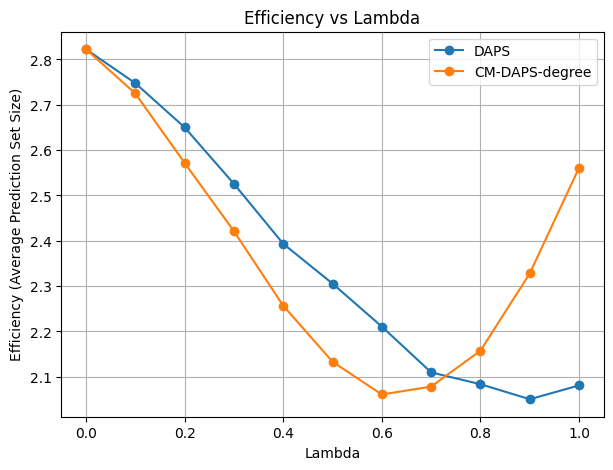

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for method in sweep_df["Method"].unique():
    df_m = sweep_df[sweep_df["Method"] == method]
    plt.plot(
        df_m["Lambda"],
        df_m["Efficiency"],
        marker="o",
        label=method
    )

plt.xlabel("Lambda")
plt.ylabel("Efficiency (Average Prediction Set Size)")
plt.title("Efficiency vs Lambda")
plt.legend()
plt.grid(True)
plt.show()

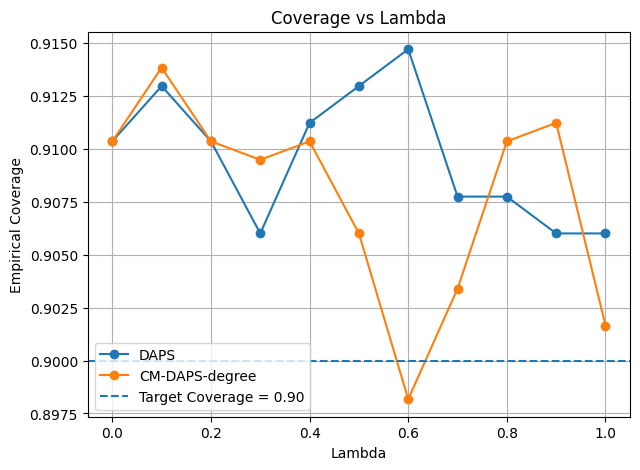

In [131]:
plt.figure(figsize=(7, 5))

for method in sweep_df["Method"].unique():
    df_m = sweep_df[sweep_df["Method"] == method]
    plt.plot(
        df_m["Lambda"],
        df_m["Coverage"],
        marker="o",
        label=method
    )

plt.axhline(
    y=1 - alpha,
    linestyle="--",
    label=f"Target Coverage = {1-alpha:.2f}"
)

plt.xlabel("Lambda")
plt.ylabel("Empirical Coverage")
plt.title("Coverage vs Lambda")
plt.legend()
plt.grid(True)
plt.show()

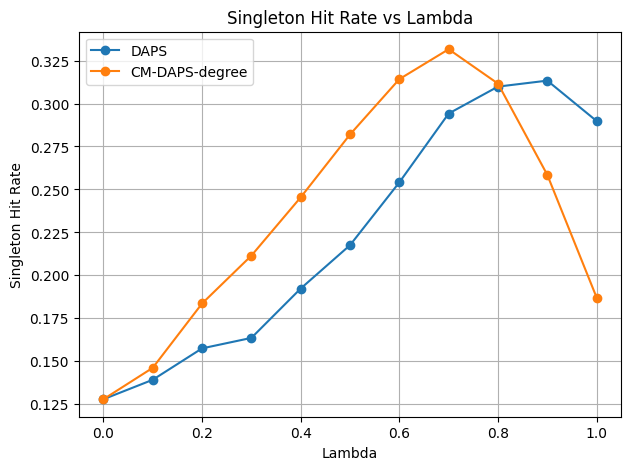

In [132]:
plt.figure(figsize=(7, 5))

for method in sweep_df["Method"].unique():
    df_m = sweep_df[sweep_df["Method"] == method]
    plt.plot(
        df_m["Lambda"],
        df_m["Singleton Hit Rate"],
        marker="o",
        label=method
    )

plt.xlabel("Lambda")
plt.ylabel("Singleton Hit Rate")
plt.title("Singleton Hit Rate vs Lambda")
plt.legend()
plt.grid(True)
plt.show()

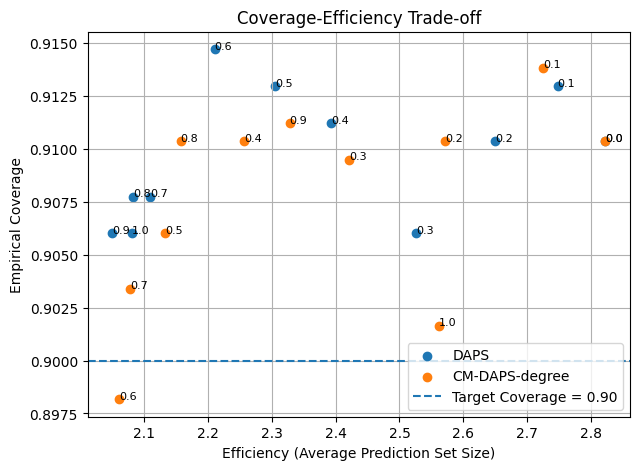

In [133]:
plt.figure(figsize=(7, 5))

for method in sweep_df["Method"].unique():
    df_m = sweep_df[sweep_df["Method"] == method]
    plt.scatter(
        df_m["Efficiency"],
        df_m["Coverage"],
        label=method
    )

    for _, row in df_m.iterrows():
        plt.text(
            row["Efficiency"],
            row["Coverage"],
            f'{row["Lambda"]:.1f}',
            fontsize=8
        )

plt.axhline(
    y=1 - alpha,
    linestyle="--",
    label=f"Target Coverage = {1-alpha:.2f}"
)

plt.xlabel("Efficiency (Average Prediction Set Size)")
plt.ylabel("Empirical Coverage")
plt.title("Coverage-Efficiency Trade-off")
plt.legend()
plt.grid(True)
plt.show()

In [134]:
lambda_values_daps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
lambda_values_cm = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

centrality = degree_centrality(data.edge_index, data.num_nodes).to(device)

best_daps, tune_daps_df = tune_lambda(
    base_scores=aps,
    data=data,
    method="DAPS",
    alpha=alpha,
    lambda_values=lambda_values_daps,
    centrality=None,
    tolerance=0.01
)

best_cm, tune_cm_df = tune_lambda(
    base_scores=aps,
    data=data,
    method="CM-DAPS-degree",
    alpha=alpha,
    lambda_values=lambda_values_cm,
    centrality=centrality,
    tolerance=0.01
)

print("Best DAPS")
display(best_daps)

print("Best CM-DAPS-degree")
display(best_cm)

Best DAPS


,3
Method,DAPS
Lambda,0.3
Gamma,None
Coverage,0.890244
Efficiency,2.381533
Singleton Hit Rate,0.175958
q_hat,0.809994


Best CM-DAPS-degree


,5
Method,CM-DAPS-degree
Lambda,0.5
Gamma,None
Coverage,0.89547
Efficiency,2.099303
Singleton Hit Rate,0.278746
q_hat,0.805549


In [135]:
# ============================================================
# Final evaluation on GCN output: Experiment methods + GSC-PPR
# ============================================================

final_rows = []
tune_tables = {}

methods_to_run = [
    "APS",
    "DAPS",
    "GSC-PPR",
    "DGSC-PPR",
    "FSGSC-PPR",
    "CM-DAPS-degree",
    "PR-CM-DAPS",
    "2-SP DAPS",
    "2-Hop CM-DAPS",
    "2-Hop PR CM-DAPS",
]
A = sparse_adj(data.edge_index, data.num_nodes)

centralities = compute_centralities(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    A=A
)

centrality_degree = torch.tensor(centralities["Degree"], dtype=torch.float32).to(device)
centrality_pagerank = torch.tensor(centralities["PageRank"], dtype=torch.float32).to(device)

for method in methods_to_run:
    print("=" * 60)
    print(f"Running final evaluation: {method}")

    if method == "APS":
        selected_lambda = 0.0
        selected_gamma = 0.0
        selected_centrality = None
        selected_probs = None

    elif method in ["GSC-PPR", "DGSC-PPR", "FSGSC-PPR"]:
        selected_centrality = None
        selected_probs = probs

        best_row, tune_df = tune_lambda(
            base_scores=aps,
            data=data,
            method=method,
            alpha=alpha,
            probs=selected_probs,
            tolerance=0.01,
            seed=42
        )

        selected_lambda = float(best_row["Lambda"])  # beta_base
        selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
        tune_tables[method] = tune_df

    elif method in ["CM-DAPS-degree", "2-Hop CM-DAPS"]:
        selected_centrality = centrality_degree
        selected_probs = None

        best_row, tune_df = tune_lambda(
            base_scores=aps,
            data=data,
            method=method,
            alpha=alpha,
            centrality=selected_centrality,
            tolerance=0.01,
            seed=42
        )

        selected_lambda = float(best_row["Lambda"])
        selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
        tune_tables[method] = tune_df

    elif method in ["PR-CM-DAPS", "2-Hop PR CM-DAPS"]:
        selected_centrality = centrality_pagerank
        selected_probs = None

        best_row, tune_df = tune_lambda(
            base_scores=aps,
            data=data,
            method=method,
            alpha=alpha,
            centrality=selected_centrality,
            tolerance=0.01,
            seed=42
        )

        selected_lambda = float(best_row["Lambda"])
        selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
        tune_tables[method] = tune_df

    else:
        # DAPS, 2-SP DAPS
        selected_centrality = None
        selected_probs = None

        best_row, tune_df = tune_lambda(
            base_scores=aps,
            data=data,
            method=method,
            alpha=alpha,
            tolerance=0.01,
            seed=42
        )

        selected_lambda = float(best_row["Lambda"])
        selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
        tune_tables[method] = tune_df

    final_metrics, q_hat_final, final_scores, final_sets = final_cp_evaluation(
        base_scores=aps,
        data=data,
        method=method,
        selected_lambda=selected_lambda,
        selected_gamma=selected_gamma,
        alpha=alpha,
        centrality=selected_centrality,
        probs=selected_probs
    )

    final_rows.append({
        "Dataset": "AmazonPhoto",
        "Model": "GCN",
        "Method": method,
        "Lambda": selected_lambda,
        "Gamma": selected_gamma,
        "Coverage": final_metrics["coverage"],
        "Efficiency": final_metrics["efficiency"],
        "Singleton Hit Rate": final_metrics["singleton_hit_rate"],
        "q_hat": q_hat_final.item(),
    })

final_df = pd.DataFrame(final_rows)
final_df

[centralities] N=7,650 computing... done (5.8s)
Running final evaluation: APS
Running final evaluation: DAPS
Running final evaluation: GSC-PPR
Running final evaluation: DGSC-PPR
Running final evaluation: FSGSC-PPR
Running final evaluation: CM-DAPS-degree
Running final evaluation: PR-CM-DAPS
Running final evaluation: 2-SP DAPS
Running final evaluation: 2-Hop CM-DAPS
Running final evaluation: 2-Hop PR CM-DAPS


,Dataset,Model,Method,Lambda,Gamma,Coverage,Efficiency,Singleton Hit Rate,q_hat
0,AmazonPhoto,GCN,APS,0.00,0.00,0.910357,2.822454,0.127937,0.839403
1,AmazonPhoto,GCN,DAPS,0.70,0.00,0.907746,2.109661,0.294169,0.813131
2,AmazonPhoto,GCN,GSC-PPR,0.05,0.00,0.913838,1.821584,0.489991,0.822991
3,AmazonPhoto,GCN,DGSC-PPR,0.05,0.25,0.919060,1.989556,0.388164,0.827699
4,AmazonPhoto,GCN,FSGSC-PPR,0.05,2.00,0.912968,1.828547,0.489121,0.826489
5,AmazonPhoto,GCN,CM-DAPS-degree,0.60,0.00,0.898172,2.060923,0.314186,0.816047
6,AmazonPhoto,GCN,PR-CM-DAPS,0.60,0.00,0.893821,2.035683,0.311575,0.812916
7,AmazonPhoto,GCN,2-SP DAPS,0.90,0.70,0.903394,1.778068,0.445605,0.764906
8,AmazonPhoto,GCN,2-Hop CM-DAPS,0.80,0.70,0.899913,1.777198,0.463011,0.797095
9,AmazonPhoto,GCN,2-Hop PR CM-DAPS,0.80,0.80,0.906005,1.879025,0.434291,0.794577


In [136]:
# ============================================================
# Add DC-GSC-PPR(T=3) to final comparison table
# Degree-Calibrated q-hat correction on top of GSC-PPR scores
# ============================================================

DC_T = 3

# ------------------------------------------------------------
# 1. Get tuned GSC-PPR beta from final_df if available
# ------------------------------------------------------------
if "final_df" in globals() and "GSC-PPR" in final_df["Method"].values:
    gsc_row = final_df[final_df["Method"] == "GSC-PPR"].iloc[0]
    gsc_beta = float(gsc_row["Lambda"])
else:
    best_gsc_row, _ = tune_lambda(
        base_scores=aps,
        data=data,
        method="GSC-PPR",
        alpha=alpha,
        probs=probs,
        lambda_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
        tolerance=0.01,
        seed=42
    )
    gsc_beta = float(best_gsc_row["Lambda"])

# ------------------------------------------------------------
# 2. Compute GSC-PPR scores
# ------------------------------------------------------------
gsc_scores_for_dc = compute_method_scores(
    base_scores=aps,
    data=data,
    method="GSC-PPR",
    lam=gsc_beta,
    gamma=0.0,
    probs=probs
).to(device)

# ------------------------------------------------------------
# 3. Degree-calibrated q-hat correction
# ------------------------------------------------------------
A = sparse_adj(data.edge_index, data.num_nodes)

centralities_cache_dc = compute_centralities(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    A=A
)

metrics_dc_gsc, sets_dc_gsc, q_hats_dc_gsc, bounds_dc_gsc, bucket_info_dc_gsc = evaluate_stratified_scores(
    scores=gsc_scores_for_dc,
    labels=data.y,
    data=data,
    cal_mask=data.cal_mask,
    test_mask=data.test_mask,
    alpha=alpha,
    T=DC_T,
    stratify_by="degree",
    centralities_cache=centralities_cache_dc,
)

dc_gsc_row = {
    "Dataset": "AmazonPhoto",
    "Model": "GCN",
    "Method": f"DC-GSC-PPR(T={DC_T})",
    "Lambda": gsc_beta,
    "Gamma": DC_T,
    "Coverage": metrics_dc_gsc["coverage"],
    "Efficiency": metrics_dc_gsc["efficiency"],
    "Singleton Hit Rate": metrics_dc_gsc["singleton_hit_rate"],
    "q_hat": "degree-stratified",
}

# ------------------------------------------------------------
# 4. Append to final_df without overwriting original
# ------------------------------------------------------------
final_df_with_dc = pd.concat(
    [
        final_df,
        pd.DataFrame([dc_gsc_row])
    ],
    ignore_index=True
)

display(final_df_with_dc.round(4))

print("\nDC-GSC-PPR bucket diagnostic table")
display(bucket_info_dc_gsc.round(4))

[centralities] N=7,650 computing... done (8.8s)


,Dataset,Model,Method,Lambda,Gamma,Coverage,Efficiency,Singleton Hit Rate,q_hat
0,AmazonPhoto,GCN,APS,0.00,0.00,0.9104,2.8225,0.1279,0.839403
1,AmazonPhoto,GCN,DAPS,0.70,0.00,0.9077,2.1097,0.2942,0.813131
2,AmazonPhoto,GCN,GSC-PPR,0.05,0.00,0.9138,1.8216,0.4900,0.822991
3,AmazonPhoto,GCN,DGSC-PPR,0.05,0.25,0.9191,1.9896,0.3882,0.827699
4,AmazonPhoto,GCN,FSGSC-PPR,0.05,2.00,0.9130,1.8285,0.4891,0.826489
5,AmazonPhoto,GCN,CM-DAPS-degree,0.60,0.00,0.8982,2.0609,0.3142,0.816047
6,AmazonPhoto,GCN,PR-CM-DAPS,0.60,0.00,0.8938,2.0357,0.3116,0.812916
7,AmazonPhoto,GCN,2-SP DAPS,0.90,0.70,0.9034,1.7781,0.4456,0.764906
8,AmazonPhoto,GCN,2-Hop CM-DAPS,0.80,0.70,0.8999,1.7772,0.4630,0.797095
9,AmazonPhoto,GCN,2-Hop PR CM-DAPS,0.80,0.80,0.9060,1.8790,0.4343,0.794577



DC-GSC-PPR bucket diagnostic table


,Bucket,Range,Cal Count,Test Count,q_hat
0,0,0.0000~0.0084,369,342,0.8639
1,1,0.0084~0.0230,386,428,0.8128
2,2,0.0230~0.3598,392,377,0.8213


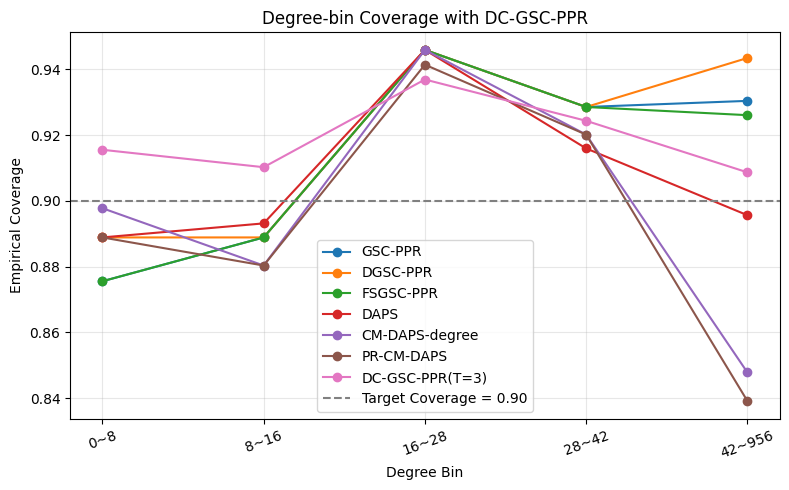


GSC-PPR


,Degree Bin,Coverage,Count
0,0~8,0.8756,225
1,8~16,0.8889,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9304,230



DGSC-PPR


,Degree Bin,Coverage,Count
0,0~8,0.8889,225
1,8~16,0.8889,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9435,230



FSGSC-PPR


...

,Degree Bin,Coverage,Count
0,0~8,0.8978,225
1,8~16,0.8803,234
2,16~28,0.9459,222
3,28~42,0.9202,238
4,42~956,0.8478,230



PR-CM-DAPS


,Degree Bin,Coverage,Count
0,0~8,0.8889,225
1,8~16,0.8803,234
2,16~28,0.9414,222
3,28~42,0.9202,238
4,42~956,0.8391,230



DC-GSC-PPR(T=3)


,Degree Bin,Coverage,Count
0,0~8,0.9156,225
1,8~16,0.9103,234
2,16~28,0.9369,222
3,28~42,0.9244,238
4,42~956,0.9087,230


In [137]:
# ============================================================
# Degree-bin coverage comparison including DC-GSC-PPR
# ============================================================

degree_coverage_results_with_dc = {}

# Existing methods to compare
methods_for_dc_degree = [
    "GSC-PPR",
    "DGSC-PPR",
    "FSGSC-PPR",
    "DAPS",
    "CM-DAPS-degree",
    "PR-CM-DAPS",
]

for method in methods_for_dc_degree:
    if method not in final_df_with_dc["Method"].values:
        continue

    r = final_df_with_dc[final_df_with_dc["Method"] == method].iloc[0]

    selected_lambda = float(r["Lambda"])
    selected_gamma = 0.0 if pd.isna(r["Gamma"]) else float(r["Gamma"])

    if method in ["GSC-PPR", "DGSC-PPR", "FSGSC-PPR"]:
        selected_probs = probs
        selected_centrality = None

    elif method == "CM-DAPS-degree":
        selected_probs = None
        selected_centrality = torch.tensor(
            centralities_cache_dc["Degree"],
            dtype=torch.float32,
            device=device
        )

    elif method == "PR-CM-DAPS":
        selected_probs = None
        selected_centrality = torch.tensor(
            centralities_cache_dc["PageRank"],
            dtype=torch.float32,
            device=device
        )

    else:
        selected_probs = None
        selected_centrality = None

    final_metrics_tmp, q_hat_tmp, scores_tmp, sets_tmp = final_cp_evaluation(
        base_scores=aps,
        data=data,
        method=method,
        selected_lambda=selected_lambda,
        selected_gamma=selected_gamma,
        alpha=alpha,
        centrality=selected_centrality,
        probs=selected_probs
    )

    degree_coverage_results_with_dc[method] = coverage_by_degree(
        prediction_sets=sets_tmp,
        labels=data.y,
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        mask=data.test_mask,
        n_bins=5
    )

# Add DC-GSC-PPR directly from stratified prediction sets
degree_coverage_results_with_dc[f"DC-GSC-PPR(T={DC_T})"] = coverage_by_degree(
    prediction_sets=sets_dc_gsc,
    labels=data.y,
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    mask=data.test_mask,
    n_bins=5
)

plot_coverage_by_degree(
    degree_coverage_results_with_dc,
    alpha=alpha,
    title="Degree-bin Coverage with DC-GSC-PPR"
)

for method, df in degree_coverage_results_with_dc.items():
    print(f"\n{method}")
    display(df.round(4))

[centralities] N=7,650 computing... done (10.7s)
Centrality-Stratified Calibration results


,Method,Centrality,T,Coverage,Efficiency,Singleton Hit Rate
0,APS,-,-,0.9104,2.8225,0.1279
1,DAPS_fixed_lambda_0.5,-,-,0.9130,2.3055,0.2176
2,CM-DAPS-split,degree,2,0.9199,2.8277,0.1245
3,CM-DAPS-split,degree,3,0.9173,2.8085,0.1366
4,CM-DAPS-split,degree,5,0.9208,2.7668,0.1619
5,CM-DAPS-split,pagerank,2,0.9121,2.7502,0.1210
6,CM-DAPS-split,pagerank,3,0.9217,2.9008,0.1062
7,CM-DAPS-split,pagerank,5,0.9104,2.6928,0.1332
8,CM-DAPS-split,clustering,2,0.9208,2.8895,0.1210
9,CM-DAPS-split,clustering,3,0.9138,2.8460,0.1262


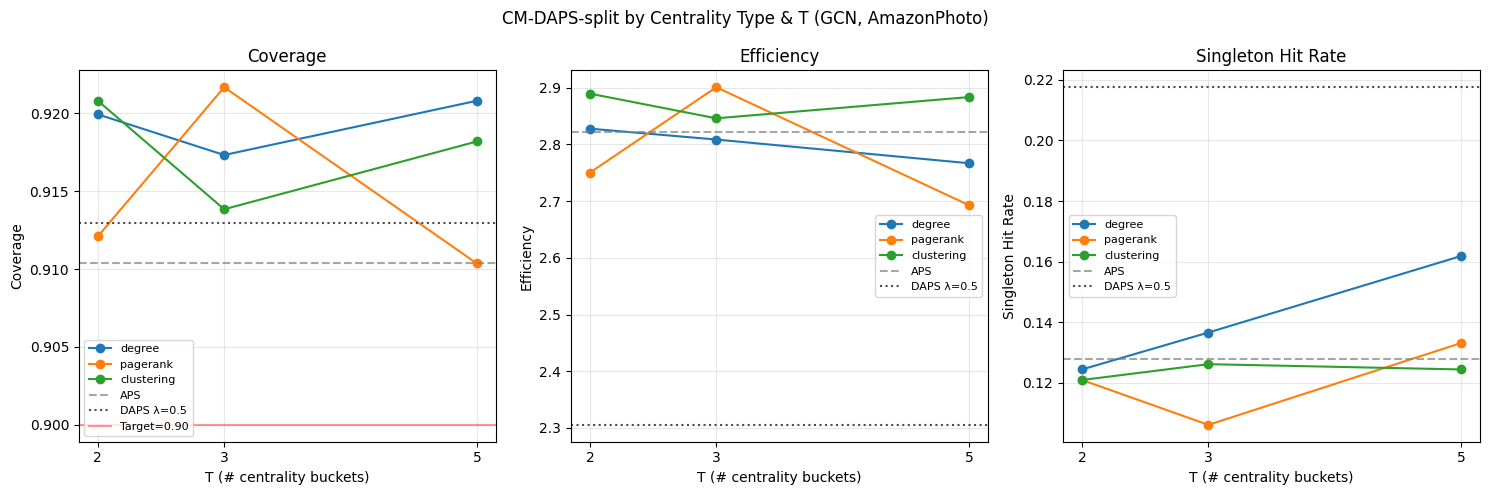

In [138]:
# ============================================================
# Idea 1: Centrality-Stratified Calibration / CM-DAPS-split
# GCN + AmazonPhoto analysis
# ============================================================

T_VALUES = [2, 3, 5]
CENT_TYPES = ["degree", "pagerank", "clustering"]

idea1_rows = []

# Cache centralities once.
A = sparse_adj(data.edge_index, data.num_nodes)
centralities_cache = compute_centralities(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    A=A
)

# ------------------------------------------------------------
# Baseline 1: APS
# ------------------------------------------------------------
q_aps = conformal_quantile(
    scores=aps,
    labels=data.y,
    cal_mask=data.cal_mask,
    alpha=alpha
)

sets_aps = build_prediction_sets(aps, q_aps)

m_aps = evaluate_prediction_sets(
    prediction_sets=sets_aps,
    labels=data.y,
    mask=data.test_mask
)

idea1_rows.append({
    "Method": "APS",
    "Centrality": "-",
    "T": "-",
    "Coverage": m_aps["coverage"],
    "Efficiency": m_aps["efficiency"],
    "Singleton Hit Rate": m_aps["singleton_hit_rate"],
})

# ------------------------------------------------------------
# Baseline 2: DAPS fixed lambda = 0.5
# This reproduces the setting in Graph_ML(추가1차).
# ------------------------------------------------------------
daps_fixed = daps_diffusion(
    scores=aps,
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    lam=0.5
)

q_daps = conformal_quantile(
    scores=daps_fixed,
    labels=data.y,
    cal_mask=data.cal_mask,
    alpha=alpha
)

sets_daps = build_prediction_sets(daps_fixed, q_daps)

m_daps = evaluate_prediction_sets(
    prediction_sets=sets_daps,
    labels=data.y,
    mask=data.test_mask
)

idea1_rows.append({
    "Method": "DAPS_fixed_lambda_0.5",
    "Centrality": "-",
    "T": "-",
    "Coverage": m_daps["coverage"],
    "Efficiency": m_daps["efficiency"],
    "Singleton Hit Rate": m_daps["singleton_hit_rate"],
})

# ------------------------------------------------------------
# Idea 1: centrality-stratified calibration
# ------------------------------------------------------------
for cent_type in CENT_TYPES:
    for T in T_VALUES:
        pred_sets, q_hats = cm_daps_split(
            scores=aps,
            labels=data.y,
            data=data,
            cal_mask=data.cal_mask,
            test_mask=data.test_mask,
            alpha=alpha,
            T=T,
            centrality_type=cent_type,
            centralities_cache=centralities_cache,
        )

        y_test = data.y[data.test_mask]
        n_test = y_test.size(0)

        contains_true = pred_sets[
            torch.arange(n_test, device=pred_sets.device),
            y_test.to(pred_sets.device)
        ]

        set_sizes = pred_sets.float().sum(dim=1)

        cov = contains_true.float().mean().item()
        eff = set_sizes.mean().item()
        singleton = set_sizes == 1
        shr = (singleton & contains_true).float().mean().item()

        idea1_rows.append({
            "Method": "CM-DAPS-split",
            "Centrality": cent_type,
            "T": T,
            "Coverage": cov,
            "Efficiency": eff,
            "Singleton Hit Rate": shr,
        })

idea1_df = pd.DataFrame(idea1_rows)

print("Centrality-Stratified Calibration results")
display(idea1_df.round(4))

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["Coverage", "Efficiency", "Singleton Hit Rate"]

aps_row = idea1_df[idea1_df["Method"] == "APS"].iloc[0]
daps_row = idea1_df[idea1_df["Method"] == "DAPS_fixed_lambda_0.5"].iloc[0]

for ax, metric in zip(axes, metrics):
    for cent_type in CENT_TYPES:
        sub = idea1_df[
            (idea1_df["Method"] == "CM-DAPS-split") &
            (idea1_df["Centrality"] == cent_type)
        ]

        ax.plot(
            sub["T"].astype(int),
            sub[metric],
            marker="o",
            label=cent_type
        )

    ax.axhline(
        y=aps_row[metric],
        linestyle="--",
        color="gray",
        alpha=0.7,
        label="APS"
    )

    ax.axhline(
        y=daps_row[metric],
        linestyle=":",
        color="black",
        alpha=0.7,
        label="DAPS λ=0.5"
    )

    if metric == "Coverage":
        ax.axhline(
            y=1 - alpha,
            linestyle="-",
            color="red",
            alpha=0.4,
            label=f"Target={1-alpha:.2f}"
        )

    ax.set_xlabel("T (# centrality buckets)")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(T_VALUES)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    "CM-DAPS-split by Centrality Type & T (GCN, AmazonPhoto)",
    fontsize=12
)

plt.tight_layout()
plt.savefig(
    "idea1_cm_daps_split.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

In [139]:
# ============================================================
# Combined comparison:
# APS / DAPS / Idea1-best / CM-DAPS-degree / GSC-PPR
# ============================================================

idea1_candidates = idea1_df[idea1_df["Method"] == "CM-DAPS-split"].copy()

idea1_valid = idea1_candidates[
    idea1_candidates["Coverage"] >= 1 - alpha - 0.01
]

if len(idea1_valid) > 0:
    idea1_best = idea1_valid.sort_values("Efficiency").iloc[0]
else:
    idea1_best = idea1_candidates.sort_values("Efficiency").iloc[0]

combined_rows = []

combined_rows.append({
    "Method": "APS",
    "Coverage": aps_row["Coverage"],
    "Efficiency": aps_row["Efficiency"],
    "Singleton Hit Rate": aps_row["Singleton Hit Rate"],
    "Note": "Baseline",
})

combined_rows.append({
    "Method": "DAPS fixed λ=0.5",
    "Coverage": daps_row["Coverage"],
    "Efficiency": daps_row["Efficiency"],
    "Singleton Hit Rate": daps_row["Singleton Hit Rate"],
    "Note": "Graph diffusion baseline",
})

combined_rows.append({
    "Method": f"CM-DAPS-split best ({idea1_best['Centrality']}, T={idea1_best['T']})",
    "Coverage": idea1_best["Coverage"],
    "Efficiency": idea1_best["Efficiency"],
    "Singleton Hit Rate": idea1_best["Singleton Hit Rate"],
    "Note": "Idea 1: calibration split",
})

# Add selected methods from current final_df if available.
for method_name, note in [
    ("CM-DAPS-degree", "Idea 2: centrality-weighted diffusion"),
    ("GSC-PPR", "Proposed / strongest extension"),
    ("DGSC-PPR", "Degree-protected GSC-PPR for low-degree coverage"),
    ("FSGSC-PPR", "Feature-similarity-aware GSC-PPR"),
    ("PR-CM-DAPS", "PageRank-weighted diffusion"),
    ("2-Hop PR CM-DAPS", "2-hop PageRank extension"),
]:
    if "final_df" in globals() and method_name in final_df["Method"].values:
        r = final_df[final_df["Method"] == method_name].iloc[0]

        combined_rows.append({
            "Method": method_name,
            "Coverage": r["Coverage"],
            "Efficiency": r["Efficiency"],
            "Singleton Hit Rate": r["Singleton Hit Rate"],
            "Note": note,
        })

combined_df = pd.DataFrame(combined_rows)

print("Combined comparison including Graph_ML(추가1차) ideas")
display(combined_df.round(4))

combined_df.to_csv(
    "combined_extra1_comparison.csv",
    index=False
)

Combined comparison including Graph_ML(추가1차) ideas


,Method,Coverage,Efficiency,Singleton Hit Rate,Note
0,APS,0.9104,2.8225,0.1279,Baseline
1,DAPS fixed λ=0.5,0.9130,2.3055,0.2176,Graph diffusion baseline
2,"CM-DAPS-split best (pagerank, T=5)",0.9104,2.6928,0.1332,Idea 1: calibration split
3,CM-DAPS-degree,0.8982,2.0609,0.3142,Idea 2: centrality-weighted diffusion
4,GSC-PPR,0.9138,1.8216,0.4900,Proposed / strongest extension
5,DGSC-PPR,0.9191,1.9896,0.3882,Degree-protected GSC-PPR for low-degree coverage
6,FSGSC-PPR,0.9130,1.8285,0.4891,Feature-similarity-aware GSC-PPR
7,PR-CM-DAPS,0.8938,2.0357,0.3116,PageRank-weighted diffusion
8,2-Hop PR CM-DAPS,0.9060,1.8790,0.4343,2-hop PageRank extension


In [140]:
# ============================================================
# Add DC-GSC-PPR(T=3) to combined comparison table
# ============================================================

if "combined_df" in globals():
    dc_combined_row = {
        "Method": f"DC-GSC-PPR(T={DC_T})",
        "Coverage": metrics_dc_gsc["coverage"],
        "Efficiency": metrics_dc_gsc["efficiency"],
        "Singleton Hit Rate": metrics_dc_gsc["singleton_hit_rate"],
        "Note": "Degree-calibrated q-hat correction on GSC-PPR",
    }

    combined_df_with_dc = pd.concat(
        [
            combined_df,
            pd.DataFrame([dc_combined_row])
        ],
        ignore_index=True
    )

    print("Combined comparison with DC-GSC-PPR")
    display(combined_df_with_dc.round(4))

    combined_df_with_dc.to_csv(
        "combined_comparison_with_dc_gsc_ppr.csv",
        index=False
    )
else:
    print("combined_df is not defined yet. Run the combined comparison cell first.")

Combined comparison with DC-GSC-PPR


,Method,Coverage,Efficiency,Singleton Hit Rate,Note
0,APS,0.9104,2.8225,0.1279,Baseline
1,DAPS fixed λ=0.5,0.9130,2.3055,0.2176,Graph diffusion baseline
2,"CM-DAPS-split best (pagerank, T=5)",0.9104,2.6928,0.1332,Idea 1: calibration split
3,CM-DAPS-degree,0.8982,2.0609,0.3142,Idea 2: centrality-weighted diffusion
4,GSC-PPR,0.9138,1.8216,0.4900,Proposed / strongest extension
5,DGSC-PPR,0.9191,1.9896,0.3882,Degree-protected GSC-PPR for low-degree coverage
6,FSGSC-PPR,0.9130,1.8285,0.4891,Feature-similarity-aware GSC-PPR
7,PR-CM-DAPS,0.8938,2.0357,0.3116,PageRank-weighted diffusion
8,2-Hop PR CM-DAPS,0.9060,1.8790,0.4343,2-hop PageRank extension
9,DC-GSC-PPR(T=3),0.9191,1.9321,0.4482,Degree-calibrated q-hat correction on GSC-PPR


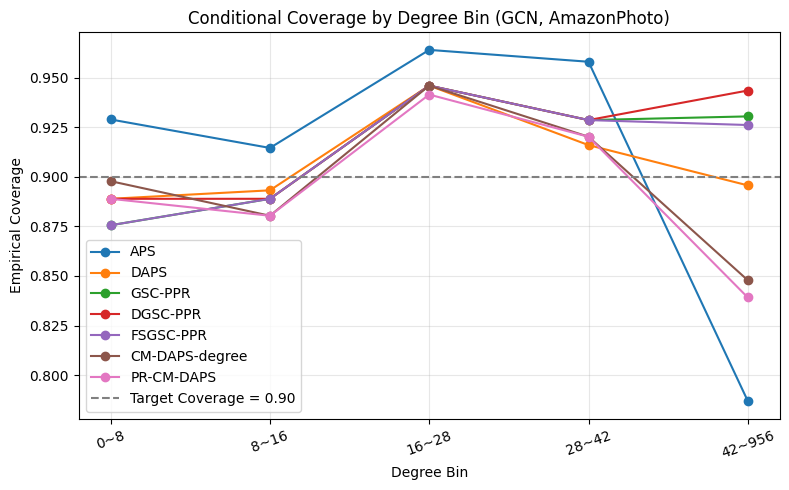


APS


,Degree Bin,Coverage,Count
0,0~8,0.9289,225
1,8~16,0.9145,234
2,16~28,0.9640,222
3,28~42,0.9580,238
4,42~956,0.7870,230



DAPS


,Degree Bin,Coverage,Count
0,0~8,0.8889,225
1,8~16,0.8932,234
2,16~28,0.9459,222
3,28~42,0.9160,238
4,42~956,0.8957,230



GSC-PPR


...

,Degree Bin,Coverage,Count
0,0~8,0.8756,225
1,8~16,0.8889,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9261,230



CM-DAPS-degree


,Degree Bin,Coverage,Count
0,0~8,0.8978,225
1,8~16,0.8803,234
2,16~28,0.9459,222
3,28~42,0.9202,238
4,42~956,0.8478,230



PR-CM-DAPS


,Degree Bin,Coverage,Count
0,0~8,0.8889,225
1,8~16,0.8803,234
2,16~28,0.9414,222
3,28~42,0.9202,238
4,42~956,0.8391,230


In [141]:
# ============================================================
# Degree-bin conditional coverage analysis
# ============================================================

degree_coverage_results = {}

methods_for_degree_coverage = [
    "APS",
    "DAPS",
    "GSC-PPR",
    "DGSC-PPR",
    "FSGSC-PPR",
    "CM-DAPS-degree",
    "PR-CM-DAPS",
]

# Use final_df hyperparameters when available.
for method in methods_for_degree_coverage:
    if method == "APS":
        selected_lambda = 0.0
        selected_gamma = 0.0
        selected_centrality = None
        selected_probs = None

    elif method in ["GSC-PPR", "DGSC-PPR", "FSGSC-PPR"]:
        if method not in final_df["Method"].values:
            continue

        r = final_df[final_df["Method"] == method].iloc[0]
        selected_lambda = float(r["Lambda"])
        selected_gamma = 0.0 if pd.isna(r["Gamma"]) else float(r["Gamma"])
        selected_centrality = None
        selected_probs = probs

    elif method == "CM-DAPS-degree":
        if method not in final_df["Method"].values:
            continue

        r = final_df[final_df["Method"] == method].iloc[0]
        selected_lambda = float(r["Lambda"])
        selected_gamma = 0.0 if pd.isna(r["Gamma"]) else float(r["Gamma"])
        selected_centrality = torch.tensor(
            centralities_cache["Degree"],
            dtype=torch.float32,
            device=device
        )
        selected_probs = None

    elif method == "PR-CM-DAPS":
        if method not in final_df["Method"].values:
            continue

        r = final_df[final_df["Method"] == method].iloc[0]
        selected_lambda = float(r["Lambda"])
        selected_gamma = 0.0 if pd.isna(r["Gamma"]) else float(r["Gamma"])
        selected_centrality = torch.tensor(
            centralities_cache["PageRank"],
            dtype=torch.float32,
            device=device
        )
        selected_probs = None

    elif method == "DAPS":
        if method in final_df["Method"].values:
            r = final_df[final_df["Method"] == method].iloc[0]
            selected_lambda = float(r["Lambda"])
        else:
            selected_lambda = 0.5

        selected_gamma = 0.0
        selected_centrality = None
        selected_probs = None

    else:
        continue

    final_metrics_tmp, q_hat_tmp, scores_tmp, sets_tmp = final_cp_evaluation(
        base_scores=aps,
        data=data,
        method=method,
        selected_lambda=selected_lambda,
        selected_gamma=selected_gamma,
        alpha=alpha,
        centrality=selected_centrality,
        probs=selected_probs
    )

    degree_coverage_results[method] = coverage_by_degree(
        prediction_sets=sets_tmp,
        labels=data.y,
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        mask=data.test_mask,
        n_bins=5
    )

plot_coverage_by_degree(
    degree_coverage_results,
    alpha=alpha,
    title="Conditional Coverage by Degree Bin (GCN, AmazonPhoto)"
)

for method, df in degree_coverage_results.items():
    print(f"\n{method}")
    display(df.round(4))

In [142]:
model_outputs = {}

for model_name in ["MLP", "GCN", "GraphSAGE"]:
    print("=" * 60)
    output = run_model(model_name, epochs = 500)
    model_outputs[model_name] = output

summary_rows = []

for model_name, output in model_outputs.items():
    summary_rows.append({
        "Model": model_name,
        "Best Val Acc": output["best_val_acc"],
        "Test Acc at Best Val": output["test_acc_at_best_val"],
    })

model_summary_df = pd.DataFrame(summary_rows)
model_summary_df

[MLP] Epoch 020 | Loss 1.9038 | Train 0.2536 | Val 0.2589 | Test 0.2428
[MLP] Epoch 040 | Loss 1.8307 | Train 0.3438 | Val 0.3496 | Test 0.3420
[MLP] Epoch 060 | Loss 1.6728 | Train 0.4392 | Val 0.4795 | Test 0.4473
[MLP] Epoch 080 | Loss 1.5192 | Train 0.4814 | Val 0.5039 | Test 0.4787
[MLP] Epoch 100 | Loss 1.3851 | Train 0.5778 | Val 0.6068 | Test 0.5692
[MLP] Epoch 120 | Loss 1.2704 | Train 0.6673 | Val 0.6783 | Test 0.6614
[MLP] Epoch 140 | Loss 1.1746 | Train 0.7180 | Val 0.7132 | Test 0.6971
[MLP] Epoch 160 | Loss 1.1070 | Train 0.7516 | Val 0.7533 | Test 0.7354
[MLP] Epoch 180 | Loss 1.0545 | Train 0.7739 | Val 0.7742 | Test 0.7467
[MLP] Epoch 200 | Loss 0.9945 | Train 0.7788 | Val 0.7759 | Test 0.7493
[MLP] Epoch 220 | Loss 0.9646 | Train 0.7951 | Val 0.7838 | Test 0.7685
[MLP] Epoch 240 | Loss 0.9475 | Train 0.8065 | Val 0.7934 | Test 0.7798
[MLP] Epoch 260 | Loss 0.9122 | Train 0.8144 | Val 0.8003 | Test 0.7868
[MLP] Epoch 280 | Loss 0.8996 | Train 0.8160 | Val 0.8021 | Test

,Model,Best Val Acc,Test Acc at Best Val
0,MLP,0.824760,0.807659
1,GCN,0.870968,0.849434
2,GraphSAGE,0.934612,0.917319


Quick check: GSC-PPR
Quick check: DGSC-PPR
Quick check: FSGSC-PPR


,Method,Lambda,Gamma,Gamma meaning,Coverage,Efficiency,Singleton Hit Rate,q_hat
0,GSC-PPR,0.05,0.00,none,0.9138,1.8216,0.4900,0.8230
1,DGSC-PPR,0.05,0.25,degree_strength,0.9191,1.9896,0.3882,0.8277
2,FSGSC-PPR,0.05,2.00,sim_scale,0.9130,1.8285,0.4891,0.8265


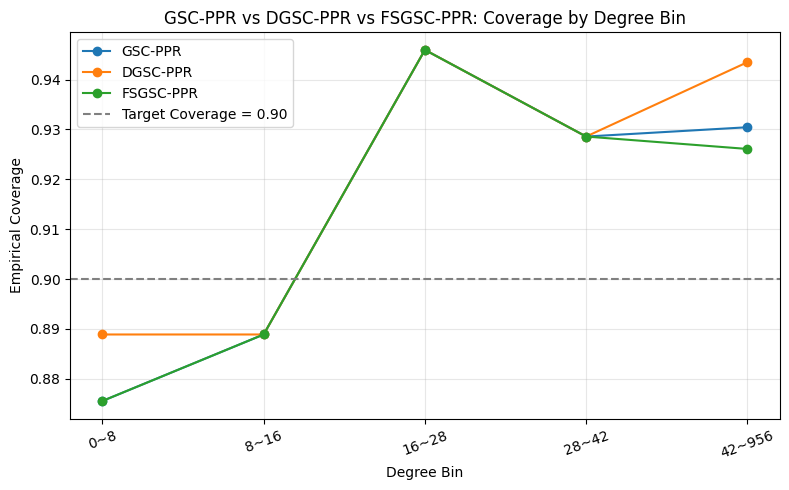


GSC-PPR


,Degree Bin,Coverage,Count
0,0~8,0.8756,225
1,8~16,0.8889,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9304,230



DGSC-PPR


,Degree Bin,Coverage,Count
0,0~8,0.8889,225
1,8~16,0.8889,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9435,230



FSGSC-PPR


,Degree Bin,Coverage,Count
0,0~8,0.8756,225
1,8~16,0.8889,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9261,230



FSGSC-PPR tuning table


,Method,Lambda,Gamma,Coverage,Efficiency,Singleton Hit Rate,q_hat
0,FSGSC-PPR,0.05,0.25,0.8972,1.7544,0.4756,0.8150
1,FSGSC-PPR,0.05,0.50,0.8972,1.7491,0.4774,0.8154
2,FSGSC-PPR,0.05,1.00,0.9007,1.7526,0.4808,0.8174
3,FSGSC-PPR,0.05,2.00,0.8955,1.7439,0.4808,0.8195
4,FSGSC-PPR,0.05,4.00,0.9024,1.7892,0.4599,0.8274
5,FSGSC-PPR,0.10,0.25,0.8972,1.7892,0.4582,0.8164
6,FSGSC-PPR,0.10,0.50,0.8955,1.7892,0.4547,0.8171
7,FSGSC-PPR,0.10,1.00,0.8955,1.7979,0.4495,0.8186
8,FSGSC-PPR,0.10,2.00,0.8920,1.7962,0.4443,0.8205
9,FSGSC-PPR,0.10,4.00,0.8920,1.8101,0.4233,0.8253


In [143]:
# ============================================================
# Quick check:
# GSC-PPR vs Degree-Protected GSC-PPR vs Feature-Similarity GSC-PPR
# ============================================================

quick_rows = []
quick_degree_results = {}
quick_tune_tables = {}

quick_methods = ["GSC-PPR", "DGSC-PPR", "FSGSC-PPR"]

for method in quick_methods:
    print("=" * 60)
    print(f"Quick check: {method}")

    if method == "GSC-PPR":
        best_row, tune_df = tune_lambda(
            base_scores=aps,
            data=data,
            method=method,
            alpha=alpha,
            probs=probs,
            lambda_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
            tolerance=0.01,
            seed=42
        )

    elif method == "DGSC-PPR":
        best_row, tune_df = tune_lambda(
            base_scores=aps,
            data=data,
            method=method,
            alpha=alpha,
            probs=probs,
            lambda_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
            gamma_values=[0.25, 0.5, 0.75, 1.0],
            tolerance=0.01,
            seed=42
        )

    elif method == "FSGSC-PPR":
        best_row, tune_df = tune_lambda(
            base_scores=aps,
            data=data,
            method=method,
            alpha=alpha,
            probs=probs,
            lambda_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
            gamma_values=[0.25, 0.5, 1.0, 2.0, 4.0],
            tolerance=0.01,
            seed=42
        )

    selected_lambda = float(best_row["Lambda"])
    selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])

    final_metrics, q_hat_final, scores_tmp, sets_tmp = final_cp_evaluation(
        base_scores=aps,
        data=data,
        method=method,
        selected_lambda=selected_lambda,
        selected_gamma=selected_gamma,
        alpha=alpha,
        centrality=None,
        probs=probs
    )

    quick_rows.append({
        "Method": method,
        "Lambda": selected_lambda,
        "Gamma": selected_gamma,
        "Gamma meaning": (
            "none" if method == "GSC-PPR"
            else "degree_strength" if method == "DGSC-PPR"
            else "sim_scale"
        ),
        "Coverage": final_metrics["coverage"],
        "Efficiency": final_metrics["efficiency"],
        "Singleton Hit Rate": final_metrics["singleton_hit_rate"],
        "q_hat": q_hat_final.item(),
    })

    quick_degree_results[method] = coverage_by_degree(
        prediction_sets=sets_tmp,
        labels=data.y,
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        mask=data.test_mask,
        n_bins=5
    )

    quick_tune_tables[method] = tune_df

quick_df = pd.DataFrame(quick_rows)

display(quick_df.round(4))

plot_coverage_by_degree(
    quick_degree_results,
    alpha=alpha,
    title="GSC-PPR vs DGSC-PPR vs FSGSC-PPR: Coverage by Degree Bin"
)

for method, df in quick_degree_results.items():
    print(f"\n{method}")
    display(df.round(4))

print("\nFSGSC-PPR tuning table")
display(quick_tune_tables["FSGSC-PPR"].round(4))

[centralities] N=7,650 computing... done (5.7s)
Degree-Calibrated GSC-PPR results


,Method,Stratify,T,Beta,Coverage,Efficiency,Singleton Hit Rate,q_hat/global
0,GSC-PPR,global,-,0.05,0.9138,1.8216,0.4900,0.82299
1,DC-GSC-PPR(T=2),degree,2,0.05,0.9173,1.9513,0.4456,-
2,DC-GSC-PPR(T=3),degree,3,0.05,0.9191,1.9321,0.4482,-
3,DC-GSC-PPR(T=5),degree,5,0.05,0.9182,2.0261,0.4186,-
4,DC-GSC-PPR(T=8),degree,8,0.05,0.9225,2.1053,0.4238,-


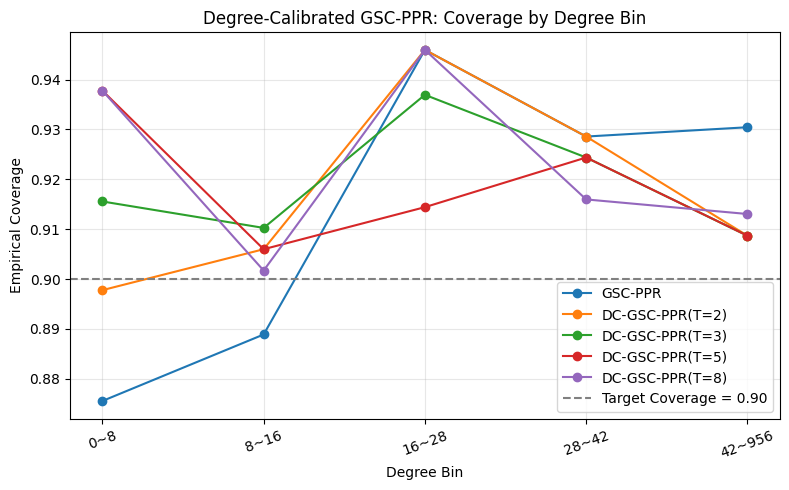


GSC-PPR


,Degree Bin,Coverage,Count
0,0~8,0.8756,225
1,8~16,0.8889,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9304,230



DC-GSC-PPR(T=2)


,Degree Bin,Coverage,Count
0,0~8,0.8978,225
1,8~16,0.9060,234
2,16~28,0.9459,222
3,28~42,0.9286,238
4,42~956,0.9087,230



DC-GSC-PPR(T=3)


...

,Bucket,Range,Cal Count,Test Count,q_hat
0,0,0.0000~0.0084,369,342,0.8639
1,1,0.0084~0.0230,386,428,0.8128
2,2,0.0230~0.3598,392,377,0.8213



DC-GSC-PPR(T=5)


,Bucket,Range,Cal Count,Test Count,q_hat
0,0,0.0000~0.0049,192,193,0.8916
1,1,0.0049~0.0112,251,266,0.8505
2,2,0.0112~0.0202,232,242,0.8056
3,3,0.0202~0.0293,236,214,0.8203
4,4,0.0293~0.3598,236,232,0.8215



DC-GSC-PPR(T=8)


,Bucket,Range,Cal Count,Test Count,q_hat
0,0,0.0000~0.0035,133,138,0.9147
1,1,0.0035~0.0063,136,118,0.8525
2,2,0.0063~0.0103,161,176,0.8505
3,3,0.0103~0.0153,126,142,0.8066
4,4,0.0153~0.0209,142,144,0.8490
5,5,0.0209~0.0265,150,139,0.8203
6,6,0.0265~0.0377,152,150,0.8195
7,7,0.0377~0.3598,147,140,0.8235


In [144]:
# ============================================================
# Quick check:
# GSC-PPR vs Degree-Calibrated GSC-PPR
# ============================================================

dc_rows = []
dc_degree_results = {}
dc_bucket_tables = {}

# ------------------------------------------------------------
# 1. Get tuned GSC-PPR score
# ------------------------------------------------------------
best_gsc_row, tune_gsc_df = tune_lambda(
    base_scores=aps,
    data=data,
    method="GSC-PPR",
    alpha=alpha,
    probs=probs,
    lambda_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    tolerance=0.01,
    seed=42
)

gsc_beta = float(best_gsc_row["Lambda"])

gsc_scores = compute_method_scores(
    base_scores=aps,
    data=data,
    method="GSC-PPR",
    lam=gsc_beta,
    gamma=0.0,
    probs=probs
).to(device)

# ------------------------------------------------------------
# 2. Vanilla GSC-PPR with global q_hat
# ------------------------------------------------------------
q_gsc = conformal_quantile(
    scores=gsc_scores,
    labels=data.y,
    cal_mask=data.cal_mask,
    alpha=alpha
)

sets_gsc = build_prediction_sets(
    scores=gsc_scores,
    q_hat=q_gsc
)

metrics_gsc = evaluate_prediction_sets(
    prediction_sets=sets_gsc,
    labels=data.y,
    mask=data.test_mask
)

dc_rows.append({
    "Method": "GSC-PPR",
    "Stratify": "global",
    "T": "-",
    "Beta": gsc_beta,
    "Coverage": metrics_gsc["coverage"],
    "Efficiency": metrics_gsc["efficiency"],
    "Singleton Hit Rate": metrics_gsc["singleton_hit_rate"],
    "q_hat/global": q_gsc.item(),
})

dc_degree_results["GSC-PPR"] = coverage_by_degree(
    prediction_sets=sets_gsc,
    labels=data.y,
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    mask=data.test_mask,
    n_bins=5
)

# ------------------------------------------------------------
# 3. DC-GSC-PPR: degree-stratified q_hat correction
# ------------------------------------------------------------
DC_T_VALUES = [2, 3, 5, 8]

# Cache centralities once
A = sparse_adj(data.edge_index, data.num_nodes)
centralities_cache_dc = compute_centralities(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    A=A
)

for T in DC_T_VALUES:
    metrics_dc, sets_dc, q_hats_dc, bounds_dc, bucket_info_df = evaluate_stratified_scores(
        scores=gsc_scores,
        labels=data.y,
        data=data,
        cal_mask=data.cal_mask,
        test_mask=data.test_mask,
        alpha=alpha,
        T=T,
        stratify_by="degree",
        centralities_cache=centralities_cache_dc,
    )

    method_name = f"DC-GSC-PPR(T={T})"

    dc_rows.append({
        "Method": method_name,
        "Stratify": "degree",
        "T": T,
        "Beta": gsc_beta,
        "Coverage": metrics_dc["coverage"],
        "Efficiency": metrics_dc["efficiency"],
        "Singleton Hit Rate": metrics_dc["singleton_hit_rate"],
        "q_hat/global": "-",
    })

    dc_degree_results[method_name] = coverage_by_degree(
        prediction_sets=sets_dc,
        labels=data.y,
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        mask=data.test_mask,
        n_bins=5
    )

    dc_bucket_tables[method_name] = bucket_info_df

dc_df = pd.DataFrame(dc_rows)

print("Degree-Calibrated GSC-PPR results")
display(dc_df.round(4))

plot_coverage_by_degree(
    dc_degree_results,
    alpha=alpha,
    title="Degree-Calibrated GSC-PPR: Coverage by Degree Bin"
)

for method, df in dc_degree_results.items():
    print(f"\n{method}")
    display(df.round(4))

print("\nBucket diagnostic tables")
for method, df in dc_bucket_tables.items():
    print(f"\n{method}")
    display(df.round(4))

In [145]:
# ============================================================
# All-model evaluation: MLP / GCN / GraphSAGE × all methods + GSC-PPR
# ============================================================

all_model_rows = []
all_model_tune_tables = {}

methods_to_run = [
    "APS",
    "DAPS",
    "GSC-PPR",
    "DGSC-PPR",
    "FSGSC-PPR",
    "CM-DAPS-degree",
    "PR-CM-DAPS",
    "2-SP DAPS",
    "2-Hop CM-DAPS",
    "2-Hop PR CM-DAPS",
]

A = sparse_adj(data.edge_index, data.num_nodes)

centralities = compute_centralities(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    A=A
)

centrality_degree = torch.tensor(centralities["Degree"], dtype=torch.float32).to(device)
centrality_pagerank = torch.tensor(centralities["PageRank"], dtype=torch.float32).to(device)

for model_name, output in model_outputs.items():
    print("=" * 70)
    print(f"Extended CP evaluation for model: {model_name}")

    probs_model = output["probs"]
    aps_model = aps_scores(probs_model)

    for method in methods_to_run:
        print("-" * 60)
        print(f"Method: {method}")

        if method == "APS":
            selected_lambda = 0.0
            selected_gamma = 0.0
            selected_centrality = None
            selected_probs = None

        elif method in ["GSC-PPR", "DGSC-PPR", "FSGSC-PPR"]:
            selected_centrality = None
            selected_probs = probs_model

            best_row, tune_df = tune_lambda(
                base_scores=aps_model,
                data=data,
                method=method,
                alpha=alpha,
                probs=selected_probs,
                tolerance=0.01,
                seed=42
            )

            selected_lambda = float(best_row["Lambda"])
            selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
            all_model_tune_tables[(model_name, method)] = tune_df

        elif method in ["CM-DAPS-degree", "2-Hop CM-DAPS"]:
            selected_centrality = centrality_degree
            selected_probs = None

            best_row, tune_df = tune_lambda(
                base_scores=aps_model,
                data=data,
                method=method,
                alpha=alpha,
                centrality=selected_centrality,
                tolerance=0.01,
                seed=42
            )

            selected_lambda = float(best_row["Lambda"])
            selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
            all_model_tune_tables[(model_name, method)] = tune_df

        elif method in ["PR-CM-DAPS", "2-Hop PR CM-DAPS"]:
            selected_centrality = centrality_pagerank
            selected_probs = None

            best_row, tune_df = tune_lambda(
                base_scores=aps_model,
                data=data,
                method=method,
                alpha=alpha,
                centrality=selected_centrality,
                tolerance=0.01,
                seed=42
            )

            selected_lambda = float(best_row["Lambda"])
            selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
            all_model_tune_tables[(model_name, method)] = tune_df

        else:
            # DAPS, 2-SP DAPS
            selected_centrality = None
            selected_probs = None

            best_row, tune_df = tune_lambda(
                base_scores=aps_model,
                data=data,
                method=method,
                alpha=alpha,
                tolerance=0.01,
                seed=42
            )

            selected_lambda = float(best_row["Lambda"])
            selected_gamma = 0.0 if pd.isna(best_row["Gamma"]) else float(best_row["Gamma"])
            all_model_tune_tables[(model_name, method)] = tune_df

        final_metrics, q_hat_final, final_scores, final_sets = final_cp_evaluation(
            base_scores=aps_model,
            data=data,
            method=method,
            selected_lambda=selected_lambda,
            selected_gamma=selected_gamma,
            alpha=alpha,
            centrality=selected_centrality,
            probs=selected_probs
        )

        all_model_rows.append({
            "Dataset": "AmazonPhoto",
            "Model": model_name,
            "Method": method,
            "Lambda": selected_lambda,
            "Gamma": selected_gamma,
            "Coverage": final_metrics["coverage"],
            "Efficiency": final_metrics["efficiency"],
            "Singleton Hit Rate": final_metrics["singleton_hit_rate"],
            "Test Acc": output["test_acc_at_best_val"],
            "q_hat": q_hat_final.item(),
        })

all_model_df = pd.DataFrame(all_model_rows)
all_model_df

[centralities] N=7,650 computing... done (4.7s)
Extended CP evaluation for model: MLP
------------------------------------------------------------
Method: APS
------------------------------------------------------------
Method: DAPS
------------------------------------------------------------
Method: GSC-PPR
------------------------------------------------------------
Method: DGSC-PPR
------------------------------------------------------------
Method: FSGSC-PPR
------------------------------------------------------------
Method: CM-DAPS-degree
------------------------------------------------------------
Method: PR-CM-DAPS
------------------------------------------------------------
Method: 2-SP DAPS
------------------------------------------------------------
Method: 2-Hop CM-DAPS
------------------------------------------------------------
Method: 2-Hop PR CM-DAPS
Extended CP evaluation for model: GCN
------------------------------------------------------------
Method: APS
----------

,Dataset,Model,Method,Lambda,Gamma,Coverage,Efficiency,Singleton Hit Rate,Test Acc,q_hat
0,AmazonPhoto,MLP,APS,0.00,0.00,0.906876,3.215840,0.112272,0.807659,0.866501
1,AmazonPhoto,MLP,DAPS,0.70,0.00,0.902524,2.086162,0.267189,0.807659,0.746975
2,AmazonPhoto,MLP,GSC-PPR,0.05,0.00,0.895561,2.107920,0.265448,0.807659,0.797790
3,AmazonPhoto,MLP,DGSC-PPR,0.05,0.25,0.910357,2.211488,0.256745,0.807659,0.806476
4,AmazonPhoto,MLP,FSGSC-PPR,0.05,0.25,0.892950,2.108790,0.261967,0.807659,0.796223
5,AmazonPhoto,MLP,CM-DAPS-degree,0.80,0.00,0.899913,2.302002,0.170583,0.807659,0.715240
6,AmazonPhoto,MLP,PR-CM-DAPS,0.80,0.00,0.906876,2.323760,0.168842,0.807659,0.718362
7,AmazonPhoto,MLP,2-SP DAPS,0.90,0.60,0.901654,1.816362,0.364665,0.807659,0.738714
8,AmazonPhoto,MLP,2-Hop CM-DAPS,0.90,0.40,0.896432,2.071366,0.253264,0.807659,0.701177
9,AmazonPhoto,MLP,2-Hop PR CM-DAPS,0.80,0.40,0.906876,2.089643,0.249782,0.807659,0.713662


In [146]:
# ============================================================
# Add DC-GSC-PPR(T=3) to all_model_df
# AmazonPhoto: MLP / GCN / GraphSAGE
# ============================================================

DC_T = 3

dc_all_model_rows = []

A = sparse_adj(data.edge_index, data.num_nodes)
centralities_cache_all_dc = compute_centralities(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    A=A
)

for model_name, output in model_outputs.items():
    print("=" * 70)
    print(f"DC-GSC-PPR evaluation for model: {model_name}")

    probs_model = output["probs"]
    aps_model = aps_scores(probs_model)

    # Use GSC-PPR beta selected in all_model_df if available
    if (
        "all_model_df" in globals()
        and len(all_model_df[
            (all_model_df["Model"] == model_name) &
            (all_model_df["Method"] == "GSC-PPR")
        ]) > 0
    ):
        gsc_row_model = all_model_df[
            (all_model_df["Model"] == model_name) &
            (all_model_df["Method"] == "GSC-PPR")
        ].iloc[0]
        gsc_beta_model = float(gsc_row_model["Lambda"])

    else:
        best_gsc_row_model, _ = tune_lambda(
            base_scores=aps_model,
            data=data,
            method="GSC-PPR",
            alpha=alpha,
            probs=probs_model,
            lambda_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
            tolerance=0.01,
            seed=42
        )
        gsc_beta_model = float(best_gsc_row_model["Lambda"])

    gsc_scores_model = compute_method_scores(
        base_scores=aps_model,
        data=data,
        method="GSC-PPR",
        lam=gsc_beta_model,
        gamma=0.0,
        probs=probs_model
    ).to(device)

    metrics_dc_model, sets_dc_model, q_hats_dc_model, bounds_dc_model, bucket_info_dc_model = evaluate_stratified_scores(
        scores=gsc_scores_model,
        labels=data.y,
        data=data,
        cal_mask=data.cal_mask,
        test_mask=data.test_mask,
        alpha=alpha,
        T=DC_T,
        stratify_by="degree",
        centralities_cache=centralities_cache_all_dc,
    )

    dc_all_model_rows.append({
        "Dataset": "AmazonPhoto",
        "Model": model_name,
        "Method": f"DC-GSC-PPR(T={DC_T})",
        "Lambda": gsc_beta_model,
        "Gamma": DC_T,
        "Coverage": metrics_dc_model["coverage"],
        "Efficiency": metrics_dc_model["efficiency"],
        "Singleton Hit Rate": metrics_dc_model["singleton_hit_rate"],
        "Test Acc": output["test_acc_at_best_val"],
        "q_hat": "degree-stratified",
    })

dc_all_model_df = pd.DataFrame(dc_all_model_rows)

all_model_df_with_dc = pd.concat(
    [
        all_model_df,
        dc_all_model_df
    ],
    ignore_index=True
)

display(all_model_df_with_dc.round(4))

all_model_df_with_dc.to_csv(
    "all_model_results_with_dc_gsc_ppr.csv",
    index=False
)

[centralities] N=7,650 computing... done (5.0s)
DC-GSC-PPR evaluation for model: MLP
DC-GSC-PPR evaluation for model: GCN
DC-GSC-PPR evaluation for model: GraphSAGE


,Dataset,Model,Method,Lambda,Gamma,Coverage,Efficiency,Singleton Hit Rate,Test Acc,q_hat
0,AmazonPhoto,MLP,APS,0.00,0.00,0.9069,3.2158,0.1123,0.8077,0.866501
1,AmazonPhoto,MLP,DAPS,0.70,0.00,0.9025,2.0862,0.2672,0.8077,0.746975
2,AmazonPhoto,MLP,GSC-PPR,0.05,0.00,0.8956,2.1079,0.2654,0.8077,0.79779
3,AmazonPhoto,MLP,DGSC-PPR,0.05,0.25,0.9104,2.2115,0.2567,0.8077,0.806476
4,AmazonPhoto,MLP,FSGSC-PPR,0.05,0.25,0.8930,2.1088,0.2620,0.8077,0.796223
5,AmazonPhoto,MLP,CM-DAPS-degree,0.80,0.00,0.8999,2.3020,0.1706,0.8077,0.71524
6,AmazonPhoto,MLP,PR-CM-DAPS,0.80,0.00,0.9069,2.3238,0.1688,0.8077,0.718362
7,AmazonPhoto,MLP,2-SP DAPS,0.90,0.60,0.9017,1.8164,0.3647,0.8077,0.738714
8,AmazonPhoto,MLP,2-Hop CM-DAPS,0.90,0.40,0.8964,2.0714,0.2533,0.8077,0.701177
9,AmazonPhoto,MLP,2-Hop PR CM-DAPS,0.80,0.40,0.9069,2.0896,0.2498,0.8077,0.713662


In [168]:
# ============================================================
# Main story summary: GSC-PPR vs DC-GSC-PPR
# ============================================================

main_story_methods = [
    "APS",
    "DAPS",
    "GSC-PPR",
    f"DC-GSC-PPR(T={DC_T})",
]

main_story_df = final_df_with_dc[
    final_df_with_dc["Method"].isin(main_story_methods)
].copy()

method_order = {
    "APS": 0,
    "DAPS": 1,
    "GSC-PPR": 2,
    f"DC-GSC-PPR(T={DC_T})": 3,
}

main_story_df["order"] = main_story_df["Method"].map(method_order)
main_story_df = main_story_df.sort_values("order").drop(columns=["order"])

display(main_story_df.round(4))

main_story_df.to_csv(
    "main_story_summary_gsc_dc.csv",
    index=False
)

,Dataset,Model,Method,Lambda,Gamma,Coverage,Efficiency,Singleton Hit Rate,q_hat
0,AmazonPhoto,GCN,APS,0.00,0.0,0.9104,2.8225,0.1279,0.839403
1,AmazonPhoto,GCN,DAPS,0.70,0.0,0.9077,2.1097,0.2942,0.813131
2,AmazonPhoto,GCN,GSC-PPR,0.05,0.0,0.9138,1.8216,0.4900,0.822991
10,AmazonPhoto,GCN,DC-GSC-PPR(T=3),0.05,3.0,0.9191,1.9321,0.4482,degree-stratified


In [148]:
# ============================================================
# Experiment 1: Longer Training / Higher Base Accuracy Test
# Dataset: AmazonPhoto
# Model: GCN
# Methods: APS / DAPS / GSC-PPR
# ============================================================

EPOCH_SWEEP = [100, 300, 500, 1000]

epoch_sweep_rows = []
epoch_sweep_tune_tables = {}

methods_epoch_sweep = [
    "APS",
    "DAPS",
    "GSC-PPR",
]

# 현재 전역 dataset/data 보존
_original_dataset = globals().get("dataset", None)
_original_data = globals().get("data", None)

# AmazonPhoto를 고정해서 다시 로드
dataset_epoch = Amazon(
    root="./data/Amazon",
    name="Photo",
    transform=NormalizeFeatures()
)

data_epoch = dataset_epoch[0]
data_epoch = random_split_with_tune_and_calibration(
    data_epoch,
    seed=42
)
data_epoch = data_epoch.to(device)

# run_model은 전역 dataset/data를 참조하므로 임시 교체
globals()["dataset"] = dataset_epoch
globals()["data"] = data_epoch

for num_epochs in EPOCH_SWEEP:
    print("=" * 70)
    print(f"Training GCN for {num_epochs} epochs")
    print("=" * 70)

    output_epoch = run_model(
        model_name="GCN",
        epochs=num_epochs
    )

    probs_epoch = output_epoch["probs"]
    aps_epoch = aps_scores(probs_epoch)

    print(
        f"[Epoch {num_epochs}] "
        f"Best Val Acc = {output_epoch['best_val_acc']:.4f}, "
        f"Test Acc at Best Val = {output_epoch['test_acc_at_best_val']:.4f}"
    )

    for method in methods_epoch_sweep:
        print(f"  Running CP method: {method}")

        if method == "APS":
            selected_lambda = 0.0
            selected_gamma = 0.0
            selected_probs = None

        elif method == "DAPS":
            best_row, tune_df = tune_lambda(
                base_scores=aps_epoch,
                data=data_epoch,
                method="DAPS",
                alpha=alpha,
                lambda_values=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
                tolerance=0.01,
                seed=42
            )

            selected_lambda = float(best_row["Lambda"])
            selected_gamma = 0.0
            selected_probs = None

            epoch_sweep_tune_tables[(num_epochs, method)] = tune_df

        elif method == "GSC-PPR":
            best_row, tune_df = tune_lambda(
                base_scores=aps_epoch,
                data=data_epoch,
                method="GSC-PPR",
                alpha=alpha,
                lambda_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
                probs=probs_epoch,
                tolerance=0.01,
                seed=42
            )

            selected_lambda = float(best_row["Lambda"])  # beta_base
            selected_gamma = 0.0
            selected_probs = probs_epoch

            epoch_sweep_tune_tables[(num_epochs, method)] = tune_df

        else:
            raise ValueError(f"Unknown method: {method}")

        final_metrics, q_hat_final, final_scores, final_sets = final_cp_evaluation(
            base_scores=aps_epoch,
            data=data_epoch,
            method=method,
            selected_lambda=selected_lambda,
            selected_gamma=selected_gamma,
            alpha=alpha,
            centrality=None,
            probs=selected_probs
        )

        epoch_sweep_rows.append({
            "Dataset": "AmazonPhoto",
            "Model": "GCN",
            "Epochs": num_epochs,
            "Method": method,
            "Lambda_or_Beta": selected_lambda,
            "Best Val Acc": output_epoch["best_val_acc"],
            "Test Acc": output_epoch["test_acc_at_best_val"],
            "Coverage": final_metrics["coverage"],
            "Efficiency": final_metrics["efficiency"],
            "Singleton Hit Rate": final_metrics["singleton_hit_rate"],
            "q_hat": q_hat_final.item(),
        })

# 전역 dataset/data 복원
if _original_dataset is not None:
    globals()["dataset"] = _original_dataset

if _original_data is not None:
    globals()["data"] = _original_data

epoch_sweep_df = pd.DataFrame(epoch_sweep_rows)

epoch_sweep_df.to_csv(
    "epoch_sweep_gcn_amazonphoto.csv",
    index=False
)

epoch_sweep_df

Training GCN for 100 epochs
[GCN] Epoch 020 | Loss 1.9359 | Train 0.2536 | Val 0.2589 | Test 0.2428
[GCN] Epoch 040 | Loss 1.8966 | Train 0.3444 | Val 0.3758 | Test 0.3464
[GCN] Epoch 060 | Loss 1.8219 | Train 0.4216 | Val 0.4595 | Test 0.4195
[GCN] Epoch 080 | Loss 1.7098 | Train 0.4333 | Val 0.4647 | Test 0.4291
[GCN] Epoch 100 | Loss 1.5620 | Train 0.4562 | Val 0.4900 | Test 0.4534

[GCN] Best Val Acc: 0.4917, Test Acc: 0.4543
[Epoch 100] Best Val Acc = 0.4917, Test Acc at Best Val = 0.4543
  Running CP method: APS
  Running CP method: DAPS
  Running CP method: GSC-PPR
Training GCN for 300 epochs
[GCN] Epoch 020 | Loss 1.9359 | Train 0.2536 | Val 0.2589 | Test 0.2428
[GCN] Epoch 040 | Loss 1.8966 | Train 0.3444 | Val 0.3758 | Test 0.3464
[GCN] Epoch 060 | Loss 1.8219 | Train 0.4216 | Val 0.4595 | Test 0.4195
[GCN] Epoch 080 | Loss 1.7098 | Train 0.4333 | Val 0.4647 | Test 0.4291
[GCN] Epoch 100 | Loss 1.5620 | Train 0.4562 | Val 0.4900 | Test 0.4534
[GCN] Epoch 120 | Loss 1.4211 | T

,Dataset,Model,Epochs,Method,Lambda_or_Beta,Best Val Acc,Test Acc,Coverage,Efficiency,Singleton Hit Rate,q_hat
0,AmazonPhoto,GCN,100,APS,0.00,0.491718,0.454308,0.912968,5.402959,0.000000,0.889839
1,AmazonPhoto,GCN,100,DAPS,0.00,0.491718,0.454308,0.912968,5.402959,0.000000,0.889839
2,AmazonPhoto,GCN,100,GSC-PPR,0.40,0.491718,0.454308,0.912968,5.860748,0.000000,0.918586
3,AmazonPhoto,GCN,300,APS,0.00,0.844813,0.832028,0.922541,2.976501,0.103568,0.826520
4,AmazonPhoto,GCN,300,DAPS,0.30,0.844813,0.832028,0.916449,2.657093,0.120975,0.814011
5,AmazonPhoto,GCN,300,GSC-PPR,0.05,0.844813,0.832028,0.914708,1.881636,0.429069,0.797972
6,AmazonPhoto,GCN,500,APS,0.00,0.870968,0.849434,0.910357,2.821584,0.128808,0.839294
7,AmazonPhoto,GCN,500,DAPS,0.70,0.870968,0.849434,0.907746,2.109661,0.293299,0.813307
8,AmazonPhoto,GCN,500,GSC-PPR,0.05,0.870968,0.849434,0.913838,1.824195,0.489991,0.822906
9,AmazonPhoto,GCN,1000,APS,0.00,0.870968,0.849434,0.918190,2.850305,0.138381,0.842955


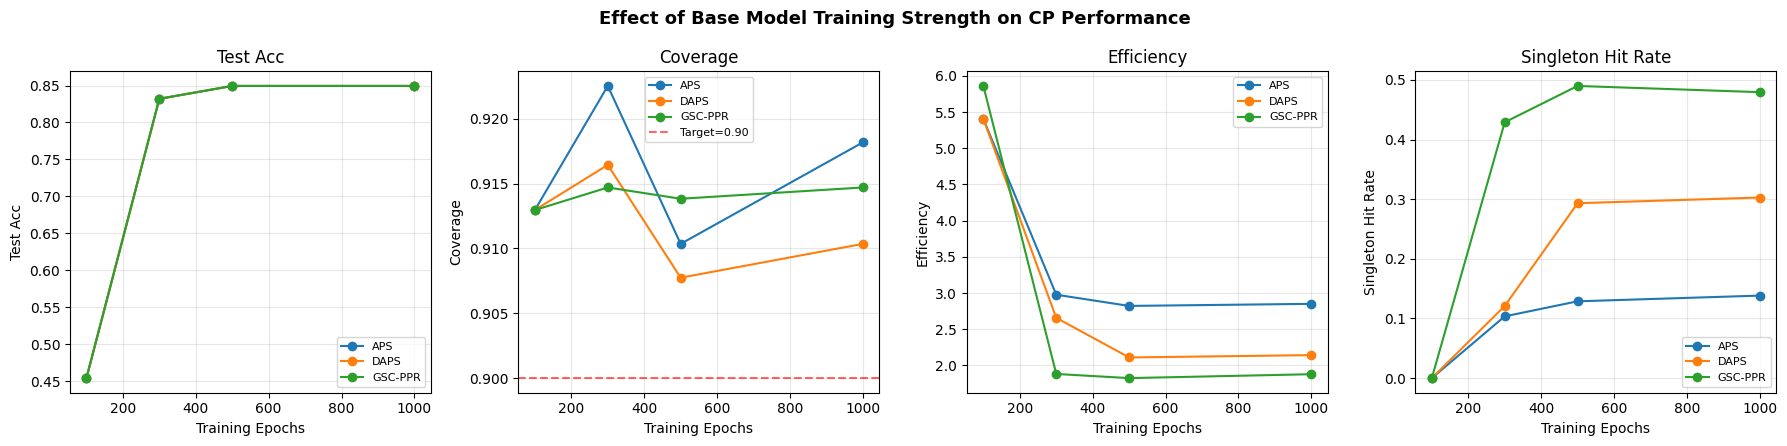

In [149]:
# ============================================================
# Plot: Effect of Base Model Training Epochs
# ============================================================

metrics_to_plot = [
    "Test Acc",
    "Coverage",
    "Efficiency",
    "Singleton Hit Rate",
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4.5)
)

for ax, metric in zip(axes, metrics_to_plot):
    for method in methods_epoch_sweep:
        sub = epoch_sweep_df[
            epoch_sweep_df["Method"] == method
        ].sort_values("Epochs")

        ax.plot(
            sub["Epochs"],
            sub[metric],
            marker="o",
            label=method
        )

    if metric == "Coverage":
        ax.axhline(
            y=1 - alpha,
            linestyle="--",
            color="red",
            alpha=0.6,
            label=f"Target={1-alpha:.2f}"
        )

    ax.set_xlabel("Training Epochs")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(
    "Effect of Base Model Training Strength on CP Performance",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "epoch_sweep_gcn_amazonphoto.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [150]:
# ============================================================
# Epoch sweep summary: GSC-PPR improvement over APS/DAPS
# ============================================================

pivot_eff_epoch = epoch_sweep_df.pivot_table(
    index="Epochs",
    columns="Method",
    values="Efficiency"
)

pivot_shr_epoch = epoch_sweep_df.pivot_table(
    index="Epochs",
    columns="Method",
    values="Singleton Hit Rate"
)

pivot_cov_epoch = epoch_sweep_df.pivot_table(
    index="Epochs",
    columns="Method",
    values="Coverage"
)

print("Efficiency: lower is better")
display(pivot_eff_epoch.round(4))

print("Singleton Hit Rate: higher is better")
display(pivot_shr_epoch.round(4))

print("Coverage: target is 0.9")
display(pivot_cov_epoch.round(4))

epoch_improvement_rows = []

for ep in EPOCH_SWEEP:
    row_eff = pivot_eff_epoch.loc[ep]
    row_shr = pivot_shr_epoch.loc[ep]

    epoch_improvement_rows.append({
        "Epochs": ep,
        "GSC Eff - APS Eff": row_eff["GSC-PPR"] - row_eff["APS"],
        "GSC Eff - DAPS Eff": row_eff["GSC-PPR"] - row_eff["DAPS"],
        "GSC SHR - APS SHR": row_shr["GSC-PPR"] - row_shr["APS"],
        "GSC SHR - DAPS SHR": row_shr["GSC-PPR"] - row_shr["DAPS"],
    })

epoch_improvement_df = pd.DataFrame(epoch_improvement_rows)

print("GSC-PPR improvement summary")
display(epoch_improvement_df.round(4))

Efficiency: lower is better


Method,APS,DAPS,GSC-PPR
Epochs,,,
100,5.4030,5.4030,5.8607
300,2.9765,2.6571,1.8816
500,2.8216,2.1097,1.8242
1000,2.8503,2.1419,1.8782


Singleton Hit Rate: higher is better


Method,APS,DAPS,GSC-PPR
Epochs,,,
100,0.0000,0.0000,0.0000
300,0.1036,0.1210,0.4291
500,0.1288,0.2933,0.4900
1000,0.1384,0.3029,0.4795


Coverage: target is 0.9


Method,APS,DAPS,GSC-PPR
Epochs,,,
100,0.9130,0.9130,0.9130
300,0.9225,0.9164,0.9147
500,0.9104,0.9077,0.9138
1000,0.9182,0.9104,0.9147


GSC-PPR improvement summary


,Epochs,GSC Eff - APS Eff,GSC Eff - DAPS Eff,GSC SHR - APS SHR,GSC SHR - DAPS SHR
0,100,0.4578,0.4578,0.0000,0.0000
1,300,-1.0949,-0.7755,0.3255,0.3081
2,500,-0.9974,-0.2855,0.3612,0.1967
3,1000,-0.9721,-0.2637,0.3412,0.1767


In [151]:
# ============================================================
# Multi-seed stability experiment
# Based on Graph_ML(추가1차), extended with GSC-PPR
# ============================================================

SEEDS = [42, 123, 456, 789, 1024]

MULTI_SEED_MODEL_NAME = "GCN"
MULTI_SEED_ALPHA = 0.1

LAMBDA_DAPS = 0.5
LAMBDA_CM = 0.5
BETA_GSC = 0.1

INCLUDE_GSC_IN_MULTI_SEED = True

multi_seed_rows = []

dataset_ms = Amazon(
    root="./data/Amazon",
    name="Photo",
    transform=NormalizeFeatures()
)

for seed in SEEDS:
    print(f"\nSeed {seed}")

    set_seed(seed)

    d_s = dataset_ms[0].clone()
    d_s = random_split_with_tune_and_calibration(
        d_s,
        seed=seed
    ).to(device)

    model_s = GCN(
        dataset_ms.num_features,
        64,
        dataset_ms.num_classes
    ).to(device)

    opt_s = torch.optim.Adam(
        model_s.parameters(),
        lr=0.01,
        weight_decay=5e-4
    )

    for epoch in range(1, 301):
        model_s.train()
        opt_s.zero_grad()

        out = model_s(d_s.x, d_s.edge_index)
        loss = F.cross_entropy(
            out[d_s.train_mask],
            d_s.y[d_s.train_mask]
        )

        loss.backward()
        opt_s.step()

        if epoch % 100 == 0:
            with torch.no_grad():
                pred = out.argmax(dim=1)
                test_acc = (
                    pred[d_s.test_mask] == d_s.y[d_s.test_mask]
                ).float().mean().item()

            print(
                f"  epoch {epoch:03d} | "
                f"loss {loss.item():.4f} | "
                f"test acc {test_acc:.4f}"
            )

    logits_s, probs_s = get_logits_and_probs(model_s, d_s)

    aps_s = aps_scores(probs_s)

    cent_s = degree_centrality(
        d_s.edge_index,
        d_s.num_nodes
    ).to(device)

    methods_seed = [
        "APS",
        "DAPS",
        "CM-DAPS-degree",
    ]

    if INCLUDE_GSC_IN_MULTI_SEED:
        methods_seed.append("GSC-PPR")

    for method in methods_seed:
        if method == "APS":
            scores_s = aps_s
            lam_value = 0.0

        elif method == "DAPS":
            scores_s = daps_diffusion(
                scores=aps_s,
                edge_index=d_s.edge_index,
                num_nodes=d_s.num_nodes,
                lam=LAMBDA_DAPS
            )
            lam_value = LAMBDA_DAPS

        elif method == "CM-DAPS-degree":
            scores_s = centrality_weighted_daps(
                scores=aps_s,
                edge_index=d_s.edge_index,
                num_nodes=d_s.num_nodes,
                centrality=cent_s,
                lam=LAMBDA_CM
            )
            lam_value = LAMBDA_CM

        elif method == "GSC-PPR":
            scores_s = gsc_ppr(
                scores=aps_s,
                probs=probs_s,
                edge_index=d_s.edge_index,
                num_nodes=d_s.num_nodes,
                beta_base=BETA_GSC
            )
            lam_value = BETA_GSC

        else:
            raise ValueError(f"Unknown method: {method}")

        q_s = conformal_quantile(
            scores=scores_s,
            labels=d_s.y,
            cal_mask=d_s.cal_mask,
            alpha=MULTI_SEED_ALPHA
        )

        pred_sets_s = build_prediction_sets(
            scores=scores_s,
            q_hat=q_s
        )

        metrics_s = evaluate_prediction_sets(
            prediction_sets=pred_sets_s,
            labels=d_s.y,
            mask=d_s.test_mask
        )

        multi_seed_rows.append({
            "Seed": seed,
            "Dataset": "AmazonPhoto",
            "Model": MULTI_SEED_MODEL_NAME,
            "Method": method,
            "Lambda": lam_value,
            "Coverage": metrics_s["coverage"],
            "Efficiency": metrics_s["efficiency"],
            "Singleton Hit Rate": metrics_s["singleton_hit_rate"],
        })

multi_seed_df = pd.DataFrame(multi_seed_rows)

summary_ms = (
    multi_seed_df
    .groupby("Method")[["Coverage", "Efficiency", "Singleton Hit Rate"]]
    .agg(["mean", "std"])
    .round(4)
)

print("\n[Multi-seed Summary: mean ± std]")
display(summary_ms)

display(multi_seed_df.round(4))

multi_seed_df.to_csv(
    "multi_seed_extra1_extended.csv",
    index=False
)


Seed 42
  epoch 100 | loss 1.5690 | test acc 0.4500
  epoch 200 | loss 1.1119 | test acc 0.7398
  epoch 300 | loss 0.9032 | test acc 0.8016

Seed 123
  epoch 100 | loss 1.4212 | test acc 0.5039
  epoch 200 | loss 0.9834 | test acc 0.7215
  epoch 300 | loss 0.8556 | test acc 0.7850

Seed 456
  epoch 100 | loss 1.3788 | test acc 0.5927
  epoch 200 | loss 0.9640 | test acc 0.7772
  epoch 300 | loss 0.8439 | test acc 0.8198

Seed 789
  epoch 100 | loss 1.5115 | test acc 0.4961
  epoch 200 | loss 1.0570 | test acc 0.7041
  epoch 300 | loss 0.8936 | test acc 0.7676

Seed 1024
  epoch 100 | loss 1.5362 | test acc 0.4978
  epoch 200 | loss 1.0308 | test acc 0.7955
  epoch 300 | loss 0.8668 | test acc 0.8320

[Multi-seed Summary: mean ± std]


Coverage         Efficiency         Singleton Hit Rate        
                   mean     std       mean     std               mean     std
Method                                                                       
APS              0.9116  0.0073     2.8294  0.1052             0.1307  0.0194
CM-DAPS-degree   0.9041  0.0097     2.3069  0.0654             0.2153  0.0340
DAPS             0.9041  0.0065     2.3149  0.0835             0.1984  0.0398
GSC-PPR          0.9069  0.0122     1.9154  0.1230             0.4101  0.0599

,Seed,Dataset,Model,Method,Lambda,Coverage,Efficiency,Singleton Hit Rate
0,42,AmazonPhoto,GCN,APS,0.0,0.9182,2.9661,0.1070
1,42,AmazonPhoto,GCN,DAPS,0.5,0.9104,2.3873,0.1558
2,42,AmazonPhoto,GCN,CM-DAPS-degree,0.5,0.9147,2.4064,0.1749
3,42,AmazonPhoto,GCN,GSC-PPR,0.1,0.9173,2.0305,0.3629
4,123,AmazonPhoto,GCN,APS,0.0,0.8990,2.7798,0.1332
5,123,AmazonPhoto,GCN,DAPS,0.5,0.8990,2.3090,0.2167
6,123,AmazonPhoto,GCN,CM-DAPS-degree,0.5,0.8956,2.2463,0.2498
7,123,AmazonPhoto,GCN,GSC-PPR,0.1,0.8964,1.8625,0.4326
8,456,AmazonPhoto,GCN,APS,0.0,0.9138,2.7180,0.1540
9,456,AmazonPhoto,GCN,DAPS,0.5,0.9095,2.2507,0.2324


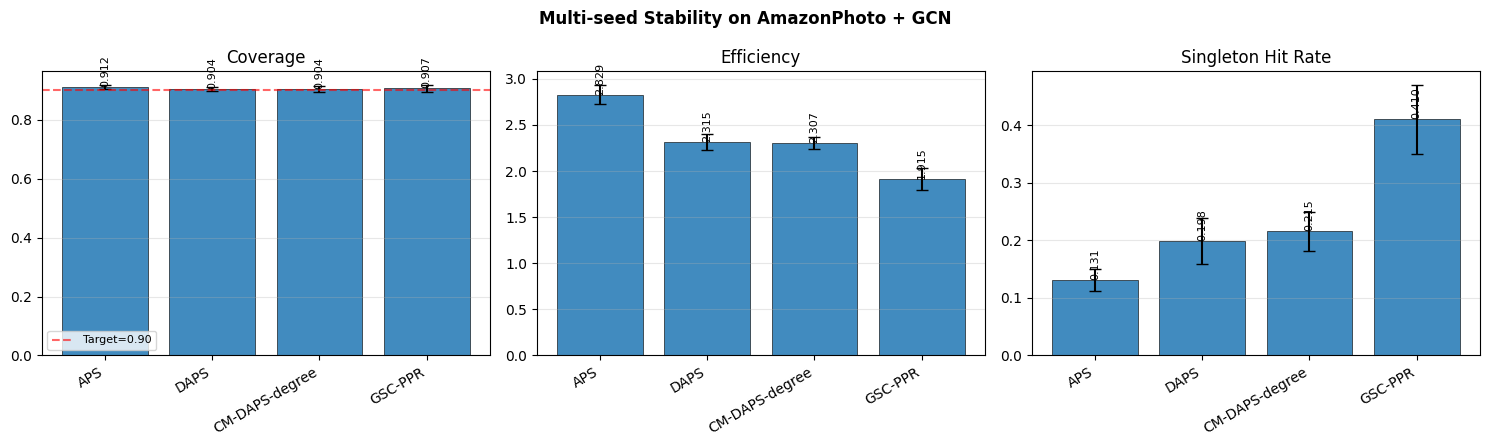

In [152]:
# ============================================================
# Multi-seed visualization
# ============================================================

metrics = ["Coverage", "Efficiency", "Singleton Hit Rate"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5)
)

for ax, metric in zip(axes, metrics):
    methods = multi_seed_df["Method"].unique()

    means = (
        multi_seed_df
        .groupby("Method")[metric]
        .mean()
        .reindex(methods)
    )

    stds = (
        multi_seed_df
        .groupby("Method")[metric]
        .std()
        .reindex(methods)
    )

    x = np.arange(len(methods))

    ax.bar(
        x,
        means.values,
        yerr=stds.values,
        capsize=4,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5
    )

    if metric == "Coverage":
        ax.axhline(
            y=1 - alpha,
            linestyle="--",
            color="red",
            alpha=0.6,
            label=f"Target={1-alpha:.2f}"
        )
        ax.legend(fontsize=8)

    for xi, v in zip(x, means.values):
        ax.text(
            xi,
            v,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=30, ha="right")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Multi-seed Stability on AmazonPhoto + GCN",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "multi_seed_stability_extra1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Saved: experiment_merged_all_model_results_with_dc.csv
Summary table


,Dataset,Model,Method,Coverage,Efficiency,Singleton Hit Rate
3,AmazonPhoto,GCN,APS,0.9104,2.8216,0.1288
5,AmazonPhoto,GCN,DAPS,0.9077,2.1097,0.2933
9,AmazonPhoto,GCN,GSC-PPR,0.9138,1.8242,0.4900
6,AmazonPhoto,GCN,DC-GSC-PPR(T=3),0.9191,1.9321,0.4482
7,AmazonPhoto,GCN,DGSC-PPR,0.9191,1.9887,0.3873
8,AmazonPhoto,GCN,FSGSC-PPR,0.9130,1.8268,0.4900
4,AmazonPhoto,GCN,CM-DAPS-degree,0.9008,2.0635,0.3159
10,AmazonPhoto,GCN,PR-CM-DAPS,0.8938,2.0331,0.3124
2,AmazonPhoto,GCN,2-SP DAPS,0.9034,1.7798,0.4447
0,AmazonPhoto,GCN,2-Hop CM-DAPS,0.8990,1.7755,0.4630


Best method by Efficiency


,Dataset,Model,Method,Coverage,Efficiency,Singleton Hit Rate
18,AmazonPhoto,GCN,2-Hop CM-DAPS,0.8990,1.7755,0.4630
32,AmazonPhoto,GraphSAGE,DC-GSC-PPR(T=3),0.9008,1.8964,0.3882
7,AmazonPhoto,MLP,2-SP DAPS,0.9017,1.8164,0.3647


Best method by Singleton Hit Rate


,Dataset,Model,Method,Coverage,Efficiency,Singleton Hit Rate
12,AmazonPhoto,GCN,GSC-PPR,0.9138,1.8242,0.4900
32,AmazonPhoto,GraphSAGE,DC-GSC-PPR(T=3),0.9008,1.8964,0.3882
7,AmazonPhoto,MLP,2-SP DAPS,0.9017,1.8164,0.3647


Best efficiency among methods with Coverage >= target


,Dataset,Model,Method,Coverage,Efficiency,Singleton Hit Rate
17,AmazonPhoto,GCN,2-SP DAPS,0.9034,1.7798,0.4447
32,AmazonPhoto,GraphSAGE,DC-GSC-PPR(T=3),0.9008,1.8964,0.3882
7,AmazonPhoto,MLP,2-SP DAPS,0.9017,1.8164,0.3647


Saved: comparison_with_dc_coverage.png


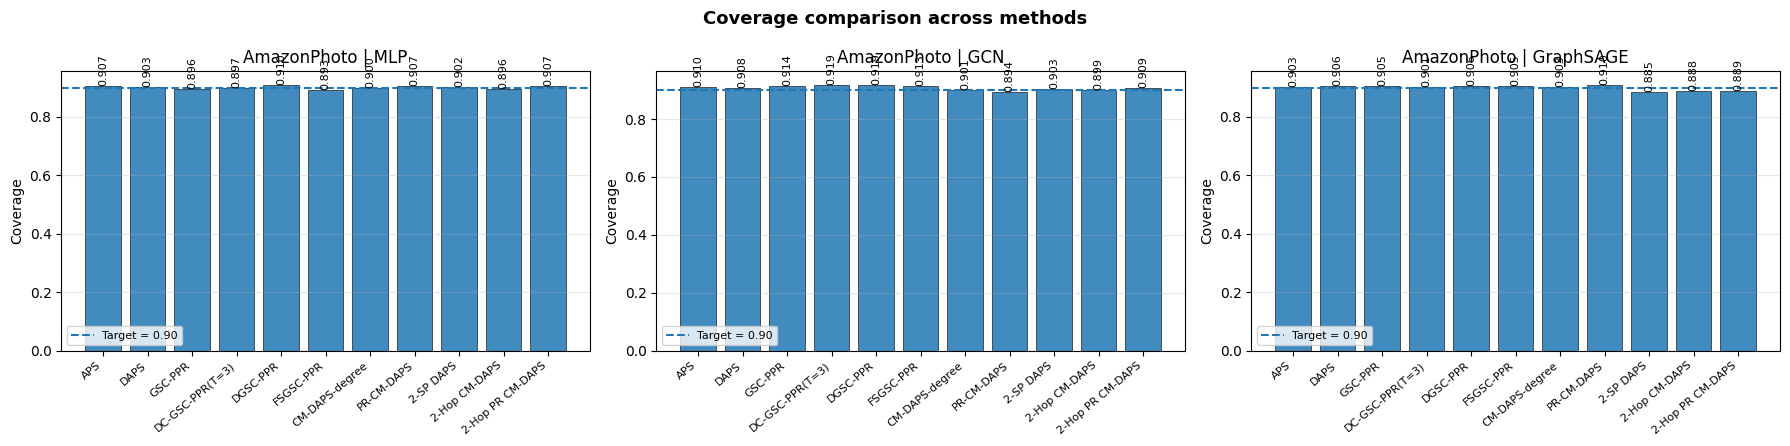

Saved: comparison_with_dc_efficiency.png


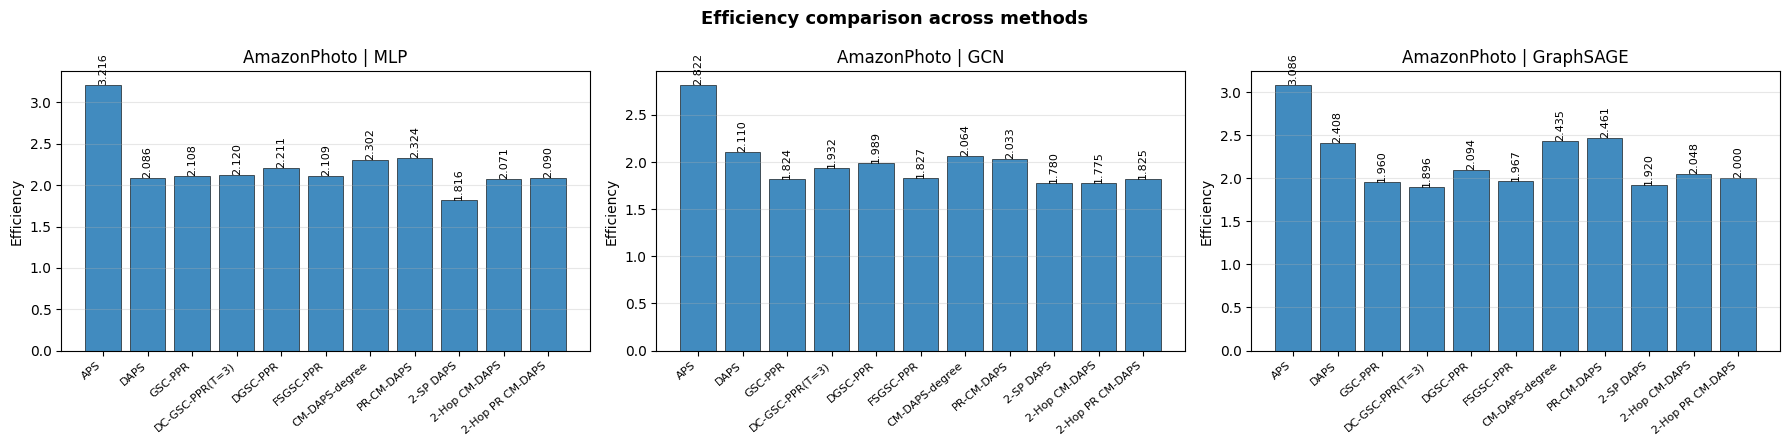

Saved: comparison_with_dc_singleton_hit_rate.png


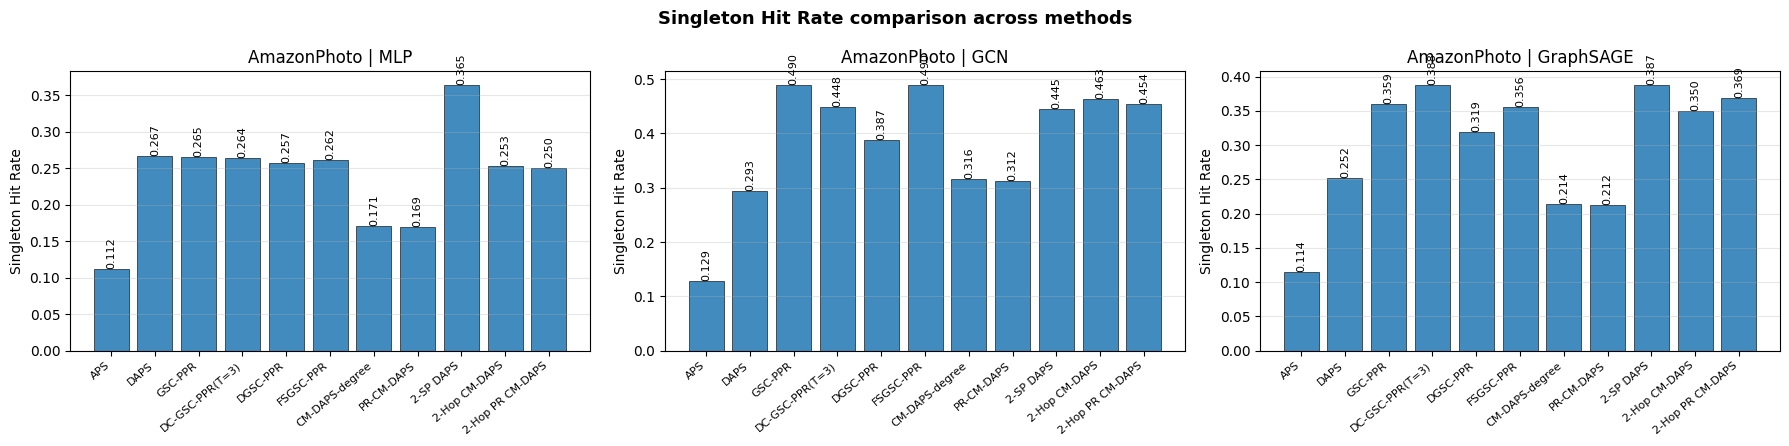

In [153]:
# ============================================================
# Summary tables + CSV export + comparison plots
# Use all_model_df_with_dc when available
# ============================================================

# ------------------------------------------------------------
# 1. Select result dataframe
# ------------------------------------------------------------
if "all_model_df_with_dc" in globals():
    result_for_summary = all_model_df_with_dc.copy()
    output_csv_name = "experiment_merged_all_model_results_with_dc.csv"
else:
    result_for_summary = all_model_df.copy()
    output_csv_name = "experiment_merged_all_model_results.csv"

result_for_summary.to_csv(output_csv_name, index=False)
print(f"Saved: {output_csv_name}")

# ------------------------------------------------------------
# 2. Method order
# ------------------------------------------------------------
method_order = [
    "APS",
    "DAPS",
    "GSC-PPR",
    f"DC-GSC-PPR(T={DC_T})",
    "DGSC-PPR",
    "FSGSC-PPR",
    "CM-DAPS-degree",
    "PR-CM-DAPS",
    "2-SP DAPS",
    "2-Hop CM-DAPS",
    "2-Hop PR CM-DAPS",
]

# 실제 존재하는 method만 유지
method_order_existing = [
    m for m in method_order
    if m in result_for_summary["Method"].unique()
]

# ------------------------------------------------------------
# 3. Summary table
# ------------------------------------------------------------
summary_df = (
    result_for_summary
    .groupby(["Dataset", "Model", "Method"])[
        ["Coverage", "Efficiency", "Singleton Hit Rate"]
    ]
    .mean()
    .reset_index()
)

summary_df["Method"] = pd.Categorical(
    summary_df["Method"],
    categories=method_order_existing,
    ordered=True
)

summary_df = summary_df.sort_values(["Dataset", "Model", "Method"])

print("Summary table")
display(summary_df.round(4))

summary_df.to_csv(
    "summary_table_with_dc.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Best method summaries
# ------------------------------------------------------------
best_efficiency_df = (
    result_for_summary
    .sort_values(["Dataset", "Model", "Efficiency"])
    .groupby(["Dataset", "Model"])
    .head(1)
    [["Dataset", "Model", "Method", "Coverage", "Efficiency", "Singleton Hit Rate"]]
)

print("Best method by Efficiency")
display(best_efficiency_df.round(4))

best_singleton_df = (
    result_for_summary
    .sort_values(
        ["Dataset", "Model", "Singleton Hit Rate"],
        ascending=[True, True, False]
    )
    .groupby(["Dataset", "Model"])
    .head(1)
    [["Dataset", "Model", "Method", "Coverage", "Efficiency", "Singleton Hit Rate"]]
)

print("Best method by Singleton Hit Rate")
display(best_singleton_df.round(4))

best_coverage_safe_df = (
    result_for_summary[
        result_for_summary["Coverage"] >= 1 - alpha
    ]
    .sort_values(["Dataset", "Model", "Efficiency"])
    .groupby(["Dataset", "Model"])
    .head(1)
    [["Dataset", "Model", "Method", "Coverage", "Efficiency", "Singleton Hit Rate"]]
)

print("Best efficiency among methods with Coverage >= target")
display(best_coverage_safe_df.round(4))

# ------------------------------------------------------------
# 5. Metric-wise bar plots
# ------------------------------------------------------------
def plot_method_comparison(result_df, metric, method_order, save=True):
    models = list(result_df["Model"].unique())

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(6.0 * len(models), 4.5),
        squeeze=False
    )

    for mi, model_name in enumerate(models):
        ax = axes[0][mi]

        sub = result_df[result_df["Model"] == model_name].copy()

        sub["Method"] = pd.Categorical(
            sub["Method"],
            categories=method_order,
            ordered=True
        )

        sub = sub.sort_values("Method")

        x = np.arange(len(sub))
        vals = sub[metric].values

        ax.bar(
            x,
            vals,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.5
        )

        if metric == "Coverage":
            ax.axhline(
                1 - alpha,
                linestyle="--",
                linewidth=1.5,
                label=f"Target = {1-alpha:.2f}"
            )
            ax.legend(fontsize=8)

        for xi, v in zip(x, vals):
            ax.text(
                xi,
                v,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

        ax.set_xticks(x)
        ax.set_xticklabels(
            sub["Method"].tolist(),
            rotation=40,
            ha="right",
            fontsize=8
        )

        ax.set_ylabel(metric)
        ax.set_title(f"AmazonPhoto | {model_name}")
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle(
        f"{metric} comparison across methods",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()

    if save:
        filename = f"comparison_with_dc_{metric.lower().replace(' ', '_')}.png"
        plt.savefig(filename, dpi=150, bbox_inches="tight")
        print(f"Saved: {filename}")

    plt.show()


for metric in ["Coverage", "Efficiency", "Singleton Hit Rate"]:
    plot_method_comparison(
        result_df=result_for_summary,
        metric=metric,
        method_order=method_order_existing,
        save=True
    )

Saved: centrality_error_MLP.png


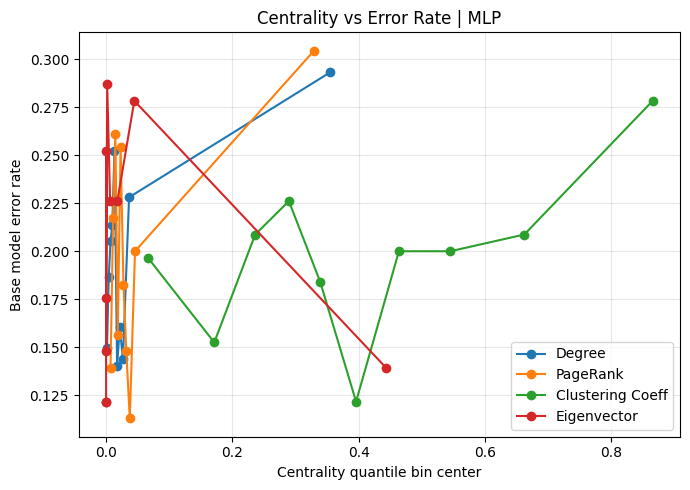

Saved: centrality_error_GCN.png


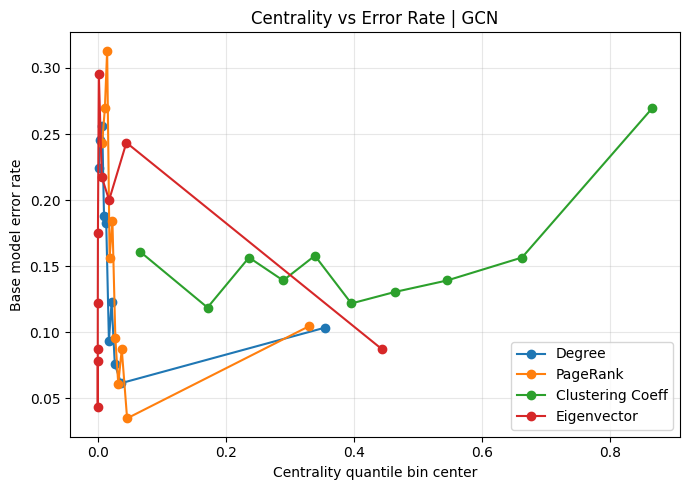

Saved: centrality_error_GraphSAGE.png


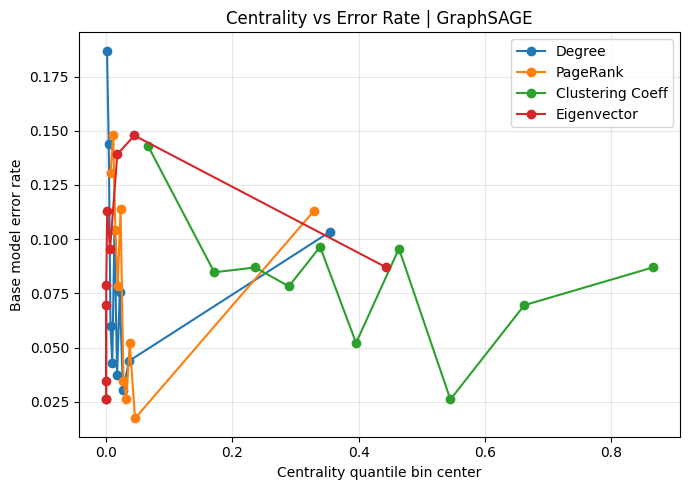

In [154]:
# ============================================================
# Optional analysis: centrality quantile vs model error rate
# ============================================================

def plot_centrality_error_for_current_models(model_outputs, centralities, data, n_bins=10):
    centrality_names = list(centralities.keys())

    for model_name, output in model_outputs.items():
        probs_model = output["probs"].detach().cpu()
        pred = probs_model.argmax(dim=1)
        y_cpu = data.y.detach().cpu()

        error = (pred != y_cpu).float().numpy()
        test_mask_np = data.test_mask.detach().cpu().numpy()

        plt.figure(figsize=(7, 5))

        for cname in centrality_names:
            cvals = centralities[cname]

            # test node만 사용
            x = cvals[test_mask_np]
            e = error[test_mask_np]

            # quantile bin 생성
            quantiles = np.quantile(x, np.linspace(0, 1, n_bins + 1))
            quantiles = np.unique(quantiles)

            bin_centers = []
            error_rates = []

            for i in range(len(quantiles) - 1):
                lo, hi = quantiles[i], quantiles[i + 1]

                if i == len(quantiles) - 2:
                    mask_bin = (x >= lo) & (x <= hi)
                else:
                    mask_bin = (x >= lo) & (x < hi)

                if mask_bin.sum() == 0:
                    continue

                bin_centers.append((lo + hi) / 2)
                error_rates.append(e[mask_bin].mean())

            plt.plot(
                bin_centers,
                error_rates,
                marker="o",
                label=cname
            )

        plt.xlabel("Centrality quantile bin center")
        plt.ylabel("Base model error rate")
        plt.title(f"Centrality vs Error Rate | {model_name}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        filename = f"centrality_error_{model_name}.png"
        plt.savefig(filename, dpi=150, bbox_inches="tight")
        print(f"Saved: {filename}")

        plt.show()


plot_centrality_error_for_current_models(
    model_outputs=model_outputs,
    centralities=centralities,
    data=data,
    n_bins=10
)

In [155]:
# ============================================================
# GSC-PPR Grand Sweep Configuration
# Dataset × Model × Method benchmark
# ============================================================

GRAND_DATASETS = [
    "CoraML",
    "PubMed",
    "CiteSeer",
    "AmazonPhoto",
    "AmazonComputers",
]

GRAND_MODELS = [
    "GCN",
    "GraphSAGE",
    "MLP",
]

GRAND_METHODS = [
    "APS",
    "DAPS",
    "GSC-PPR",
    "DC-GSC-PPR",
]

GRAND_DC_T = 3

GRAND_ALPHA = 0.1
GRAND_EPOCHS = 200
N_CAL_SEEDS = 5

LAMBDA_GRID_DAPS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
LAMBDA_GRID_GSC = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]


def load_dataset_by_name(name):
    if name == "AmazonPhoto":
        return Amazon(
            root="./data/Amazon",
            name="Photo",
            transform=NormalizeFeatures()
        )

    elif name == "AmazonComputers":
        return Amazon(
            root="./data/Amazon",
            name="Computers",
            transform=NormalizeFeatures()
        )

    elif name == "CoraML":
        return Planetoid(
            root="./data/Planetoid",
            name="Cora",
            transform=NormalizeFeatures()
        )

    elif name == "PubMed":
        return Planetoid(
            root="./data/Planetoid",
            name="PubMed",
            transform=NormalizeFeatures()
        )

    elif name == "CiteSeer":
        return Planetoid(
            root="./data/Planetoid",
            name="CiteSeer",
            transform=NormalizeFeatures()
        )

    else:
        raise ValueError(f"Unknown dataset name: {name}")


def resplit_cal_test(d, ratio=0.5, seed=42):
    set_seed(seed)

    pool = (d.cal_mask | d.test_mask).nonzero(as_tuple=False).view(-1)
    perm = pool[torch.randperm(pool.numel(), device=pool.device)]

    n_cal = int(ratio * pool.numel())

    new_cal = torch.zeros_like(d.cal_mask)
    new_test = torch.zeros_like(d.test_mask)

    new_cal[perm[:n_cal]] = True
    new_test[perm[n_cal:]] = True

    d.cal_mask = new_cal
    d.test_mask = new_test

    return d


print("Grand sweep configuration:")
print(f"  Datasets : {GRAND_DATASETS}")
print(f"  Models   : {GRAND_MODELS}")
print(f"  Methods  : {GRAND_METHODS}")
print(f"  alpha    : {GRAND_ALPHA}")
print(f"  Epochs   : {GRAND_EPOCHS}")
print(f"  Cal seeds: {N_CAL_SEEDS} per (dataset, model)")
print(
    "  Total model trainings: "
    f"{len(GRAND_DATASETS)} × {len(GRAND_MODELS)} = "
    f"{len(GRAND_DATASETS) * len(GRAND_MODELS)}"
)
print(
    "  Total evaluation rows: "
    f"{len(GRAND_DATASETS)} × {len(GRAND_MODELS)} × "
    f"{len(GRAND_METHODS)} × {N_CAL_SEEDS} = "
    f"{len(GRAND_DATASETS) * len(GRAND_MODELS) * len(GRAND_METHODS) * N_CAL_SEEDS}"
)

Grand sweep configuration:
  Datasets : ['CoraML', 'PubMed', 'CiteSeer', 'AmazonPhoto', 'AmazonComputers']
  Models   : ['GCN', 'GraphSAGE', 'MLP']
  Methods  : ['APS', 'DAPS', 'GSC-PPR', 'DC-GSC-PPR']
  alpha    : 0.1
  Epochs   : 200
  Cal seeds: 5 per (dataset, model)
  Total model trainings: 5 × 3 = 15
  Total evaluation rows: 5 × 3 × 4 × 5 = 300


In [156]:
# ============================================================
# GSC-PPR / DC-GSC-PPR Grand Sweep Main Loop
# ============================================================

all_records = []
start_time_total = time.time()

# 원래 전역 dataset/data 보존
_original_dataset = globals().get("dataset", None)
_original_data = globals().get("data", None)

for ds_name in GRAND_DATASETS:
    print(f"\n{'=' * 70}")
    print(f"Dataset: {ds_name}")
    print("=" * 70)

    t_ds = time.time()

    ds_obj = load_dataset_by_name(ds_name)
    d = ds_obj[0]

    d = random_split_with_tune_and_calibration(
        d,
        seed=42
    )

    d = d.to(device)

    # Degree-stratified q_hat correction용 centrality cache
    A_grand = sparse_adj(d.edge_index, d.num_nodes)

    centralities_cache_grand = compute_centralities(
        edge_index=d.edge_index,
        num_nodes=d.num_nodes,
        A=A_grand
    )

    print(
        f"nodes: {d.num_nodes:,} | "
        f"features: {ds_obj.num_features} | "
        f"classes: {ds_obj.num_classes}"
    )

    print(
        "train/val/tune/cal/test = "
        f"{d.train_mask.sum().item()}/"
        f"{d.val_mask.sum().item()}/"
        f"{d.tune_mask.sum().item()}/"
        f"{d.cal_mask.sum().item()}/"
        f"{d.test_mask.sum().item()}"
    )

    for model_name in GRAND_MODELS:
        print(f"\n▶ Model: {model_name}")
        t_model = time.time()

        # run_model은 전역 dataset/data를 참조하므로 임시로 갈아끼운다.
        globals()["dataset"] = ds_obj
        globals()["data"] = d

        output = run_model(
            model_name,
            epochs=GRAND_EPOCHS
        )

        probs_cur = output["probs"]
        aps_cur = aps_scores(probs_cur)

        # ------------------------------------------------------------
        # tune set에서 DAPS lambda와 GSC-PPR beta_base 선택
        # ------------------------------------------------------------
        best_daps, tune_daps = tune_lambda(
            base_scores=aps_cur,
            data=d,
            method="DAPS",
            alpha=GRAND_ALPHA,
            lambda_values=LAMBDA_GRID_DAPS,
            tolerance=0.01,
            seed=42
        )

        best_gsc, tune_gsc = tune_lambda(
            base_scores=aps_cur,
            data=d,
            method="GSC-PPR",
            alpha=GRAND_ALPHA,
            lambda_values=LAMBDA_GRID_GSC,
            probs=probs_cur,
            tolerance=0.01,
            seed=42
        )

        daps_lam = float(best_daps["Lambda"])
        gsc_beta = float(best_gsc["Lambda"])

        print(f"best DAPS lambda     = {daps_lam}")
        print(f"best GSC-PPR beta    = {gsc_beta}")
        print(f"test acc at best val = {output['test_acc_at_best_val']:.4f}")

        # ------------------------------------------------------------
        # 여러 calibration/test split에 대해 final evaluation
        # ------------------------------------------------------------
        for cal_seed in range(N_CAL_SEEDS):
            d = resplit_cal_test(
                d,
                ratio=0.5,
                seed=5000 + cal_seed
            )

            globals()["data"] = d

            for method in GRAND_METHODS:
                if method == "APS":
                    selected_lambda = 0.0
                    selected_gamma = 0.0
                    selected_probs = None

                    final_metrics, q_hat_final, final_scores, final_sets = final_cp_evaluation(
                        base_scores=aps_cur,
                        data=d,
                        method=method,
                        selected_lambda=selected_lambda,
                        selected_gamma=selected_gamma,
                        alpha=GRAND_ALPHA,
                        centrality=None,
                        probs=selected_probs
                    )

                    q_hat_record = q_hat_final.item()

                elif method == "DAPS":
                    selected_lambda = daps_lam
                    selected_gamma = 0.0
                    selected_probs = None

                    final_metrics, q_hat_final, final_scores, final_sets = final_cp_evaluation(
                        base_scores=aps_cur,
                        data=d,
                        method=method,
                        selected_lambda=selected_lambda,
                        selected_gamma=selected_gamma,
                        alpha=GRAND_ALPHA,
                        centrality=None,
                        probs=selected_probs
                    )

                    q_hat_record = q_hat_final.item()

                elif method == "GSC-PPR":
                    selected_lambda = gsc_beta
                    selected_gamma = 0.0
                    selected_probs = probs_cur

                    final_metrics, q_hat_final, final_scores, final_sets = final_cp_evaluation(
                        base_scores=aps_cur,
                        data=d,
                        method=method,
                        selected_lambda=selected_lambda,
                        selected_gamma=selected_gamma,
                        alpha=GRAND_ALPHA,
                        centrality=None,
                        probs=selected_probs
                    )

                    q_hat_record = q_hat_final.item()

                elif method == "DC-GSC-PPR":
                    selected_lambda = gsc_beta
                    selected_gamma = GRAND_DC_T
                    selected_probs = probs_cur

                    # 1) 먼저 GSC-PPR score를 만든다.
                    gsc_scores_cur = compute_method_scores(
                        base_scores=aps_cur,
                        data=d,
                        method="GSC-PPR",
                        lam=gsc_beta,
                        gamma=0.0,
                        probs=probs_cur
                    ).to(device)

                    # 2) 그 score 위에 degree-stratified q_hat을 적용한다.
                    final_metrics, final_sets, q_hats_dc, bounds_dc, bucket_info_dc = evaluate_stratified_scores(
                        scores=gsc_scores_cur,
                        labels=d.y,
                        data=d,
                        cal_mask=d.cal_mask,
                        test_mask=d.test_mask,
                        alpha=GRAND_ALPHA,
                        T=GRAND_DC_T,
                        stratify_by="degree",
                        centralities_cache=centralities_cache_grand
                    )

                    q_hat_record = "degree-stratified"

                else:
                    raise ValueError(f"Unknown method: {method}")

                all_records.append({
                    "Dataset": ds_name,
                    "Model": model_name,
                    "Method": method,
                    "CalSeed": cal_seed,
                    "Lambda": selected_lambda,
                    "Gamma": selected_gamma,
                    "Coverage": final_metrics["coverage"],
                    "Efficiency": final_metrics["efficiency"],
                    "SingletonHit": final_metrics["singleton_hit_rate"],
                    "TestAcc": output["test_acc_at_best_val"],
                    "q_hat": q_hat_record,
                })

        print(f"done in {time.time() - t_model:.1f}s")

    print(f"{ds_name} total time: {time.time() - t_ds:.1f}s")

# 원래 전역 dataset/data 복원
if _original_dataset is not None:
    globals()["dataset"] = _original_dataset

if _original_data is not None:
    globals()["data"] = _original_data

all_results_df = pd.DataFrame(all_records)

print(f"\n{'=' * 70}")
print(f"Grand sweep finished in {time.time() - start_time_total:.1f}s")
print(f"Total rows in all_results_df: {len(all_results_df)}")
print("=" * 70)

all_results_df.head(20)


Dataset: CoraML


Processing...
Done!


[centralities] N=2,708 computing... done (0.2s)
nodes: 2,708 | features: 1433 | classes: 7
train/val/tune/cal/test = 1083/406/406/406/407

▶ Model: GCN
[GCN] Epoch 020 | Loss 1.6050 | Train 0.3453 | Val 0.3227 | Test 0.3120
[GCN] Epoch 040 | Loss 1.2162 | Train 0.6824 | Val 0.6404 | Test 0.6536
[GCN] Epoch 060 | Loss 0.8828 | Train 0.8338 | Val 0.8005 | Test 0.7740
[GCN] Epoch 080 | Loss 0.6984 | Train 0.8864 | Val 0.8571 | Test 0.8305
[GCN] Epoch 100 | Loss 0.6018 | Train 0.9040 | Val 0.8768 | Test 0.8575
[GCN] Epoch 120 | Loss 0.5502 | Train 0.9151 | Val 0.8818 | Test 0.8624
[GCN] Epoch 140 | Loss 0.4894 | Train 0.9187 | Val 0.8793 | Test 0.8600
[GCN] Epoch 160 | Loss 0.4546 | Train 0.9178 | Val 0.8818 | Test 0.8624
[GCN] Epoch 180 | Loss 0.4323 | Train 0.9243 | Val 0.8867 | Test 0.8649
[GCN] Epoch 200 | Loss 0.4141 | Train 0.9298 | Val 0.8916 | Test 0.8624

[GCN] Best Val Acc: 0.8916, Test Acc: 0.8649
best DAPS lambda     = 0.7
best GSC-PPR beta    = 0.05
test acc at best val = 0.86

Processing...


[centralities] N=19,717 computing...

...

Done!


 done (0.2s)
nodes: 3,327 | features: 3703 | classes: 6
train/val/tune/cal/test = 1330/499/499/499/500

▶ Model: GCN
[GCN] Epoch 020 | Loss 1.5731 | Train 0.7083 | Val 0.6834 | Test 0.7280
[GCN] Epoch 040 | Loss 1.2542 | Train 0.7767 | Val 0.7375 | Test 0.7700
[GCN] Epoch 060 | Loss 0.9987 | Train 0.7917 | Val 0.7395 | Test 0.7640
[GCN] Epoch 080 | Loss 0.8506 | Train 0.8098 | Val 0.7415 | Test 0.7660
[GCN] Epoch 100 | Loss 0.7852 | Train 0.8211 | Val 0.7415 | Test 0.7700
[GCN] Epoch 120 | Loss 0.7218 | Train 0.8338 | Val 0.7475 | Test 0.7680
[GCN] Epoch 140 | Loss 0.6778 | Train 0.8504 | Val 0.7555 | Test 0.7780
[GCN] Epoch 160 | Loss 0.6402 | Train 0.8647 | Val 0.7555 | Test 0.7760
[GCN] Epoch 180 | Loss 0.6268 | Train 0.8684 | Val 0.7595 | Test 0.7720
[GCN] Epoch 200 | Loss 0.6023 | Train 0.8744 | Val 0.7655 | Test 0.7780

[GCN] Best Val Acc: 0.7655, Test Acc: 0.7760
best DAPS lambda     = 0.6
best GSC-PPR beta    = 0.15
test acc at best val = 0.7760
done in 1.5s

▶ Model: GraphSAGE

Processing...
Done!


[centralities] N=13,752 computing... done (16.3s)
nodes: 13,752 | features: 767 | classes: 10
train/val/tune/cal/test = 5500/2062/2062/2062/2066

▶ Model: GCN
[GCN] Epoch 020 | Loss 1.9101 | Train 0.3795 | Val 0.3758 | Test 0.3659
[GCN] Epoch 040 | Loss 1.8858 | Train 0.3795 | Val 0.3758 | Test 0.3659
[GCN] Epoch 060 | Loss 1.8546 | Train 0.3795 | Val 0.3758 | Test 0.3659
[GCN] Epoch 080 | Loss 1.8013 | Train 0.3795 | Val 0.3758 | Test 0.3659
[GCN] Epoch 100 | Loss 1.7296 | Train 0.3807 | Val 0.3768 | Test 0.3669
[GCN] Epoch 120 | Loss 1.6343 | Train 0.4291 | Val 0.4127 | Test 0.4056
[GCN] Epoch 140 | Loss 1.5484 | Train 0.5178 | Val 0.4976 | Test 0.4932
[GCN] Epoch 160 | Loss 1.4764 | Train 0.5756 | Val 0.5567 | Test 0.5440
[GCN] Epoch 180 | Loss 1.4183 | Train 0.6075 | Val 0.5936 | Test 0.5774
[GCN] Epoch 200 | Loss 1.3602 | Train 0.6213 | Val 0.6038 | Test 0.5881

[GCN] Best Val Acc: 0.6140, Test Acc: 0.5963
best DAPS lambda     = 0.2
best GSC-PPR beta    = 0.5
test acc at best val 

,Dataset,Model,Method,CalSeed,Lambda,Gamma,Coverage,Efficiency,SingletonHit,TestAcc,q_hat
0,CoraML,GCN,APS,0,0.00,0.0,0.891892,3.550369,0.093366,0.864865,0.963627
1,CoraML,GCN,DAPS,0,0.70,0.0,0.916462,3.171990,0.137592,0.864865,0.957449
2,CoraML,GCN,GSC-PPR,0,0.05,0.0,0.904177,2.356265,0.353808,0.864865,0.943323
3,CoraML,GCN,DC-GSC-PPR,0,0.05,3.0,0.901720,2.348894,0.339066,0.864865,degree-stratified
4,CoraML,GCN,APS,1,0.00,0.0,0.894349,3.552825,0.083538,0.864865,0.964032
5,CoraML,GCN,DAPS,1,0.70,0.0,0.933661,3.253071,0.135135,0.864865,0.960796
6,CoraML,GCN,GSC-PPR,1,0.05,0.0,0.899263,2.250614,0.346437,0.864865,0.942873
7,CoraML,GCN,DC-GSC-PPR,1,0.05,3.0,0.911548,2.400491,0.329238,0.864865,degree-stratified
8,CoraML,GCN,APS,2,0.00,0.0,0.918919,3.805897,0.068796,0.864865,0.969096
9,CoraML,GCN,DAPS,2,0.70,0.0,0.909091,3.120393,0.122850,0.864865,0.956575


In [157]:
# ============================================================
# Save raw grand sweep results
# ============================================================

all_results_df.to_csv(
    "grand_sweep_raw.csv",
    index=False
)

print(f"Saved {len(all_results_df)} rows to grand_sweep_raw.csv")
all_results_df.head()

Saved 300 rows to grand_sweep_raw.csv


,Dataset,Model,Method,CalSeed,Lambda,Gamma,Coverage,Efficiency,SingletonHit,TestAcc,q_hat
0,CoraML,GCN,APS,0,0.00,0.0,0.891892,3.550369,0.093366,0.864865,0.963627
1,CoraML,GCN,DAPS,0,0.70,0.0,0.916462,3.171990,0.137592,0.864865,0.957449
2,CoraML,GCN,GSC-PPR,0,0.05,0.0,0.904177,2.356265,0.353808,0.864865,0.943323
3,CoraML,GCN,DC-GSC-PPR,0,0.05,3.0,0.901720,2.348894,0.339066,0.864865,degree-stratified
4,CoraML,GCN,APS,1,0.00,0.0,0.894349,3.552825,0.083538,0.864865,0.964032


In [170]:
# ============================================================
# Aggregate grand sweep results over calibration/test seeds
# ============================================================

agg = (
    all_results_df
    .groupby(["Dataset", "Model", "Method"])
    .agg(
        Cov_mean=("Coverage", "mean"),
        Cov_std=("Coverage", "std"),
        Eff_mean=("Efficiency", "mean"),
        Eff_std=("Efficiency", "std"),
        SHR_mean=("SingletonHit", "mean"),
        SHR_std=("SingletonHit", "std"),
        Lambda=("Lambda", "first"),
        TestAcc=("TestAcc", "first"),
    )
    .round(4)
    .reset_index()
)

method_order = pd.CategoricalDtype(
    ["APS", "DAPS", "GSC-PPR", "DC-GSC-PPR"],
    ordered=True
)

agg["Method"] = agg["Method"].astype(method_order)
agg = agg.sort_values(
    ["Dataset", "Model", "Method"]
).reset_index(drop=True)

agg["Coverage"] = agg.apply(
    lambda r: f"{r.Cov_mean:.3f} ± {r.Cov_std:.3f}",
    axis=1
)

agg["Efficiency"] = agg.apply(
    lambda r: f"{r.Eff_mean:.3f} ± {r.Eff_std:.3f}",
    axis=1
)

agg["SingletonHit"] = agg.apply(
    lambda r: f"{r.SHR_mean:.3f} ± {r.SHR_std:.3f}",
    axis=1
)

display_cols = [
    "Dataset",
    "Model",
    "Method",
    "TestAcc",
    "Lambda",
    "Coverage",
    "Efficiency",
    "SingletonHit",
]

agg_display = agg[display_cols]

agg_display.to_csv(
    "grand_sweep_aggregated.csv",
    index=False
)

agg_display

,Dataset,Model,Method,TestAcc,Lambda,Coverage,Efficiency,SingletonHit
0,AmazonComputers,GCN,APS,0.5963,0.00,0.903 ± 0.008,5.014 ± 0.103,0.018 ± 0.004
1,AmazonComputers,GCN,DAPS,0.5963,0.20,0.901 ± 0.006,4.902 ± 0.103,0.017 ± 0.005
2,AmazonComputers,GCN,GSC-PPR,0.5963,0.50,0.904 ± 0.005,4.875 ± 0.063,0.007 ± 0.002
3,AmazonComputers,GCN,DC-GSC-PPR,0.5963,0.50,0.903 ± 0.004,4.896 ± 0.083,0.005 ± 0.002
4,AmazonComputers,GraphSAGE,APS,0.7471,0.00,0.902 ± 0.010,4.113 ± 0.087,0.081 ± 0.003
5,AmazonComputers,GraphSAGE,DAPS,0.7471,0.70,0.903 ± 0.012,3.447 ± 0.041,0.160 ± 0.005
6,AmazonComputers,GraphSAGE,GSC-PPR,0.7471,0.05,0.902 ± 0.010,2.917 ± 0.007,0.308 ± 0.007
7,AmazonComputers,GraphSAGE,DC-GSC-PPR,0.7471,0.05,0.903 ± 0.008,2.934 ± 0.008,0.308 ± 0.007
8,AmazonComputers,MLP,APS,0.5950,0.00,0.906 ± 0.006,5.017 ± 0.059,0.023 ± 0.001
9,AmazonComputers,MLP,DAPS,0.5950,0.20,0.900 ± 0.009,4.692 ± 0.045,0.039 ± 0.004


In [171]:
# ============================================================
# Pivot tables: APS vs DAPS vs GSC-PPR vs DC-GSC-PPR
# ============================================================

def pivot_metric(df, value_col):
    p = df.pivot_table(
        index=["Dataset", "Model"],
        columns="Method",
        values=value_col,
        observed=True
    )

    method_cols = [
        m for m in ["APS", "DAPS", "GSC-PPR", "DC-GSC-PPR"]
        if m in p.columns
    ]

    p = p[method_cols]

    return p.round(4)


print("===== Efficiency: lower is better =====")
pivot_eff = pivot_metric(agg, "Eff_mean")

if "GSC-PPR" in pivot_eff.columns and "DAPS" in pivot_eff.columns:
    pivot_eff["Delta_GSC_minus_DAPS"] = (
        pivot_eff["GSC-PPR"] - pivot_eff["DAPS"]
    ).round(4)

if "DC-GSC-PPR" in pivot_eff.columns and "DAPS" in pivot_eff.columns:
    pivot_eff["Delta_DC_minus_DAPS"] = (
        pivot_eff["DC-GSC-PPR"] - pivot_eff["DAPS"]
    ).round(4)

if "DC-GSC-PPR" in pivot_eff.columns and "GSC-PPR" in pivot_eff.columns:
    pivot_eff["Delta_DC_minus_GSC"] = (
        pivot_eff["DC-GSC-PPR"] - pivot_eff["GSC-PPR"]
    ).round(4)

display(pivot_eff)


print("\n===== Singleton Hit Rate: higher is better =====")
pivot_shr = pivot_metric(agg, "SHR_mean")

if "GSC-PPR" in pivot_shr.columns and "DAPS" in pivot_shr.columns:
    pivot_shr["Delta_GSC_minus_DAPS"] = (
        pivot_shr["GSC-PPR"] - pivot_shr["DAPS"]
    ).round(4)

if "DC-GSC-PPR" in pivot_shr.columns and "DAPS" in pivot_shr.columns:
    pivot_shr["Delta_DC_minus_DAPS"] = (
        pivot_shr["DC-GSC-PPR"] - pivot_shr["DAPS"]
    ).round(4)

if "DC-GSC-PPR" in pivot_shr.columns and "GSC-PPR" in pivot_shr.columns:
    pivot_shr["Delta_DC_minus_GSC"] = (
        pivot_shr["DC-GSC-PPR"] - pivot_shr["GSC-PPR"]
    ).round(4)

display(pivot_shr)


print("\n===== Coverage: target is 0.9 =====")
pivot_cov = pivot_metric(agg, "Cov_mean")

if "DC-GSC-PPR" in pivot_cov.columns and "GSC-PPR" in pivot_cov.columns:
    pivot_cov["Delta_DC_minus_GSC"] = (
        pivot_cov["DC-GSC-PPR"] - pivot_cov["GSC-PPR"]
    ).round(4)

display(pivot_cov)

===== Efficiency: lower is better =====


Method                        APS    DAPS  GSC-PPR  DC-GSC-PPR  \
Dataset         Model                                            
AmazonComputers GCN        5.0143  4.9024   4.8750      4.8962   
                GraphSAGE  4.1129  3.4475   2.9167      2.9341   
                MLP        5.0172  4.6924   4.5516      4.5492   
AmazonPhoto     GCN        2.5463  1.9854   1.8793      2.0294   
                GraphSAGE  2.5857  2.1333   1.6315      1.7038   
                MLP        3.1118  2.4873   2.4129      2.4782   
CiteSeer        GCN        2.9244  2.6208   2.4664      2.4784   
                GraphSAGE  3.0856  3.0056   2.5900      2.6792   
                MLP        3.2172  2.6480   2.7048      2.7864   
CoraML          GCN        3.6197  3.1032   2.2983      2.4113   
                GraphSAGE  3.9248  3.9248   2.6919      2.8280   
                MLP        4.0172  3.1563   2.8378      2.9995   
PubMed          GCN        1.6308  1.4285   1.2404      1.2383   
                GraphSAGE  1.4450  1.4450   1.2644      1.2725   
                MLP        1.4716  1.4070   1.2160      1.2186   

Method                     Delta_GSC_minus_DAPS  Delta_DC_minus_DAPS  \
Dataset         Model                                                  
AmazonComputers GCN                     -0.0274              -0.0062   
                GraphSAGE               -0.5308              -0.5134   
                MLP                     -0.1408              -0.1432   
AmazonPhoto     GCN                     -0.1061               0.0440   
                GraphSAGE               -0.5018              -0.4295   
                MLP                     -0.0744              -0.0091   
CiteSeer        GCN                     -0.1544              -0.1424   
                GraphSAGE               -0.4156              -0.3264   
                MLP                      0.0568               0.1384   
CoraML          GCN                     -0.8049              -0.6919   
                GraphSAGE               -1.2329              -1.0968   
                MLP                     -0.3185              -0.1568   
PubMed          GCN                     -0.1881              -0.1902   
                GraphSAGE               -0.1806              -0.1725   
                MLP                     -0.1910              -0.1884   

Method                     Delta_DC_minus_GSC  
Dataset         Model                          
AmazonComputers GCN                    0.0212  
                GraphSAGE              0.0174  
                MLP                   -0.0024  
AmazonPhoto     GCN                    0.1501  
                GraphSAGE              0.0723  
                MLP                    0.0653  
CiteSeer        GCN                    0.0120  
                GraphSAGE              0.0892  
                MLP                    0.0816  
CoraML          GCN                    0.1130  
                GraphSAGE              0.1361  
                MLP                    0.1617  
PubMed          GCN                   -0.0021  
                GraphSAGE              0.0081  
                MLP                    0.0026


===== Singleton Hit Rate: higher is better =====


Method                        APS    DAPS  GSC-PPR  DC-GSC-PPR  \
Dataset         Model                                            
AmazonComputers GCN        0.0178  0.0170   0.0069      0.0047   
                GraphSAGE  0.0811  0.1597   0.3080      0.3083   
                MLP        0.0229  0.0393   0.0359      0.0359   
AmazonPhoto     GCN        0.1310  0.2882   0.3704      0.3305   
                GraphSAGE  0.1693  0.2822   0.4922      0.4632   
                MLP        0.1099  0.1707   0.2085      0.1988   
CiteSeer        GCN        0.0804  0.1300   0.1952      0.1940   
                GraphSAGE  0.0824  0.1092   0.2064      0.1928   
                MLP        0.0668  0.1788   0.1760      0.1680   
CoraML          GCN        0.0801  0.1312   0.3504      0.3342   
                GraphSAGE  0.0575  0.0575   0.2649      0.2496   
                MLP        0.0437  0.1204   0.2373      0.2231   
PubMed          GCN        0.2301  0.4814   0.6603      0.6623   
                GraphSAGE  0.4062  0.4062   0.6247      0.6209   
                MLP        0.3956  0.4925   0.6794      0.6754   

Method                     Delta_GSC_minus_DAPS  Delta_DC_minus_DAPS  \
Dataset         Model                                                  
AmazonComputers GCN                     -0.0101              -0.0123   
                GraphSAGE                0.1483               0.1486   
                MLP                     -0.0034              -0.0034   
AmazonPhoto     GCN                      0.0822               0.0423   
                GraphSAGE                0.2100               0.1810   
                MLP                      0.0378               0.0281   
CiteSeer        GCN                      0.0652               0.0640   
                GraphSAGE                0.0972               0.0836   
                MLP                     -0.0028              -0.0108   
CoraML          GCN                      0.2192               0.2030   
                GraphSAGE                0.2074               0.1921   
                MLP                      0.1169               0.1027   
PubMed          GCN                      0.1789               0.1809   
                GraphSAGE                0.2185               0.2147   
                MLP                      0.1869               0.1829   

Method                     Delta_DC_minus_GSC  
Dataset         Model                          
AmazonComputers GCN                   -0.0022  
                GraphSAGE              0.0003  
                MLP                    0.0000  
AmazonPhoto     GCN                   -0.0399  
                GraphSAGE             -0.0290  
                MLP                   -0.0097  
CiteSeer        GCN                   -0.0012  
                GraphSAGE             -0.0136  
                MLP                   -0.0080  
CoraML          GCN                   -0.0162  
                GraphSAGE             -0.0153  
                MLP                   -0.0142  
PubMed          GCN                    0.0020  
                GraphSAGE             -0.0038  
                MLP                   -0.0040


===== Coverage: target is 0.9 =====


Method                        APS    DAPS  GSC-PPR  DC-GSC-PPR  \
Dataset         Model                                            
AmazonComputers GCN        0.9029  0.9008   0.9042      0.9032   
                GraphSAGE  0.9024  0.9029   0.9021      0.9035   
                MLP        0.9061  0.9004   0.9007      0.9011   
AmazonPhoto     GCN        0.8909  0.8941   0.8943      0.8988   
                GraphSAGE  0.9028  0.8918   0.8932      0.8990   
                MLP        0.8970  0.8979   0.8967      0.9002   
CiteSeer        GCN        0.9092  0.9132   0.9140      0.9112   
                GraphSAGE  0.9136  0.9096   0.9052      0.9144   
                MLP        0.9100  0.9028   0.9048      0.9080   
CoraML          GCN        0.9042  0.9125   0.9106      0.9209   
                GraphSAGE  0.9066  0.9066   0.9165      0.9219   
                MLP        0.9081  0.9032   0.9214      0.9268   
PubMed          GCN        0.9030  0.9009   0.9000      0.8998   
                GraphSAGE  0.8954  0.8954   0.8985      0.9008   
                MLP        0.8998  0.9025   0.8993      0.8988   

Method                     Delta_DC_minus_GSC  
Dataset         Model                          
AmazonComputers GCN                   -0.0010  
                GraphSAGE              0.0014  
                MLP                    0.0004  
AmazonPhoto     GCN                    0.0045  
                GraphSAGE              0.0058  
                MLP                    0.0035  
CiteSeer        GCN                   -0.0028  
                GraphSAGE              0.0092  
                MLP                    0.0032  
CoraML          GCN                    0.0103  
                GraphSAGE              0.0054  
                MLP                    0.0054  
PubMed          GCN                   -0.0002  
                GraphSAGE              0.0023  
                MLP                   -0.0005

In [172]:
# ============================================================
# Winner analysis: GSC-PPR vs DAPS
# ============================================================

winner_rows = []

for (ds, mdl), grp in agg.groupby(["Dataset", "Model"]):
    grp = grp.set_index("Method")

    if "DAPS" not in grp.index or "GSC-PPR" not in grp.index:
        continue

    eff_daps = grp.loc["DAPS", "Eff_mean"]
    eff_gsc = grp.loc["GSC-PPR", "Eff_mean"]

    shr_daps = grp.loc["DAPS", "SHR_mean"]
    shr_gsc = grp.loc["GSC-PPR", "SHR_mean"]

    eff_std_avg = (
        grp.loc["DAPS", "Eff_std"] +
        grp.loc["GSC-PPR", "Eff_std"]
    ) / 2

    shr_std_avg = (
        grp.loc["DAPS", "SHR_std"] +
        grp.loc["GSC-PPR", "SHR_std"]
    ) / 2

    eff_diff = eff_gsc - eff_daps
    shr_diff = shr_gsc - shr_daps

    winner_rows.append({
        "Dataset": ds,
        "Model": mdl,

        "Eff_DAPS": round(eff_daps, 4),
        "Eff_GSC": round(eff_gsc, 4),
        "Eff_Delta": round(eff_diff, 4),
        "Eff_signif": abs(eff_diff) > eff_std_avg,
        "Eff_winner": (
            "GSC-PPR" if eff_diff < 0
            else "DAPS" if eff_diff > 0
            else "tie"
        ),

        "SHR_DAPS": round(shr_daps, 4),
        "SHR_GSC": round(shr_gsc, 4),
        "SHR_Delta": round(shr_diff, 4),
        "SHR_signif": abs(shr_diff) > shr_std_avg,
        "SHR_winner": (
            "GSC-PPR" if shr_diff > 0
            else "DAPS" if shr_diff < 0
            else "tie"
        ),
    })

winner_df = pd.DataFrame(winner_rows)

n_total = len(winner_df)

eff_gsc_wins = (
    winner_df["Eff_winner"] == "GSC-PPR"
).sum()

shr_gsc_wins = (
    winner_df["SHR_winner"] == "GSC-PPR"
).sum()

eff_signif_wins = (
    (winner_df["Eff_winner"] == "GSC-PPR") &
    (winner_df["Eff_signif"])
).sum()

shr_signif_wins = (
    (winner_df["SHR_winner"] == "GSC-PPR") &
    (winner_df["SHR_signif"])
).sum()

print(f"Total combinations: {n_total}")
print(
    f"GSC-PPR wins on Efficiency: "
    f"{eff_gsc_wins}/{n_total} "
    f"({eff_signif_wins} significant by std heuristic)"
)
print(
    f"GSC-PPR wins on Singleton Hit Rate: "
    f"{shr_gsc_wins}/{n_total} "
    f"({shr_signif_wins} significant by std heuristic)"
)

winner_df

Total combinations: 15
GSC-PPR wins on Efficiency: 14/15 (13 significant by std heuristic)
GSC-PPR wins on Singleton Hit Rate: 12/15 (12 significant by std heuristic)


,Dataset,Model,Eff_DAPS,Eff_GSC,Eff_Delta,Eff_signif,Eff_winner,SHR_DAPS,SHR_GSC,SHR_Delta,SHR_signif,SHR_winner
0,AmazonComputers,GCN,4.9024,4.8750,-0.0274,False,GSC-PPR,0.0170,0.0069,-0.0101,True,DAPS
1,AmazonComputers,GraphSAGE,3.4475,2.9167,-0.5308,True,GSC-PPR,0.1597,0.3080,0.1483,True,GSC-PPR
2,AmazonComputers,MLP,4.6924,4.5516,-0.1408,True,GSC-PPR,0.0393,0.0359,-0.0034,True,DAPS
3,AmazonPhoto,GCN,1.9854,1.8793,-0.1061,True,GSC-PPR,0.2882,0.3704,0.0822,True,GSC-PPR
4,AmazonPhoto,GraphSAGE,2.1333,1.6315,-0.5018,True,GSC-PPR,0.2822,0.4922,0.2100,True,GSC-PPR
5,AmazonPhoto,MLP,2.4873,2.4129,-0.0744,True,GSC-PPR,0.1707,0.2085,0.0378,True,GSC-PPR
6,CiteSeer,GCN,2.6208,2.4664,-0.1544,True,GSC-PPR,0.1300,0.1952,0.0652,True,GSC-PPR
7,CiteSeer,GraphSAGE,3.0056,2.5900,-0.4156,True,GSC-PPR,0.1092,0.2064,0.0972,True,GSC-PPR
8,CiteSeer,MLP,2.6480,2.7048,0.0568,False,DAPS,0.1788,0.1760,-0.0028,False,DAPS
9,CoraML,GCN,3.1032,2.2983,-0.8049,True,GSC-PPR,0.1312,0.3504,0.2192,True,GSC-PPR


In [173]:
# ============================================================
# Coverage-safe winner analysis including DC-GSC-PPR
# ============================================================

coverage_safe_winners = []

for (ds, mdl), grp in agg.groupby(["Dataset", "Model"]):
    valid = grp[grp["Cov_mean"] >= 1 - GRAND_ALPHA]

    if len(valid) == 0:
        chosen = grp.sort_values("Cov_mean", ascending=False).iloc[0]
        selection_rule = "highest coverage fallback"
    else:
        chosen = valid.sort_values("Eff_mean").iloc[0]
        selection_rule = "min efficiency among coverage-safe methods"

    coverage_safe_winners.append({
        "Dataset": ds,
        "Model": mdl,
        "Selected Method": chosen["Method"],
        "Coverage": chosen["Cov_mean"],
        "Efficiency": chosen["Eff_mean"],
        "SingletonHit": chosen["SHR_mean"],
        "Rule": selection_rule,
    })

coverage_safe_winner_df = pd.DataFrame(coverage_safe_winners)

display(coverage_safe_winner_df.round(4))

print("Coverage-safe winner counts")
coverage_safe_winner_counts = (
    coverage_safe_winner_df["Selected Method"]
    .value_counts()
    .reset_index()
)

coverage_safe_winner_counts.columns = ["Method", "Count"]

display(coverage_safe_winner_counts)

,Dataset,Model,Selected Method,Coverage,Efficiency,SingletonHit,Rule
0,AmazonComputers,GCN,GSC-PPR,0.9042,4.8750,0.0069,min efficiency among coverage-safe methods
1,AmazonComputers,GraphSAGE,GSC-PPR,0.9021,2.9167,0.3080,min efficiency among coverage-safe methods
2,AmazonComputers,MLP,DC-GSC-PPR,0.9011,4.5492,0.0359,min efficiency among coverage-safe methods
3,AmazonPhoto,GCN,DC-GSC-PPR,0.8988,2.0294,0.3305,highest coverage fallback
4,AmazonPhoto,GraphSAGE,APS,0.9028,2.5857,0.1693,min efficiency among coverage-safe methods
5,AmazonPhoto,MLP,DC-GSC-PPR,0.9002,2.4782,0.1988,min efficiency among coverage-safe methods
6,CiteSeer,GCN,GSC-PPR,0.9140,2.4664,0.1952,min efficiency among coverage-safe methods
7,CiteSeer,GraphSAGE,GSC-PPR,0.9052,2.5900,0.2064,min efficiency among coverage-safe methods
8,CiteSeer,MLP,DAPS,0.9028,2.6480,0.1788,min efficiency among coverage-safe methods
9,CoraML,GCN,GSC-PPR,0.9106,2.2983,0.3504,min efficiency among coverage-safe methods


Coverage-safe winner counts


,Method,Count
0,GSC-PPR,8
1,DC-GSC-PPR,4
2,DAPS,2
3,APS,1


In [174]:
# ============================================================
# DC-GSC-PPR vs GSC-PPR comparison
# ============================================================

dc_compare_rows = []

for (ds, mdl), grp in agg.groupby(["Dataset", "Model"]):
    grp = grp.set_index("Method")

    if "GSC-PPR" not in grp.index or "DC-GSC-PPR" not in grp.index:
        continue

    dc_compare_rows.append({
        "Dataset": ds,
        "Model": mdl,
        "Delta_Cov_DC_minus_GSC": grp.loc["DC-GSC-PPR", "Cov_mean"] - grp.loc["GSC-PPR", "Cov_mean"],
        "Delta_Eff_DC_minus_GSC": grp.loc["DC-GSC-PPR", "Eff_mean"] - grp.loc["GSC-PPR", "Eff_mean"],
        "Delta_SHR_DC_minus_GSC": grp.loc["DC-GSC-PPR", "SHR_mean"] - grp.loc["GSC-PPR", "SHR_mean"],
        "GSC_Cov": grp.loc["GSC-PPR", "Cov_mean"],
        "DC_Cov": grp.loc["DC-GSC-PPR", "Cov_mean"],
        "GSC_Eff": grp.loc["GSC-PPR", "Eff_mean"],
        "DC_Eff": grp.loc["DC-GSC-PPR", "Eff_mean"],
        "GSC_SHR": grp.loc["GSC-PPR", "SHR_mean"],
        "DC_SHR": grp.loc["DC-GSC-PPR", "SHR_mean"],
    })

dc_compare_df = pd.DataFrame(dc_compare_rows)

display(dc_compare_df.round(4))

dc_compare_df.to_csv(
    "dc_gsc_vs_gsc_comparison.csv",
    index=False
)

,Dataset,Model,Delta_Cov_DC_minus_GSC,Delta_Eff_DC_minus_GSC,Delta_SHR_DC_minus_GSC,GSC_Cov,DC_Cov,GSC_Eff,DC_Eff,GSC_SHR,DC_SHR
0,AmazonComputers,GCN,-0.0010,0.0212,-0.0022,0.9042,0.9032,4.8750,4.8962,0.0069,0.0047
1,AmazonComputers,GraphSAGE,0.0014,0.0174,0.0003,0.9021,0.9035,2.9167,2.9341,0.3080,0.3083
2,AmazonComputers,MLP,0.0004,-0.0024,0.0000,0.9007,0.9011,4.5516,4.5492,0.0359,0.0359
3,AmazonPhoto,GCN,0.0045,0.1501,-0.0399,0.8943,0.8988,1.8793,2.0294,0.3704,0.3305
4,AmazonPhoto,GraphSAGE,0.0058,0.0723,-0.0290,0.8932,0.8990,1.6315,1.7038,0.4922,0.4632
5,AmazonPhoto,MLP,0.0035,0.0653,-0.0097,0.8967,0.9002,2.4129,2.4782,0.2085,0.1988
6,CiteSeer,GCN,-0.0028,0.0120,-0.0012,0.9140,0.9112,2.4664,2.4784,0.1952,0.1940
7,CiteSeer,GraphSAGE,0.0092,0.0892,-0.0136,0.9052,0.9144,2.5900,2.6792,0.2064,0.1928
8,CiteSeer,MLP,0.0032,0.0816,-0.0080,0.9048,0.9080,2.7048,2.7864,0.1760,0.1680
9,CoraML,GCN,0.0103,0.1130,-0.0162,0.9106,0.9209,2.2983,2.4113,0.3504,0.3342


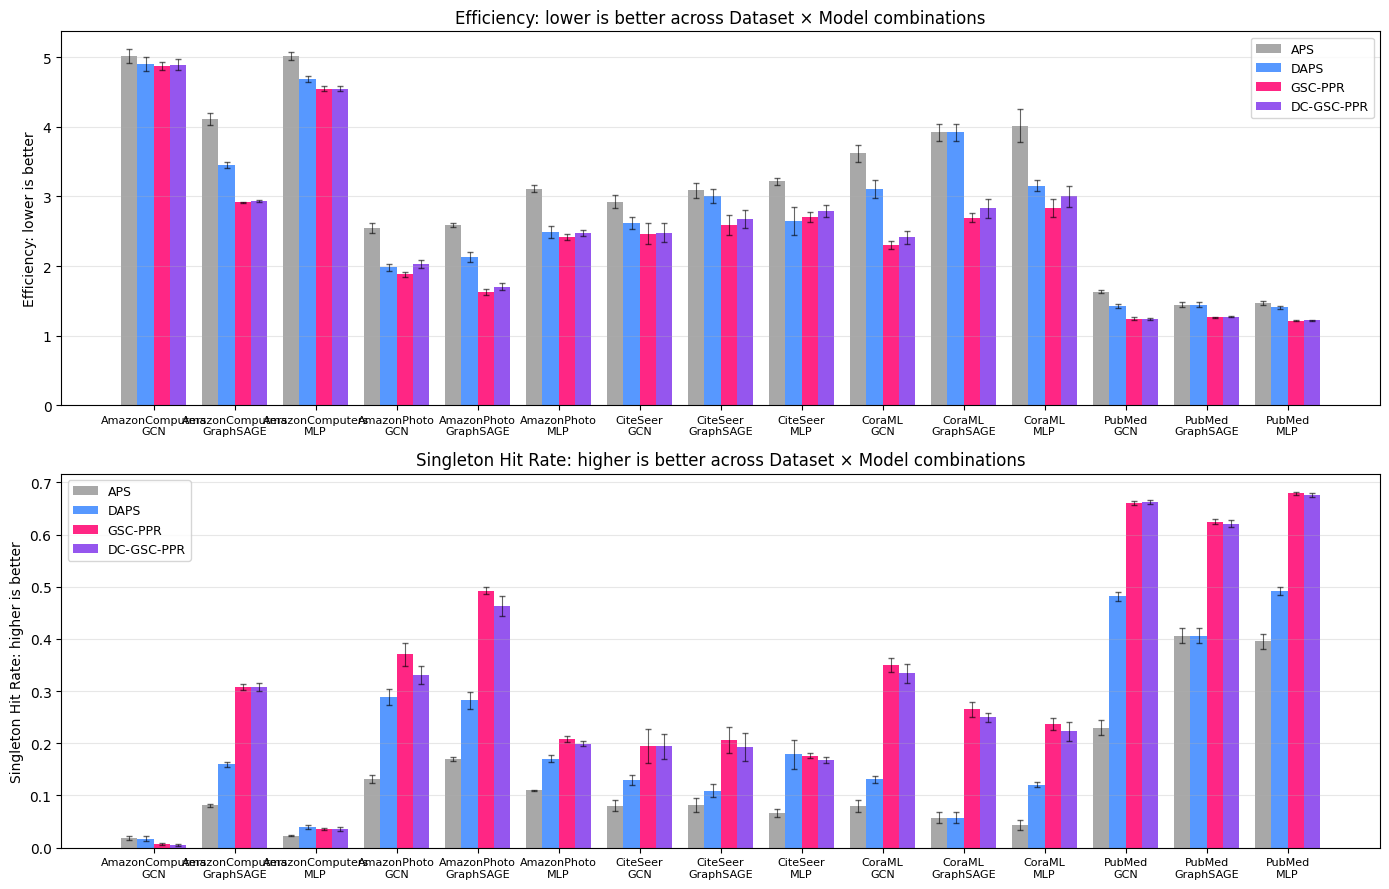

In [175]:
# ============================================================
# Grand sweep bar plots: Efficiency and Singleton Hit Rate
# Including DC-GSC-PPR
# ============================================================

method_colors = {
    "APS": "#999999",
    "DAPS": "#3a86ff",
    "GSC-PPR": "#ff006e",
    "DC-GSC-PPR": "#8338ec",
}

plot_methods = [
    m for m in ["APS", "DAPS", "GSC-PPR", "DC-GSC-PPR"]
    if m in agg["Method"].unique()
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9)
)

for ax_idx, (metric_key, metric_label, lower_is_better) in enumerate([
    ("Eff_mean", "Efficiency: lower is better", True),
    ("SHR_mean", "Singleton Hit Rate: higher is better", False),
]):
    std_key = "Eff_std" if metric_key == "Eff_mean" else "SHR_std"
    ax = axes[ax_idx]

    combos = list(agg.groupby(["Dataset", "Model"]).groups.keys())

    n_combo = len(combos)
    width = 0.20
    xs = np.arange(n_combo)

    for j, method in enumerate(plot_methods):
        ys = []
        errs = []

        for ds, mdl in combos:
            row = agg[
                (agg["Dataset"] == ds) &
                (agg["Model"] == mdl) &
                (agg["Method"] == method)
            ]

            if len(row) > 0:
                ys.append(row[metric_key].iloc[0])
                errs.append(row[std_key].iloc[0])
            else:
                ys.append(0)
                errs.append(0)

        offset = (j - (len(plot_methods) - 1) / 2) * width

        ax.bar(
            xs + offset,
            ys,
            width,
            yerr=errs,
            capsize=2,
            label=method,
            color=method_colors.get(method, None),
            alpha=0.85,
            error_kw={
                "elinewidth": 0.8,
                "alpha": 0.6,
            }
        )

    ax.set_xticks(xs)
    ax.set_xticklabels(
        [f"{ds}\n{mdl}" for ds, mdl in combos],
        rotation=0,
        fontsize=8
    )

    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} across Dataset × Model combinations")
    ax.legend(loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    if lower_is_better:
        ax.set_ylim(bottom=0)

plt.tight_layout()

plt.savefig(
    "grand_sweep_bars_with_dc.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

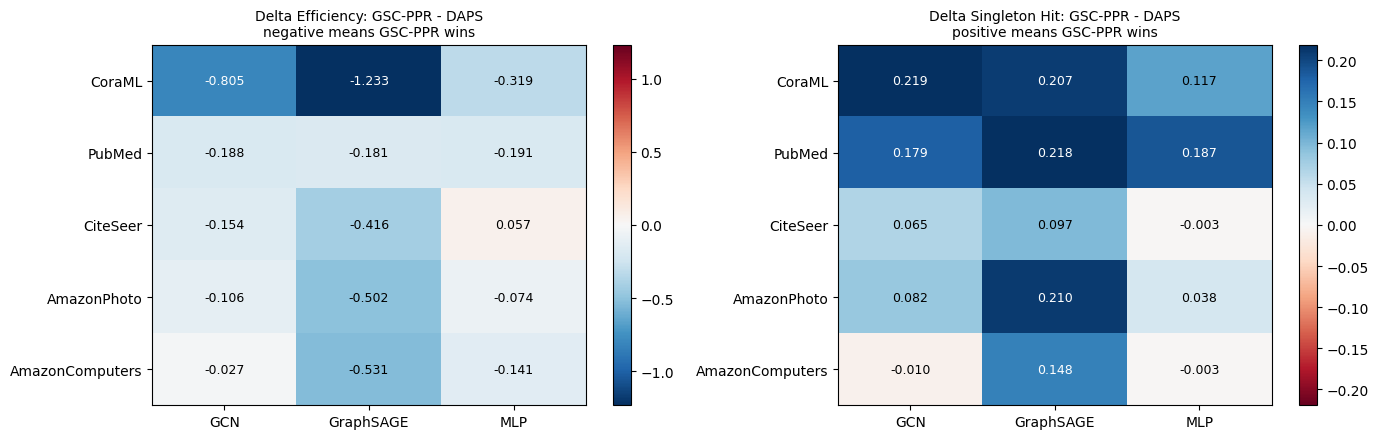

In [164]:
# ============================================================
# Heatmap: GSC-PPR vs DAPS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.5)
)

heatmap_specs = [
    (
        "Eff_Delta",
        "Delta Efficiency: GSC-PPR - DAPS\nnegative means GSC-PPR wins",
        "RdBu_r",
        ".3f"
    ),
    (
        "SHR_Delta",
        "Delta Singleton Hit: GSC-PPR - DAPS\npositive means GSC-PPR wins",
        "RdBu",
        ".3f"
    ),
]

for ax_idx, (col, title, cmap, fmt) in enumerate(heatmap_specs):
    pivot = winner_df.pivot(
        index="Dataset",
        columns="Model",
        values=col
    )

    pivot = pivot.reindex(
        index=GRAND_DATASETS,
        columns=GRAND_MODELS
    )

    vmax = np.nanmax(np.abs(pivot.values))

    im = axes[ax_idx].imshow(
        pivot.values,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        aspect="auto"
    )

    axes[ax_idx].set_xticks(range(len(GRAND_MODELS)))
    axes[ax_idx].set_xticklabels(GRAND_MODELS)

    axes[ax_idx].set_yticks(range(len(GRAND_DATASETS)))
    axes[ax_idx].set_yticklabels(GRAND_DATASETS)

    axes[ax_idx].set_title(title, fontsize=10)

    plt.colorbar(
        im,
        ax=axes[ax_idx]
    )

    for i in range(len(GRAND_DATASETS)):
        for j in range(len(GRAND_MODELS)):
            val = pivot.values[i, j]

            if np.isnan(val):
                text = "nan"
                color = "black"
            else:
                text = format(val, fmt)
                color = "white" if abs(val) > vmax * 0.6 else "black"

            axes[ax_idx].text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=9,
                color=color
            )

plt.tight_layout()

plt.savefig(
    "grand_sweep_heatmap.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()